## 1. Big Data Environment Setup

This section initializes the big data environment required for the project. Apache Spark is used as the core big data processing framework, while PySpark provides the interface for data manipulation and machine learning tasks. A Spark session is created to begin the workflow, and the environment details are displayed to confirm successful setup.

In [1]:
# STEP 1: BIG DATA ENVIRONMENT SETUP
# Project: Football Match Outcome Prediction

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
import os
from functools import reduce

# Create Spark session
spark = SparkSession.builder \
    .appName("Football Match Outcome Prediction using Apache Spark MLlib") \
    .getOrCreate()

# Reduce unnecessary Spark warnings in notebook output
spark.sparkContext.setLogLevel("ERROR")

# Display environment summary
print("=" * 80)
print("BIG DATA ENVIRONMENT SETUP COMPLETED")
print("=" * 80)
print("Project Title : Football Match Outcome Prediction")
print("Big Data Tool : Apache Spark / PySpark")
print("ML Library    : Spark MLlib")
print("Session Name  : Football Match Outcome Prediction using Apache Spark MLlib")
print("Spark Version :", spark.version)
print("=" * 80)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/21 04:44:38 WARN Utils: Your hostname, Shashank, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/05/21 04:44:38 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/21 04:44:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


BIG DATA ENVIRONMENT SETUP COMPLETED
Project Title : Football Match Outcome Prediction
Big Data Tool : Apache Spark / PySpark
ML Library    : Spark MLlib
Session Name  : Football Match Outcome Prediction using Apache Spark MLlib
Spark Version : 4.1.1


## 2. Dataset Path Configuration

This section defines the file paths for the multi-league football dataset used in this project. The dataset is organized league-wise, and a dictionary is created to map each football league to its corresponding folder. This configuration helps ensure that the data loading process is structured, scalable, and easy to manage.

In [2]:
# STEP 2: DATASET PATH CONFIGURATION
# Multi-League Football Dataset Definition

base_path = "../data/raw"

# Dictionary mapping football leagues to dataset folders
league_folders = {
    "Premier League": "epl",
    "La Liga": "laliga",
    "Bundesliga": "bundesliga",
    "Serie A": "seriea",
    "Ligue 1": "ligue1"
}

# Display dataset configuration details
print("=" * 80)
print("STEP 2 COMPLETED: MULTI-LEAGUE DATASET CONFIGURATION")
print("=" * 80)
print(f"Dataset Source Directory : {base_path}")
print(f"Total Number of Leagues  : {len(league_folders)}")
print("=" * 80)

for league, folder in league_folders.items():
    print(f"{league:<20} --> {base_path}/{folder}")

print("=" * 80)

STEP 2 COMPLETED: MULTI-LEAGUE DATASET CONFIGURATION
Dataset Source Directory : ../data/raw
Total Number of Leagues  : 5
Premier League       --> ../data/raw/epl
La Liga              --> ../data/raw/laliga
Bundesliga           --> ../data/raw/bundesliga
Serie A              --> ../data/raw/seriea
Ligue 1              --> ../data/raw/ligue1


## 3. Dataset File Verification

Before loading the data into Spark, the dataset files are verified to ensure that the required CSV files are available in each league folder. This step helps confirm that the dataset structure is correct and avoids errors during the data ingestion process. It also provides an overview of the total number of files collected from all selected football leagues.

In [3]:
# STEP 3: VERIFY DATASET FILES
# Multi-League Football CSV Validation

total_files = 0

print("=" * 80)
print("STEP 3: FOOTBALL DATASET FILE VALIDATION")
print("=" * 80)

# Verify CSV files available in each league directory
for league, folder in league_folders.items():
    folder_path = os.path.join(base_path, folder)

    if not os.path.exists(folder_path):
        print(f"{league:<20} : Folder not found -> {folder_path}")
        continue

    csv_files = [file for file in os.listdir(folder_path) if file.endswith(".csv")]
    file_count = len(csv_files)

    print(f"{league:<20} : {file_count} CSV files detected")
    total_files += file_count

# Display total number of discovered dataset files
print("=" * 80)
print(f"TOTAL CSV FILES DISCOVERED : {total_files}")
print("STEP 3 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 3: FOOTBALL DATASET FILE VALIDATION
Premier League       : 16 CSV files detected
La Liga              : 16 CSV files detected
Bundesliga           : 16 CSV files detected
Serie A              : 16 CSV files detected
Ligue 1              : 16 CSV files detected
TOTAL CSV FILES DISCOVERED : 80
STEP 3 COMPLETED SUCCESSFULLY


## 4. Sample Dataset Loading and Inspection

In this section, a sample football dataset is loaded into an Apache Spark DataFrame to perform an initial inspection of the raw data structure. The schema, sample records, dataset dimensions, and attribute names are examined to understand the available variables before combining and processing the full multi-league dataset. This step helps confirm that the data has been read correctly and provides an early understanding of the dataset format.

In [4]:
# STEP 4: LOAD AND INSPECT SAMPLE FOOTBALL DATASET
# Apache Spark DataFrame Initialisation

sample_path = "../data/raw/epl"

# Select a sample CSV file safely
sample_files = sorted([file for file in os.listdir(sample_path) if file.endswith(".csv")])

if not sample_files:
    raise FileNotFoundError(f"No CSV files found in {sample_path}")

sample_file = os.path.join(sample_path, sample_files[0])

# Load CSV dataset into Spark DataFrame
sample_df = spark.read.csv(
    sample_file,
    header=True,
    inferSchema=True
)

# Display dataset loading information
print("=" * 80)
print("STEP 4: SAMPLE FOOTBALL DATASET LOADING AND INSPECTION")
print("=" * 80)
print(f"Dataset File : {sample_file}")

# Display dataset schema
print("=" * 80)
print("DATASET SCHEMA")
print("=" * 80)
sample_df.printSchema()

# Display sample records
print("=" * 80)
print("SAMPLE RECORDS")
print("=" * 80)
sample_df.show(5, truncate=False)

# Display dataset dimensions
print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
total_rows = sample_df.count()
total_columns = len(sample_df.columns)

print(f"Total Rows    : {total_rows}")
print(f"Total Columns : {total_columns}")

# Display column names
print("=" * 80)
print("DATASET ATTRIBUTES")
print("=" * 80)
for index, column_name in enumerate(sample_df.columns, start=1):
    print(f"{index:03d}. {column_name}")

print("=" * 80)
print("STEP 4 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 4: SAMPLE FOOTBALL DATASET LOADING AND INSPECTION
Dataset File : ../data/raw/epl/epl-2010-11.csv
DATASET SCHEMA
root
 |-- Div: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- HomeTeam: string (nullable = true)
 |-- AwayTeam: string (nullable = true)
 |-- FTHG: integer (nullable = true)
 |-- FTAG: integer (nullable = true)
 |-- FTR: string (nullable = true)
 |-- HTHG: integer (nullable = true)
 |-- HTAG: integer (nullable = true)
 |-- HTR: string (nullable = true)
 |-- Referee: string (nullable = true)
 |-- HS: integer (nullable = true)
 |-- AS: integer (nullable = true)
 |-- HST: integer (nullable = true)
 |-- AST: integer (nullable = true)
 |-- HF: integer (nullable = true)
 |-- AF: integer (nullable = true)
 |-- HC: integer (nullable = true)
 |-- AC: integer (nullable = true)
 |-- HY: integer (nullable = true)
 |-- AY: integer (nullable = true)
 |-- HR: integer (nullable = true)
 |-- AR: integer (nullable = true)
 |-- B365H: double (nullable = true)
 |-- B365D:

## 5. Missing Value Analysis

This section performs a missing value analysis on the sample dataset to assess data quality before preprocessing. Missing or null values can negatively affect analytical accuracy and model performance, so it is important to identify them at an early stage. The analysis provides a column-wise summary of missing values, which supports informed decisions during the data cleaning phase.

In [5]:
# STEP 5: MISSING VALUE ANALYSIS
# Data Quality Inspection using Apache Spark

# Calculate missing/null values for every column
missing_values = sample_df.select([
    count(
        when(col(f"`{c}`").isNull(), c)
    ).alias(
        c.replace(".", "_")
         .replace(">", "_gt_")
         .replace("<", "_lt_")
    )
    for c in sample_df.columns
])

# Display missing value statistics
print("=" * 80)
print("STEP 5: MISSING VALUE ANALYSIS")
print("=" * 80)

missing_values.show(vertical=True, truncate=False)

print("=" * 80)
print("STEP 5 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 5: MISSING VALUE ANALYSIS
-RECORD 0----------
 Div         | 0   
 Date        | 0   
 HomeTeam    | 0   
 AwayTeam    | 0   
 FTHG        | 0   
 FTAG        | 0   
 FTR         | 0   
 HTHG        | 0   
 HTAG        | 0   
 HTR         | 0   
 Referee     | 0   
 HS          | 0   
 AS          | 0   
 HST         | 0   
 AST         | 0   
 HF          | 0   
 AF          | 0   
 HC          | 0   
 AC          | 0   
 HY          | 0   
 AY          | 0   
 HR          | 0   
 AR          | 0   
 B365H       | 0   
 B365D       | 0   
 B365A       | 0   
 BWH         | 0   
 BWD         | 0   
 BWA         | 0   
 GBH         | 0   
 GBD         | 0   
 GBA         | 0   
 IWH         | 0   
 IWD         | 0   
 IWA         | 0   
 LBH         | 0   
 LBD         | 0   
 LBA         | 0   
 SBH         | 0   
 SBD         | 0   
 SBA         | 0   
 WHH         | 0   
 WHD         | 0   
 WHA         | 0   
 SJH         | 0   
 SJD         | 0   
 SJA         | 0   
 VCH     

## 6. Multi-League Data Ingestion

### 6.1 Loading All Football Datasets

This section loads all football datasets from the selected league folders into Apache Spark DataFrames. Since the data is collected from multiple leagues and seasons, only the most relevant attributes are selected to maintain consistency across files. Additional metadata columns, namely league name and season, are appended to each dataset so that the merged data can later support league-wise and season-wise analysis. This step forms the foundation for building a unified dataset for further preprocessing and modelling.

In [6]:
# STEP 6: LOAD ALL FOOTBALL DATASETS SAFELY
# Multi-League Data Ingestion using Apache Spark

important_columns = [
    "Div", "Date",
    "HomeTeam", "AwayTeam",
    "FTHG", "FTAG", "FTR",
    "HTHG", "HTAG", "HTR",
    "HS", "AS",
    "HST", "AST",
    "HF", "AF",
    "HC", "AC",
    "HY", "AY",
    "HR", "AR"
]

all_dfs = []

print("=" * 80)
print("STEP 6: MULTI-LEAGUE FOOTBALL DATA INGESTION")
print("=" * 80)

for league_name, folder_name in league_folders.items():
    folder_path = os.path.join(base_path, folder_name)

    if not os.path.exists(folder_path):
        print(f"{league_name:<20} : Folder not found -> {folder_path}")
        continue

    csv_files = sorted([
        file for file in os.listdir(folder_path)
        if file.endswith(".csv")
    ])

    print(f"{league_name:<20} : {len(csv_files)} CSV files found")

    for file_name in csv_files:
        file_path = os.path.join(folder_path, file_name)
        season = file_name.replace(".csv", "")

        df = spark.read.csv(
            file_path,
            header=True,
            inferSchema=True
        )

        available_columns = [
            column_name for column_name in important_columns
            if column_name in df.columns
        ]

        df = df.select(available_columns)
        df = df.withColumn("League", lit(league_name))
        df = df.withColumn("Season", lit(season))

        all_dfs.append(df)

print("=" * 80)
print(f"TOTAL DATAFRAMES LOADED : {len(all_dfs)}")
print("STEP 6 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 6: MULTI-LEAGUE FOOTBALL DATA INGESTION
Premier League       : 16 CSV files found
La Liga              : 16 CSV files found
Bundesliga           : 16 CSV files found
Serie A              : 16 CSV files found
Ligue 1              : 16 CSV files found
TOTAL DATAFRAMES LOADED : 80
STEP 6 COMPLETED SUCCESSFULLY


## 7. Master Dataset Construction

### 7.1 Creating the Unified Football DataFrame

After loading individual league and season files, all Spark DataFrames are combined into a single master DataFrame. This unified dataset provides a consolidated view of football match records across multiple leagues and seasons. The integration is performed using a schema-aware union operation so that slight variations in column availability across files can be handled safely. Creating the master dataset is an important step because it enables consistent data cleaning, exploratory analysis, feature engineering, and predictive modelling on a single integrated data source.

In [7]:
# STEP 7: CREATE MASTER FOOTBALL DATAFRAME
# Multi-League Dataset Integration using Apache Spark

if not all_dfs:
    raise ValueError("No DataFrames were loaded. Please check the dataset ingestion step.")

master_df = reduce(
    lambda df1, df2: df1.unionByName(df2, allowMissingColumns=True),
    all_dfs
)

# Store summary statistics
total_rows = master_df.count()
total_columns = len(master_df.columns)

# Display master dataset summary
print("=" * 80)
print("STEP 7: MASTER FOOTBALL DATAFRAME CREATION")
print("=" * 80)
print(f"Total Source DataFrames : {len(all_dfs)}")
print(f"Total Rows              : {total_rows}")
print(f"Total Columns           : {total_columns}")

print("=" * 80)
print("MASTER DATAFRAME SAMPLE RECORDS")
print("=" * 80)
master_df.show(5, truncate=False)

print("=" * 80)
print("STEP 7 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 7: MASTER FOOTBALL DATAFRAME CREATION
Total Source DataFrames : 80
Total Rows              : 28571
Total Columns           : 24
MASTER DATAFRAME SAMPLE RECORDS
+---+--------+-----------+----------+----+----+---+----+----+---+---+---+---+---+---+---+---+---+---+---+---+---+--------------+-----------+
|Div|Date    |HomeTeam   |AwayTeam  |FTHG|FTAG|FTR|HTHG|HTAG|HTR|HS |AS |HST|AST|HF |AF |HC |AC |HY |AY |HR |AR |League        |Season     |
+---+--------+-----------+----------+----+----+---+----+----+---+---+---+---+---+---+---+---+---+---+---+---+---+--------------+-----------+
|E0 |14/08/10|Aston Villa|West Ham  |3   |0   |H  |2   |0   |H  |23 |12 |11 |2  |15 |15 |16 |7  |1  |2  |0  |0  |Premier League|epl-2010-11|
|E0 |14/08/10|Blackburn  |Everton   |1   |0   |H  |1   |0   |H  |7  |17 |2  |12 |19 |14 |1  |3  |2  |1  |0  |0  |Premier League|epl-2010-11|
|E0 |14/08/10|Bolton     |Fulham    |0   |0   |D  |0   |0   |D  |13 |12 |9  |7  |12 |13 |4  |8  |1  |3  |0  |0  |Premier League|ep

## 8. Exploratory Data Analysis

### 8.1 Master Dataset Overview

This section presents an exploratory overview of the unified football dataset after combining records from multiple leagues and seasons. The structure of the master DataFrame is examined through its dimensions and schema, while basic distribution analysis is performed to understand how matches are distributed across leagues and how full-time match outcomes are represented in the dataset. This step provides an important foundation for identifying patterns in the data before proceeding to data cleaning and feature engineering.

In [8]:
# STEP 8: MASTER DATASET EXPLORATORY ANALYSIS
# Dataset Statistics and Distribution Analysis


print("=" * 80)
print("STEP 8 COMPLETED: MASTER FOOTBALL DATASET OVERVIEW")
print("=" * 80)

# ------------------------------------------------------------
# Display dataset dimensions
# ------------------------------------------------------------

total_rows = master_df.count()
total_columns = len(master_df.columns)

print(f"Total Rows    : {total_rows}")
print(f"Total Columns : {total_columns}")

print("=" * 80)

# ------------------------------------------------------------
# Display column names
# ------------------------------------------------------------

print("DATASET ATTRIBUTES")
print("=" * 80)

for index, column_name in enumerate(master_df.columns, start=1):
    print(f"{index:03d}. {column_name}")

print("=" * 80)

# ------------------------------------------------------------
# Display dataset schema
# ------------------------------------------------------------

print("MASTER DATASET SCHEMA")
print("=" * 80)

master_df.printSchema()

# ------------------------------------------------------------
# Display match distribution by league
# ------------------------------------------------------------

print("=" * 80)
print("MATCH DISTRIBUTION BY LEAGUE")
print("=" * 80)

master_df.groupBy("League") \
    .count() \
    .orderBy(desc("count")) \
    .show(truncate=False)

# ------------------------------------------------------------
# Display match outcome distribution
# ------------------------------------------------------------

print("=" * 80)
print("MATCH RESULT DISTRIBUTION")
print("=" * 80)

master_df.groupBy("FTR") \
    .count() \
    .orderBy(desc("count")) \
    .show(truncate=False)

print("=" * 80)

STEP 8 COMPLETED: MASTER FOOTBALL DATASET OVERVIEW
Total Rows    : 28571
Total Columns : 24
DATASET ATTRIBUTES
001. Div
002. Date
003. HomeTeam
004. AwayTeam
005. FTHG
006. FTAG
007. FTR
008. HTHG
009. HTAG
010. HTR
011. HS
012. AS
013. HST
014. AST
015. HF
016. AF
017. HC
018. AC
019. HY
020. AY
021. HR
022. AR
023. League
024. Season
MASTER DATASET SCHEMA
root
 |-- Div: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- HomeTeam: string (nullable = true)
 |-- AwayTeam: string (nullable = true)
 |-- FTHG: integer (nullable = true)
 |-- FTAG: integer (nullable = true)
 |-- FTR: string (nullable = true)
 |-- HTHG: integer (nullable = true)
 |-- HTAG: integer (nullable = true)
 |-- HTR: string (nullable = true)
 |-- HS: integer (nullable = true)
 |-- AS: integer (nullable = true)
 |-- HST: integer (nullable = true)
 |-- AST: integer (nullable = true)
 |-- HF: integer (nullable = true)
 |-- AF: integer (nullable = true)
 |-- HC: integer (nullable = true)
 |-- AC: integer (n

+--------------+-----+
|League        |count|
+--------------+-----+
|Serie A       |6015 |
|Premier League|6010 |
|La Liga       |6000 |
|Ligue 1       |5704 |
|Bundesliga    |4842 |
+--------------+-----+

MATCH RESULT DISTRIBUTION


+----+-----+
|FTR |count|
+----+-----+
|H   |12776|
|A   |8574 |
|D   |7213 |
|NULL|8    |
+----+-----+



## 9. Data Cleaning

### 9.1 Duplicate Record Detection and Removal

This section performs duplicate record analysis on the master football dataset to improve data quality and ensure analytical reliability. Duplicate rows can distort statistical summaries and negatively influence predictive modelling results. Therefore, the total number of rows, distinct records, and duplicate entries are examined, after which duplicate records are removed to create a cleaner and more reliable dataset for the next stages of the workflow.

In [9]:
# STEP 9: DATA QUALITY VALIDATION AND DUPLICATE REMOVAL

print("=" * 80)
print("STEP 9: DATA QUALITY VALIDATION AND DUPLICATE REMOVAL")
print("=" * 80)

# Count original and distinct rows
original_rows = master_df.count()
distinct_rows = master_df.distinct().count()

# Calculate duplicate rows
duplicate_rows = original_rows - distinct_rows

print(f"Original Rows            : {original_rows}")
print(f"Distinct Rows            : {distinct_rows}")
print(f"Duplicate Rows Detected  : {duplicate_rows}")

print("=" * 80)

# Remove duplicate rows
clean_df = master_df.dropDuplicates()
cleaned_rows = clean_df.count()

# Validate whether duplicates still remain
remaining_duplicates = cleaned_rows - clean_df.distinct().count()

print("DUPLICATE REMOVAL COMPLETED")
print(f"Rows After Duplicate Removal : {cleaned_rows}")
print(f"Remaining Duplicates         : {remaining_duplicates}")

print("=" * 80)
print("STEP 9 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 9: DATA QUALITY VALIDATION AND DUPLICATE REMOVAL


Original Rows            : 28571
Distinct Rows            : 28569
Duplicate Rows Detected  : 2


DUPLICATE REMOVAL COMPLETED
Rows After Duplicate Removal : 28569
Remaining Duplicates         : 0
STEP 9 COMPLETED SUCCESSFULLY


## 10. Missing Value Validation on Cleaned Dataset

### 10.1 Final Missing Value Analysis

After duplicate removal, a final missing value analysis is performed on the cleaned football dataset. This step is important to identify any remaining null or empty values before proceeding to feature engineering and predictive modelling. Conducting this validation on the cleaned dataset helps ensure that the final data used for analysis is consistent, reliable, and suitable for machine learning tasks.

In [10]:
# STEP 10: FINAL MISSING VALUE ANALYSIS
# Data Quality Inspection on Clean Dataset

print("=" * 80)
print("STEP 10: FINAL MISSING VALUE ANALYSIS")
print("=" * 80)

# Calculate missing/null values for every column
missing_values = clean_df.select([
    count(
        when(
            col(f"`{c}`").isNull() | (trim(col(f"`{c}`").cast("string")) == ""),
            c
        )
    ).alias(
        c.replace(".", "_")
         .replace(">", "_gt_")
         .replace("<", "_lt_")
    )
    for c in clean_df.columns
])

# Display missing value statistics
missing_values.show(vertical=True, truncate=False)

print("=" * 80)
print("STEP 10 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 10: FINAL MISSING VALUE ANALYSIS


-RECORD 0-------
 Div      | 6   
 Date     | 6   
 HomeTeam | 6   
 AwayTeam | 6   
 FTHG     | 6   
 FTAG     | 6   
 FTR      | 6   
 HTHG     | 10  
 HTAG     | 10  
 HTR      | 10  
 HS       | 9   
 AS       | 9   
 HST      | 9   
 AST      | 9   
 HF       | 11  
 AF       | 11  
 HC       | 9   
 AC       | 9   
 HY       | 10  
 AY       | 9   
 HR       | 9   
 AR       | 9   
 League   | 0   
 Season   | 0   

STEP 10 COMPLETED SUCCESSFULLY


## 11. Final Data Cleaning

### 11.1 Removal of Incomplete Records

This section performs the final data cleaning step on the cleaned football dataset by removing records that still contain missing or null values. Since incomplete records can reduce analytical accuracy and negatively affect machine learning performance, a fully consistent dataset is required before feature engineering and model development. The number of rows before and after cleaning is compared to measure the impact of this step, and a final validation is carried out to confirm that no missing values remain in the resulting dataset.

In [11]:
# STEP 11: FINAL DATA CLEANING

print("=" * 80)
print("STEP 11: FINAL DATA CLEANING")
print("=" * 80)

# Count rows before cleaning
rows_before = clean_df.count()

# Remove rows containing missing/null values
final_df = clean_df.dropna()

# Count rows after cleaning
rows_after = final_df.count()
removed_rows = rows_before - rows_after

# Display cleaning summary
print(f"Rows Before Cleaning : {rows_before}")
print(f"Rows After Cleaning  : {rows_after}")
print(f"Rows Removed         : {removed_rows}")

print("=" * 80)
print("VERIFYING FINAL DATASET")
print("=" * 80)

# Verify no missing values remain
remaining_nulls = final_df.select([
    count(
        when(
            col(f"`{c}`").isNull() | (trim(col(f"`{c}`").cast("string")) == ""),
            c
        )
    ).alias(
        c.replace(".", "_")
         .replace(">", "_gt_")
         .replace("<", "_lt_")
    )
    for c in final_df.columns
])

remaining_nulls.show(vertical=True, truncate=False)

print("=" * 80)
print("STEP 11 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 11: FINAL DATA CLEANING


Rows Before Cleaning : 28569
Rows After Cleaning  : 28556
Rows Removed         : 13
VERIFYING FINAL DATASET


-RECORD 0-------
 Div      | 0   
 Date     | 0   
 HomeTeam | 0   
 AwayTeam | 0   
 FTHG     | 0   
 FTAG     | 0   
 FTR      | 0   
 HTHG     | 0   
 HTAG     | 0   
 HTR      | 0   
 HS       | 0   
 AS       | 0   
 HST      | 0   
 AST      | 0   
 HF       | 0   
 AF       | 0   
 HC       | 0   
 AC       | 0   
 HY       | 0   
 AY       | 0   
 HR       | 0   
 AR       | 0   
 League   | 0   
 Season   | 0   

STEP 11 COMPLETED SUCCESSFULLY


## 12. Processed Data Export

### 12.1 Saving the Final Cleaned Dataset

This section saves the final cleaned football dataset in Apache Parquet format for efficient storage and future reuse. Parquet is a columnar storage format that is well suited for big data processing because it offers better performance and storage efficiency than plain text formats such as CSV. Exporting the cleaned dataset at this stage ensures that a reusable and analysis-ready version of the data is preserved for later modelling, visualization, and reporting.

In [12]:
# STEP 12: SAVE FINAL CLEANED DATASET
# Export Processed Dataset in Apache Parquet Format

# Define output path for processed dataset
output_path = "../data/processed/master_cleaned.parquet"

# Save final cleaned dataset
final_df.write \
    .mode("overwrite") \
    .parquet(output_path)

# Display export confirmation
print("=" * 80)
print("STEP 12: FINAL CLEANED DATASET EXPORT")
print("=" * 80)
print("FINAL CLEANED DATASET SAVED SUCCESSFULLY")
print(f"Storage Format : Parquet")
print(f"Saved Location : {output_path}")
print("=" * 80)

STEP 12: FINAL CLEANED DATASET EXPORT
FINAL CLEANED DATASET SAVED SUCCESSFULLY
Storage Format : Parquet
Saved Location : ../data/processed/master_cleaned.parquet


## 13. Processed Dataset Reload Verification

### 13.1 Loading the Final Parquet Dataset

This section reloads the final cleaned football dataset from the saved Parquet file to verify that the export process was successful. Reloading the processed dataset ensures that the cleaned data can be reused efficiently in later stages of the workflow without repeating the full preprocessing pipeline. A brief inspection of the dataset dimensions and sample records is performed to confirm that the saved data has been loaded correctly.

In [13]:
# STEP 13: LOAD FINAL PROCESSED FOOTBALL DATASET
# Apache Parquet Dataset Loading

processed_path = "../data/processed/master_cleaned.parquet"

# Load processed Parquet dataset into Spark DataFrame
football_df = spark.read.parquet(processed_path)

# Display dataset loading confirmation
print("=" * 80)
print("STEP 13: LOAD FINAL PROCESSED FOOTBALL DATASET")
print("=" * 80)
print("FINAL PROCESSED DATASET LOADED SUCCESSFULLY")

# Display dataset dimensions
total_rows = football_df.count()
total_columns = len(football_df.columns)

print(f"Total Rows    : {total_rows}")
print(f"Total Columns : {total_columns}")

print("=" * 80)
print("SAMPLE RECORDS")
print("=" * 80)
football_df.show(5, truncate=False)

print("=" * 80)
print("STEP 13 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 13: LOAD FINAL PROCESSED FOOTBALL DATASET
FINAL PROCESSED DATASET LOADED SUCCESSFULLY
Total Rows    : 28556
Total Columns : 24
SAMPLE RECORDS
+---+--------+---------+---------+----+----+---+----+----+---+---+---+---+---+---+---+---+---+---+---+---+---+--------------+-----------+
|Div|Date    |HomeTeam |AwayTeam |FTHG|FTAG|FTR|HTHG|HTAG|HTR|HS |AS |HST|AST|HF |AF |HC |AC |HY |AY |HR |AR |League        |Season     |
+---+--------+---------+---------+----+----+---+----+----+---+---+---+---+---+---+---+---+---+---+---+---+---+--------------+-----------+
|E0 |13/11/10|Wolves   |Bolton   |2   |3   |A  |0   |1   |A  |10 |13 |6  |7  |10 |10 |12 |3  |1  |0  |0  |0  |Premier League|epl-2010-11|
|E0 |03/10/10|Liverpool|Blackpool|1   |2   |A  |0   |2   |A  |19 |11 |10 |7  |11 |10 |5  |2  |2  |1  |0  |0  |Premier League|epl-2010-11|
|E0 |02/10/10|West Brom|Bolton   |1   |1   |D  |0   |0   |D  |17 |10 |9  |5  |8  |10 |7  |4  |3  |2  |0  |0  |Premier League|epl-2010-11|
|E0 |06/11/10|Blackpool|E

## 14. Exploratory Data Analysis

### 14.1 Match Result Distribution Analysis

This section analyses the distribution of full-time match outcomes in the cleaned football dataset. The target variable `FTR` represents the final result of a match, where `H` indicates a home win, `D` indicates a draw, and `A` indicates an away win. Examining both the raw counts and percentage distribution of match results helps to understand the balance of the target classes, which is important for interpreting the dataset and preparing for predictive modelling.

In [14]:
# STEP 14: MATCH RESULT DISTRIBUTION ANALYSIS
# Exploratory Analysis of Football Match Outcomes

print("=" * 80)
print("STEP 14: MATCH RESULT DISTRIBUTION ANALYSIS")
print("=" * 80)

# Calculate match outcome distribution
# H = Home Win, D = Draw, A = Away Win
result_distribution = (
    football_df
    .groupBy("FTR")
    .count()
    .orderBy(desc("count"))
)

# Display raw distribution counts
print("MATCH RESULT COUNTS")
print("=" * 80)
result_distribution.show(truncate=False)

# Calculate percentage distribution
total_matches = football_df.count()

result_percentage = result_distribution.withColumn(
    "Percentage",
    round((col("count") / total_matches) * 100, 2)
)

# Display percentage distribution
print("=" * 80)
print("MATCH RESULT PERCENTAGES")
print("=" * 80)
result_percentage.show(truncate=False)

print("=" * 80)
print("STEP 14 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 14: MATCH RESULT DISTRIBUTION ANALYSIS
MATCH RESULT COUNTS
+---+-----+
|FTR|count|
+---+-----+
|H  |12775|
|A  |8569 |
|D  |7212 |
+---+-----+

MATCH RESULT PERCENTAGES
+---+-----+----------+
|FTR|count|Percentage|
+---+-----+----------+
|H  |12775|44.74     |
|A  |8569 |30.01     |
|D  |7212 |25.26     |
+---+-----+----------+

STEP 14 COMPLETED SUCCESSFULLY


## 15. Exploratory Data Analysis

### 15.1 League Distribution Analysis

This section analyses the distribution of matches across the selected football leagues in the cleaned dataset. Since the project combines data from multiple leagues and seasons, it is important to understand how much each league contributes to the final dataset. Both raw match counts and percentage contributions are calculated to evaluate the overall balance of league representation, which is useful for interpreting the dataset and understanding the scope of the analysis.

In [15]:
# STEP 15: LEAGUE DISTRIBUTION ANALYSIS
# Multi-League Dataset Composition Analysis

print("=" * 80)
print("STEP 15: LEAGUE DISTRIBUTION ANALYSIS")
print("=" * 80)

# Calculate number of matches per football league
league_distribution = (
    football_df
    .groupBy("League")
    .count()
    .orderBy(desc("count"))
)

# Display match counts per league
print("MATCHES PER LEAGUE")
print("=" * 80)
league_distribution.show(truncate=False)

# Calculate league percentage distribution
total_matches = football_df.count()

league_percentage = league_distribution.withColumn(
    "Percentage",
    round((col("count") / total_matches) * 100, 2)
)

# Display percentage contribution of each league
print("=" * 80)
print("LEAGUE PERCENTAGE DISTRIBUTION")
print("=" * 80)
league_percentage.show(truncate=False)

print("=" * 80)
print("STEP 15 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 15: LEAGUE DISTRIBUTION ANALYSIS
MATCHES PER LEAGUE
+--------------+-----+
|League        |count|
+--------------+-----+
|Premier League|6009 |
|Serie A       |6007 |
|La Liga       |6000 |
|Ligue 1       |5699 |
|Bundesliga    |4841 |
+--------------+-----+

LEAGUE PERCENTAGE DISTRIBUTION
+--------------+-----+----------+
|League        |count|Percentage|
+--------------+-----+----------+
|Premier League|6009 |21.04     |
|Serie A       |6007 |21.04     |
|La Liga       |6000 |21.01     |
|Ligue 1       |5699 |19.96     |
|Bundesliga    |4841 |16.95     |
+--------------+-----+----------+

STEP 15 COMPLETED SUCCESSFULLY


## 16. Exploratory Data Analysis

### 16.1 Goal Scoring Analysis

This section examines overall goal-scoring patterns in the cleaned football dataset. The total number of home goals, away goals, and overall goals scored across all matches are calculated, along with the average number of goals per match. These statistics provide a useful summary of attacking outcomes in the dataset and help reveal general scoring trends before the modelling stage.

In [16]:
# STEP 16: GOAL SCORING ANALYSIS
# Football Match Goal Statistics

print("=" * 80)
print("STEP 16: GOAL SCORING ANALYSIS")
print("=" * 80)

# Calculate total number of matches
total_matches = football_df.count()

# Calculate total home goals and away goals
goal_summary = football_df.agg(
    sum("FTHG").alias("Total_Home_Goals"),
    sum("FTAG").alias("Total_Away_Goals")
).collect()[0]

# Extract aggregated goal statistics
total_home_goals = goal_summary["Total_Home_Goals"]
total_away_goals = goal_summary["Total_Away_Goals"]

# Calculate overall goal statistics
total_goals = total_home_goals + total_away_goals
average_goals_per_match = total_goals / total_matches

# Display goal scoring statistics
print(f"Total Matches            : {total_matches}")
print(f"Total Home Goals         : {total_home_goals}")
print(f"Total Away Goals         : {total_away_goals}")
print(f"Total Goals Scored       : {total_goals}")
print(f"Average Goals Per Match  : {average_goals_per_match:.2f}")

print("=" * 80)
print("STEP 16 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 16: GOAL SCORING ANALYSIS
Total Matches            : 28556
Total Home Goals         : 44097
Total Away Goals         : 34548
Total Goals Scored       : 78645
Average Goals Per Match  : 2.75
STEP 16 COMPLETED SUCCESSFULLY


## 17. Exploratory Data Analysis

### 17.1 League-Wise Goal Analysis

This section compares goal-scoring statistics across the selected football leagues in the cleaned dataset. For each league, the total number of matches, home goals, away goals, total goals, and average goals per match are calculated. This comparative analysis helps identify differences in scoring patterns between leagues and provides further contextual insight into the characteristics of the dataset.

In [17]:
# STEP 17: LEAGUE-WISE GOAL ANALYSIS
# Comparative Football Scoring Analysis

print("=" * 80)
print("STEP 17: LEAGUE-WISE GOAL ANALYSIS")
print("=" * 80)

# Calculate league-wise match and goal statistics
league_goals = football_df.groupBy("League").agg(
    count("*").alias("Matches"),
    sum("FTHG").alias("HomeGoals"),
    sum("FTAG").alias("AwayGoals")
)

# Calculate total goals scored per league
league_goals = league_goals.withColumn(
    "TotalGoals",
    col("HomeGoals") + col("AwayGoals")
)

# Calculate average goals scored per match
league_goals = league_goals.withColumn(
    "AvgGoalsPerMatch",
    round(col("TotalGoals") / col("Matches"), 2)
)

# Display league-wise goal statistics
print("LEAGUE-WISE GOAL STATISTICS")
print("=" * 80)

league_goals.orderBy(desc("AvgGoalsPerMatch")).show(truncate=False)

print("=" * 80)
print("STEP 17 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 17: LEAGUE-WISE GOAL ANALYSIS
LEAGUE-WISE GOAL STATISTICS
+--------------+-------+---------+---------+----------+----------------+
|League        |Matches|HomeGoals|AwayGoals|TotalGoals|AvgGoalsPerMatch|
+--------------+-------+---------+---------+----------+----------------+
|Bundesliga    |4841   |8167     |6466     |14633     |3.02            |
|Premier League|6009   |9331     |7487     |16818     |2.8             |
|Serie A       |6007   |8938     |7279     |16217     |2.7             |
|La Liga       |6000   |9238     |6774     |16012     |2.67            |
|Ligue 1       |5699   |8423     |6542     |14965     |2.63            |
+--------------+-------+---------+---------+----------+----------------+

STEP 17 COMPLETED SUCCESSFULLY


## 18. Exploratory Data Analysis

### 18.1 League-Wise Match Result Analysis

This section examines the distribution of full-time match outcomes across each football league in the cleaned dataset. By grouping the target variable `FTR` by league, it becomes possible to compare how often home wins, draws, and away wins occur within different competitions. This analysis provides deeper insight into league-level match behaviour and helps identify whether result patterns vary across leagues.

In [18]:
# STEP 18: LEAGUE-WISE MATCH RESULT ANALYSIS
# Comparative Match Outcome Analysis Across Leagues

print("=" * 80)
print("STEP 18: LEAGUE-WISE MATCH RESULT ANALYSIS")
print("=" * 80)

# Calculate match outcome counts by league
# H = Home Win, D = Draw, A = Away Win
league_results = football_df.groupBy("League", "FTR").count()

# Display league-wise match result distribution
print("LEAGUE-WISE MATCH RESULT DISTRIBUTION")
print("=" * 80)

league_results.orderBy("League", "FTR").show(truncate=False)

print("=" * 80)
print("STEP 18 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 18: LEAGUE-WISE MATCH RESULT ANALYSIS
LEAGUE-WISE MATCH RESULT DISTRIBUTION
+--------------+---+-----+
|League        |FTR|count|
+--------------+---+-----+
|Bundesliga    |A  |1491 |
|Bundesliga    |D  |1185 |
|Bundesliga    |H  |2165 |
|La Liga       |A  |1700 |
|La Liga       |D  |1504 |
|La Liga       |H  |2796 |
|Ligue 1       |A  |1668 |
|Ligue 1       |D  |1510 |
|Ligue 1       |H  |2521 |
|Premier League|A  |1869 |
|Premier League|D  |1453 |
|Premier League|H  |2687 |
|Serie A       |A  |1841 |
|Serie A       |D  |1560 |
|Serie A       |H  |2606 |
+--------------+---+-----+

STEP 18 COMPLETED SUCCESSFULLY


## 19. Additional Analytical Exploration

### 19.1 Football Dataset Analytics Using Spark SQL

In addition to the PySpark DataFrame API, this section applies Spark SQL to analyse the processed football dataset using structured query operations. A temporary SQL view is created from the cleaned DataFrame, allowing SQL-based queries to be performed for league-wise match counts, match result distribution, and average goals per match. This step demonstrates the flexibility of Apache Spark by showing that the dataset can be explored using both programmatic and SQL-oriented analytical techniques.


In [19]:
# STEP 19: SPARK SQL ANALYSIS
# Football Dataset Analytics using Spark SQL

print("=" * 80)
print("STEP 19: SPARK SQL ANALYSIS")
print("=" * 80)

# Create temporary SQL view from Spark DataFrame
football_df.createOrReplaceTempView("football_matches")

# SQL Query 1: League-wise match counts
league_sql = spark.sql("""
SELECT
    League,
    COUNT(*) AS TotalMatches
FROM football_matches
GROUP BY League
ORDER BY TotalMatches DESC
""")

print("LEAGUE-WISE MATCH COUNTS USING SPARK SQL")
print("=" * 80)
league_sql.show(truncate=False)

# SQL Query 2: Match result distribution
result_sql = spark.sql("""
SELECT
    FTR AS MatchResult,
    COUNT(*) AS TotalMatches
FROM football_matches
GROUP BY FTR
ORDER BY TotalMatches DESC
""")

print("=" * 80)
print("MATCH RESULT DISTRIBUTION USING SPARK SQL")
print("=" * 80)
result_sql.show(truncate=False)

# SQL Query 3: Average goals scored by league
goal_sql = spark.sql("""
SELECT
    League,
    ROUND(AVG(FTHG + FTAG), 2) AS AvgGoalsPerMatch
FROM football_matches
GROUP BY League
ORDER BY AvgGoalsPerMatch DESC
""")

print("=" * 80)
print("AVERAGE GOALS PER MATCH USING SPARK SQL")
print("=" * 80)
goal_sql.show(truncate=False)

print("=" * 80)
print("STEP 19 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 19: SPARK SQL ANALYSIS
LEAGUE-WISE MATCH COUNTS USING SPARK SQL
+--------------+------------+
|League        |TotalMatches|
+--------------+------------+
|Premier League|6009        |
|Serie A       |6007        |
|La Liga       |6000        |
|Ligue 1       |5699        |
|Bundesliga    |4841        |
+--------------+------------+

MATCH RESULT DISTRIBUTION USING SPARK SQL
+-----------+------------+
|MatchResult|TotalMatches|
+-----------+------------+
|H          |12775       |
|A          |8569        |
|D          |7212        |
+-----------+------------+

AVERAGE GOALS PER MATCH USING SPARK SQL
+--------------+----------------+
|League        |AvgGoalsPerMatch|
+--------------+----------------+
|Bundesliga    |3.02            |
|Premier League|2.8             |
|Serie A       |2.7             |
|La Liga       |2.67            |
|Ligue 1       |2.63            |
+--------------+----------------+

STEP 19 COMPLETED SUCCESSFULLY


### 19.2 Observation

The Spark SQL analysis produces results consistent with the earlier DataFrame-based exploration, confirming the reliability of the cleaned dataset. It also demonstrates that Apache Spark supports multiple analytical approaches, allowing the same football data to be explored efficiently using SQL queries.

### 19.3 Top Scoring Teams Analysis

This section analyses the offensive performance of football teams by calculating the total number of goals scored in both home and away matches. Home and away goal totals are combined to generate an overall goal count for each team, making it possible to identify the highest-scoring teams in the dataset. This provides additional insight into team-level attacking strength across the selected leagues.

In [20]:
# STEP 19: TOP SCORING TEAMS ANALYSIS
# Team Offensive Performance Analysis

print("=" * 80)
print("STEP 20: TOP SCORING TEAMS ANALYSIS")
print("=" * 80)

# Calculate total home goals scored by each team
home_goals = football_df.groupBy("HomeTeam").agg(
    sum("FTHG").alias("HomeGoals")
)

# Calculate total away goals scored by each team
away_goals = football_df.groupBy("AwayTeam").agg(
    sum("FTAG").alias("AwayGoals")
)

# Rename AwayTeam column for merging
away_goals = away_goals.withColumnRenamed("AwayTeam", "HomeTeam")

# Combine home and away scoring statistics
team_goals = home_goals.join(
    away_goals,
    on="HomeTeam",
    how="outer"
).fillna(0)

# Calculate total goals scored by each team
team_goals = team_goals.withColumn(
    "TotalGoals",
    col("HomeGoals") + col("AwayGoals")
)

# Rename team column for readability
team_goals = team_goals.withColumnRenamed("HomeTeam", "Team")

# Display top scoring football teams
print("TOP SCORING FOOTBALL TEAMS")
print("=" * 80)

team_goals.orderBy(desc("TotalGoals")).show(20, truncate=False)

print("=" * 80)
print("STEP 19 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 20: TOP SCORING TEAMS ANALYSIS
TOP SCORING FOOTBALL TEAMS
+-------------+---------+---------+----------+
|Team         |HomeGoals|AwayGoals|TotalGoals|
+-------------+---------+---------+----------+
|Barcelona    |857      |664      |1521      |
|Bayern Munich|838      |622      |1460      |
|Real Madrid  |820      |622      |1442      |
|Man City     |787      |575      |1362      |
|Paris SG     |749      |590      |1339      |
|Liverpool    |649      |539      |1188      |
|Dortmund     |675      |505      |1180      |
|Napoli       |622      |507      |1129      |
|Arsenal      |628      |499      |1127      |
|Inter        |617      |495      |1112      |
|Juventus     |610      |477      |1087      |
|Chelsea      |576      |481      |1057      |
|Tottenham    |552      |490      |1042      |
|Roma         |582      |447      |1029      |
|Man United   |570      |456      |1026      |
|Lyon         |564      |458      |1022      |
|Ath Madrid   |601      |410      |1011     

## 20. Feature Engineering

### 20.1 Basic Feature Engineering

This section performs basic feature engineering to create additional football match performance variables from the original dataset. Instead of relying only on raw match statistics, several derived features are generated to capture differences in attacking activity, shot accuracy, and discipline between the home and away teams. These engineered variables are expected to provide more informative patterns for the classification models and improve predictive performance.

In [21]:
# RESET DATAFRAME FROM SAVED CLEAN DATA
football_df = spark.read.parquet("../data/processed/master_cleaned.parquet")

print("=" * 80)
print("FRESH football_df RELOADED SUCCESSFULLY")
print("=" * 80)
print(f"Rows    : {football_df.count()}")
print(f"Columns : {len(football_df.columns)}")
print("=" * 80)

FRESH football_df RELOADED SUCCESSFULLY
Rows    : 28556
Columns : 24


In [22]:
# STEP 20: BASIC FEATURE ENGINEERING
# Create Football Match Performance Features

print("=" * 80)
print("STEP 20: BASIC FEATURE ENGINEERING")
print("=" * 80)

# Shot difference: attacking attempt difference
football_df = football_df.withColumn(
    "ShotDifference",
    col("HS") - col("AS")
)

# Shots on target difference: attacking accuracy difference
football_df = football_df.withColumn(
    "TargetShotDifference",
    col("HST") - col("AST")
)

# Card difference: discipline comparison
football_df = football_df.withColumn(
    "CardDifference",
    (col("HY") + col("HR")) - (col("AY") + col("AR"))
)

# Total shots in the match
football_df = football_df.withColumn(
    "TotalShots",
    col("HS") + col("AS")
)

# Total cards in the match
football_df = football_df.withColumn(
    "TotalCards",
    col("HY") + col("AY") + col("HR") + col("AR")
)

# Shot accuracy for home and away teams
football_df = football_df.withColumn(
    "HomeShotAccuracy",
    when(col("HS") > 0, round(col("HST") / col("HS"), 3)).otherwise(0)
)

football_df = football_df.withColumn(
    "AwayShotAccuracy",
    when(col("AS") > 0, round(col("AST") / col("AS"), 3)).otherwise(0)
)

# Shot accuracy difference
football_df = football_df.withColumn(
    "ShotAccuracyDifference",
    round(col("HomeShotAccuracy") - col("AwayShotAccuracy"), 3)
)

print("ENGINEERED FEATURE SAMPLE")
print("=" * 80)

football_df.select(
    "HomeTeam",
    "AwayTeam",
    "ShotDifference",
    "TargetShotDifference",
    "CardDifference",
    "TotalShots",
    "TotalCards",
    "HomeShotAccuracy",
    "AwayShotAccuracy",
    "ShotAccuracyDifference"
).show(5, truncate=False)

print("=" * 80)
print("STEP 20 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 20: BASIC FEATURE ENGINEERING
ENGINEERED FEATURE SAMPLE
+---------+---------+--------------+--------------------+--------------+----------+----------+----------------+----------------+----------------------+
|HomeTeam |AwayTeam |ShotDifference|TargetShotDifference|CardDifference|TotalShots|TotalCards|HomeShotAccuracy|AwayShotAccuracy|ShotAccuracyDifference|
+---------+---------+--------------+--------------------+--------------+----------+----------+----------------+----------------+----------------------+
|Wolves   |Bolton   |-3            |-1                  |1             |23        |1         |0.6             |0.538           |0.062                 |
|Liverpool|Blackpool|8             |3                   |1             |30        |3         |0.526           |0.636           |-0.11                 |
|West Brom|Bolton   |7             |4                   |1             |27        |5         |0.529           |0.5             |0.029                 |
|Blackpool|Everton  |-9    

In [23]:
# STEP 21: ADVANCED MATCH PERFORMANCE FEATURES
# Create Additional Lightweight Predictive Features

print("=" * 80)
print("STEP 21: ADVANCED MATCH PERFORMANCE FEATURES")
print("=" * 80)

# Foul difference
football_df = football_df.withColumn(
    "FoulDifference",
    col("HF") - col("AF")
)

# Corner difference
football_df = football_df.withColumn(
    "CornerDifference",
    col("HC") - col("AC")
)

# Total fouls in the match
football_df = football_df.withColumn(
    "TotalFouls",
    col("HF") + col("AF")
)

# Total corners in the match
football_df = football_df.withColumn(
    "TotalCorners",
    col("HC") + col("AC")
)

# Pressure difference
football_df = football_df.withColumn(
    "PressureDifference",
    (col("HS") + col("HST") + col("HC")) - (col("AS") + col("AST") + col("AC"))
)

print("ADVANCED FEATURE SAMPLE")
print("=" * 80)

football_df.select(
    "HomeTeam",
    "AwayTeam",
    "FoulDifference",
    "CornerDifference",
    "TotalFouls",
    "TotalCorners",
    "PressureDifference"
).limit(5).show(truncate=False)

print("=" * 80)
print("STEP 21 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 21: ADVANCED MATCH PERFORMANCE FEATURES
ADVANCED FEATURE SAMPLE
+---------+---------+--------------+----------------+----------+------------+------------------+
|HomeTeam |AwayTeam |FoulDifference|CornerDifference|TotalFouls|TotalCorners|PressureDifference|
+---------+---------+--------------+----------------+----------+------------+------------------+
|Wolves   |Bolton   |0             |9               |20        |15          |5                 |
|Liverpool|Blackpool|1             |3               |21        |7           |14                |
|West Brom|Bolton   |-2            |3               |18        |11          |14                |
|Blackpool|Everton  |2             |-4              |26        |10          |-19               |
|Arsenal  |Everton  |-2            |-2              |26        |12          |19                |
+---------+---------+--------------+----------------+----------+------------+------------------+

STEP 21 COMPLETED SUCCESSFULLY


In [24]:
# STEP 22: MATCH ORDER PREPARATION
# Create chronological identifiers for historical feature engineering

from pyspark.sql.window import Window
from pyspark.sql.functions import to_date, length

print("=" * 80)
print("STEP 22: MATCH ORDER PREPARATION")
print("=" * 80)

# Remove old ordering columns if rerunning
for c in ["MatchDate", "MatchID"]:
    if c in football_df.columns:
        football_df = football_df.drop(c)

# Safely parse mixed date formats
football_df = football_df.withColumn(
    "MatchDate",
    when(length(col("Date")) == 10, to_date(col("Date"), "dd/MM/yyyy"))
    .otherwise(to_date(col("Date"), "dd/MM/yy"))
)

# Create chronological match identifier
match_window = Window.orderBy("Div", "MatchDate", "HomeTeam", "AwayTeam")

football_df = football_df.withColumn(
    "MatchID",
    row_number().over(match_window)
)

print("MATCH ORDER PREPARATION COMPLETED")
print("=" * 80)

football_df.select(
    "Date",
    "MatchDate",
    "HomeTeam",
    "AwayTeam",
    "MatchID"
).limit(10).show(truncate=False)

print("=" * 80)
print("STEP 22 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 22: MATCH ORDER PREPARATION
MATCH ORDER PREPARATION COMPLETED
+--------+----------+--------------+--------------+-------+
|Date    |MatchDate |HomeTeam      |AwayTeam      |MatchID|
+--------+----------+--------------+--------------+-------+
|20/08/10|2010-08-20|Bayern Munich |Wolfsburg     |1      |
|21/08/10|2010-08-21|FC Koln       |Kaiserslautern|2      |
|21/08/10|2010-08-21|Freiburg      |St Pauli      |3      |
|21/08/10|2010-08-21|Hamburg       |Schalke 04    |4      |
|21/08/10|2010-08-21|Hannover      |Ein Frankfurt |5      |
|21/08/10|2010-08-21|Hoffenheim    |Werder Bremen |6      |
|21/08/10|2010-08-21|M'gladbach    |Nurnberg      |7      |
|22/08/10|2010-08-22|Dortmund      |Leverkusen    |8      |
|22/08/10|2010-08-22|Mainz         |Stuttgart     |9      |
|27/08/10|2010-08-27|Kaiserslautern|Bayern Munich |10     |
+--------+----------+--------------+--------------+-------+

STEP 22 COMPLETED SUCCESSFULLY


## 23. Historical Goal Form Features

### 23.1 Recent Goal and Defensive Form Feature Engineering

This section creates historical goal-based performance features to capture the recent attacking and defensive form of football teams. For both the home and away teams, the average number of goals scored and goals conceded over the previous five matches is calculated. A goal form difference feature is then derived to represent the relative attacking strength of the two teams. These features provide additional historical context and may improve the model’s ability to capture recent team performance trends.

In [25]:
# STEP 23: RECENT GOAL AND DEFENSIVE FORM FEATURE ENGINEERING
# Create Recent Attacking and Defensive Performance Features

from pyspark.sql.window import Window

print("=" * 80)
print("STEP 23: RECENT GOAL AND DEFENSIVE FORM FEATURE ENGINEERING")
print("=" * 80)

# Remove old Step 23 columns if already created
old_cols = [
    "HomeRecentGoals",
    "AwayRecentGoals",
    "GoalFormDifference",
    "HomeRecentGoalsConceded",
    "AwayRecentGoalsConceded"
]

for c in old_cols:
    if c in football_df.columns:
        football_df = football_df.drop(c)

# Home team goal history
home_goal_history = football_df.select(
    col("MatchID"),
    col("HomeTeam").alias("Team"),
    col("FTHG").alias("GoalsFor"),
    col("FTAG").alias("GoalsAgainst")
)

# Away team goal history
away_goal_history = football_df.select(
    col("MatchID"),
    col("AwayTeam").alias("Team"),
    col("FTAG").alias("GoalsFor"),
    col("FTHG").alias("GoalsAgainst")
)

# Combine goal history
team_goal_history = home_goal_history.unionByName(away_goal_history)

# Previous 5 matches only
goal_form_window = (
    Window
    .partitionBy("Team")
    .orderBy("MatchID")
    .rowsBetween(-5, -1)
)

team_goal_history = team_goal_history.withColumn(
    "RecentGoals",
    round(avg("GoalsFor").over(goal_form_window), 3)
)

team_goal_history = team_goal_history.withColumn(
    "RecentGoalsConceded",
    round(avg("GoalsAgainst").over(goal_form_window), 3)
)

# Home goal form
home_goal_form = team_goal_history.select(
    col("MatchID"),
    col("Team").alias("HomeTeam"),
    col("RecentGoals").alias("HomeRecentGoals"),
    col("RecentGoalsConceded").alias("HomeRecentGoalsConceded")
)

# Away goal form
away_goal_form = team_goal_history.select(
    col("MatchID"),
    col("Team").alias("AwayTeam"),
    col("RecentGoals").alias("AwayRecentGoals"),
    col("RecentGoalsConceded").alias("AwayRecentGoalsConceded")
)

football_df = football_df.join(
    home_goal_form,
    on=["MatchID", "HomeTeam"],
    how="left"
)

football_df = football_df.join(
    away_goal_form,
    on=["MatchID", "AwayTeam"],
    how="left"
)

# Fill early matches with 0
football_df = football_df.withColumn(
    "HomeRecentGoals",
    coalesce(col("HomeRecentGoals"), lit(0.0))
)

football_df = football_df.withColumn(
    "AwayRecentGoals",
    coalesce(col("AwayRecentGoals"), lit(0.0))
)

football_df = football_df.withColumn(
    "HomeRecentGoalsConceded",
    coalesce(col("HomeRecentGoalsConceded"), lit(0.0))
)

football_df = football_df.withColumn(
    "AwayRecentGoalsConceded",
    coalesce(col("AwayRecentGoalsConceded"), lit(0.0))
)

# Attacking form difference
football_df = football_df.withColumn(
    "GoalFormDifference",
    round(col("HomeRecentGoals") - col("AwayRecentGoals"), 3)
)

print("RECENT GOAL AND DEFENSIVE FORM FEATURE SAMPLE")
print("=" * 80)

football_df.select(
    "HomeTeam",
    "AwayTeam",
    "FTR",
    "HomeRecentGoals",
    "AwayRecentGoals",
    "GoalFormDifference",
    "HomeRecentGoalsConceded",
    "AwayRecentGoalsConceded"
).limit(10).show(truncate=False)

print("=" * 80)
print("STEP 23 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 23: RECENT GOAL AND DEFENSIVE FORM FEATURE ENGINEERING
RECENT GOAL AND DEFENSIVE FORM FEATURE SAMPLE


+--------------+--------------+---+---------------+---------------+------------------+-----------------------+-----------------------+
|HomeTeam      |AwayTeam      |FTR|HomeRecentGoals|AwayRecentGoals|GoalFormDifference|HomeRecentGoalsConceded|AwayRecentGoalsConceded|
+--------------+--------------+---+---------------+---------------+------------------+-----------------------+-----------------------+
|Bayern Munich |Wolfsburg     |H  |0.0            |0.0            |0.0               |0.0                    |0.0                    |
|FC Koln       |Kaiserslautern|A  |0.0            |0.0            |0.0               |0.0                    |0.0                    |
|Freiburg      |St Pauli      |A  |0.0            |0.0            |0.0               |0.0                    |0.0                    |
|Hamburg       |Schalke 04    |H  |0.0            |0.0            |0.0               |0.0                    |0.0                    |
|Hannover      |Ein Frankfurt |H  |0.0            |0.0 

## 24. Target Variable Encoding

### 24.1 Label Encoding of Match Outcomes

This section converts the categorical target variable `FTR` into numeric labels so that it can be used by machine learning classification algorithms in Spark MLlib. The full-time match outcomes are also presented in a readable format as Home Win, Away Win, and Draw to make the encoded labels easier to interpret.

In [26]:
# STEP 24: LABEL ENCODING
# Convert Football Match Result into Numeric Labels

from pyspark.ml.feature import StringIndexer

print("=" * 80)
print("STEP 24: LABEL ENCODING")
print("=" * 80)

# Remove existing label column if rerunning
if "label" in football_df.columns:
    football_df = football_df.drop("label")

# Encode full-time result into numeric labels
label_indexer = StringIndexer(
    inputCol="FTR",
    outputCol="label"
)

label_model = label_indexer.fit(football_df)
football_df = label_model.transform(football_df)

# Display label encoding sample
print("LABEL ENCODING SAMPLE")
print("=" * 80)

football_df.select(
    "FTR",
    "label"
).distinct().orderBy("label").show(truncate=False)

# Display label ordering
print("LABEL ORDER")
print("=" * 80)

for index, label_name in enumerate(label_model.labels):
    print(f"Label {index} -> {label_name}")

print("=" * 80)
print("STEP 24 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 24: LABEL ENCODING
LABEL ENCODING SAMPLE
+---+-----+
|FTR|label|
+---+-----+
|H  |0.0  |
|A  |1.0  |
|D  |2.0  |
+---+-----+

LABEL ORDER
Label 0 -> H
Label 1 -> A
Label 2 -> D
STEP 24 COMPLETED SUCCESSFULLY


## 25. Final Feature Vector Creation

### 25.1 Preparing the Model Input Features

This section prepares the final machine learning input for Spark MLlib models by selecting the most relevant numerical variables and combining them into a single feature vector. The selected attributes include half-time match statistics, match performance variables, engineered comparative features, and historical goal-form indicators. These variables are assembled into a unified `features` column so that the dataset becomes ready for classification modelling.

In [27]:
# STEP 25: FINAL FEATURE VECTOR CREATION
# Prepare ML-Ready Feature Vector for Spark MLlib Models

from pyspark.ml.feature import VectorAssembler

print("=" * 80)
print("STEP 25: FINAL FEATURE VECTOR CREATION")
print("=" * 80)

# Remove old features column if rerunning
if "features" in football_df.columns:
    football_df = football_df.drop("features")

# Final selected feature columns
feature_columns = [
    # Half-time score features
    "HTHG", "HTAG",

    # Match performance statistics
    "HS", "AS",
    "HST", "AST",
    "HF", "AF",
    "HC", "AC",
    "HY", "AY",
    "HR", "AR",

    # Basic engineered features
    "ShotDifference",
    "TargetShotDifference",
    "CardDifference",
    "TotalShots",
    "TotalCards",
    "HomeShotAccuracy",
    "AwayShotAccuracy",
    "ShotAccuracyDifference",

    # Advanced match performance features
    "FoulDifference",
    "CornerDifference",
    "TotalFouls",
    "TotalCorners",
    "PressureDifference",

    # Historical goal form features
    "HomeRecentGoals",
    "AwayRecentGoals",
    "GoalFormDifference",
    "HomeRecentGoalsConceded",
    "AwayRecentGoalsConceded"
]

# Assemble all numeric features into one vector column
assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features",
    handleInvalid="keep"
)

ml_df = assembler.transform(football_df)

# Keep only useful columns for modelling and later analysis
ml_df = ml_df.select(
    "features",
    "label",
    "FTR",
    "HomeTeam",
    "AwayTeam",
    "Div",
    "Season"
)

print("FINAL SELECTED FEATURE COLUMNS")
print("=" * 80)

for index, feature in enumerate(feature_columns, start=1):
    print(f"{index:02d}. {feature}")

print("=" * 80)
print(f"TOTAL FEATURES USED: {len(feature_columns)}")
print("=" * 80)

print("FEATURE VECTOR SAMPLE")
print("=" * 80)

ml_df.select("features", "label", "FTR").limit(5).show(truncate=False)

print("=" * 80)
print("STEP 25 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 25: FINAL FEATURE VECTOR CREATION
FINAL SELECTED FEATURE COLUMNS
01. HTHG
02. HTAG
03. HS
04. AS
05. HST
06. AST
07. HF
08. AF
09. HC
10. AC
11. HY
12. AY
13. HR
14. AR
15. ShotDifference
16. TargetShotDifference
17. CardDifference
18. TotalShots
19. TotalCards
20. HomeShotAccuracy
21. AwayShotAccuracy
22. ShotAccuracyDifference
23. FoulDifference
24. CornerDifference
25. TotalFouls
26. TotalCorners
27. PressureDifference
28. HomeRecentGoals
29. AwayRecentGoals
30. GoalFormDifference
31. HomeRecentGoalsConceded
32. AwayRecentGoalsConceded
TOTAL FEATURES USED: 32
FEATURE VECTOR SAMPLE
+-------------------------------------------------------------------------------------------------------------------------------------------------------+-----+---+
|features                                                                                                                                               |label|FTR|
+---------------------------------------------------------------------------

## 26. Train-Test Data Splitting

### 26.1 Preparing the Dataset for Model Training and Evaluation

This section splits the final machine learning dataset into training and testing subsets so that the classification models can be trained and evaluated objectively. An 80:20 split is applied, where the larger portion is used for model training and the remaining portion is reserved for testing. The resulting datasets are cached to improve efficiency during repeated model training and evaluation.

In [28]:
# STEP 26: TRAIN-TEST DATA SPLITTING
# Prepare Dataset for Machine Learning Models

print("=" * 80)
print("STEP 26: TRAIN-TEST DATA SPLITTING")
print("=" * 80)

# Keep only required ML columns
final_ml_df = ml_df.select(
    "features",
    "label"
)

# Cache before repeated model training
final_ml_df = final_ml_df.cache()

# 80% training, 20% testing
train_df, test_df = final_ml_df.randomSplit(
    [0.8, 0.2],
    seed=42
)

# Cache train and test because multiple models will use them
train_df = train_df.cache()
test_df = test_df.cache()

train_count = train_df.count()
test_count = test_df.count()
total_count = train_count + test_count

print("DATA SPLIT SUMMARY")
print("=" * 80)
print(f"Total Rows    : {total_count}")
print(f"Training Rows : {train_count} ({train_count / total_count * 100:.2f}%)")
print(f"Testing Rows  : {test_count} ({test_count / total_count * 100:.2f}%)")

print("=" * 80)
print("TRAINING LABEL DISTRIBUTION")
print("=" * 80)
train_df.groupBy("label").count().orderBy("label").show()

print("=" * 80)
print("TESTING LABEL DISTRIBUTION")
print("=" * 80)
test_df.groupBy("label").count().orderBy("label").show()

print("=" * 80)
print("STEP 26 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 26: TRAIN-TEST DATA SPLITTING


DATA SPLIT SUMMARY
Total Rows    : 28556
Training Rows : 22873 (80.10%)
Testing Rows  : 5683 (19.90%)
TRAINING LABEL DISTRIBUTION
+-----+-----+
|label|count|
+-----+-----+
|  0.0|10189|
|  1.0| 6887|
|  2.0| 5797|
+-----+-----+

TESTING LABEL DISTRIBUTION
+-----+-----+
|label|count|
+-----+-----+
|  0.0| 2586|
|  1.0| 1682|
|  2.0| 1415|
+-----+-----+

STEP 26 COMPLETED SUCCESSFULLY


## 27. Logistic Regression Model

### 27.1 Training the Multinomial Logistic Regression Classifier

This section trains a multinomial logistic regression model to predict football match outcomes using the engineered feature vector. Logistic regression is selected as a strong baseline classification model because it is efficient, interpretable, and well suited to multiclass prediction problems. The training process is also timed so that computational efficiency can be compared with other machine learning models later in the analysis.

In [29]:
# STEP 27: TRAIN LOGISTIC REGRESSION MODEL
# Multiclass Football Match Outcome Prediction

from pyspark.ml.classification import LogisticRegression
import time

print("=" * 80)
print("STEP 27: LOGISTIC REGRESSION MODEL TRAINING")
print("=" * 80)

# Start training timer
lr_start_time = time.time()

# Create Logistic Regression classifier
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    probabilityCol="probability",
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0,
    family="multinomial"
)

# Train Logistic Regression model
lr_model = lr.fit(train_df)

# End training timer
lr_training_time = time.time() - lr_start_time

print("MODEL PARAMETERS")
print("=" * 80)
print("Model Type       : Multinomial Logistic Regression")
print(f"Max Iterations   : {lr.getMaxIter()}")
print(f"Regularization   : {lr.getRegParam()}")
print(f"ElasticNet Param : {lr.getElasticNetParam()}")
print(f"Training Time    : {lr_training_time:.2f} seconds")

print("=" * 80)
print("STEP 27 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 27: LOGISTIC REGRESSION MODEL TRAINING
MODEL PARAMETERS
Model Type       : Multinomial Logistic Regression
Max Iterations   : 100
Regularization   : 0.01
ElasticNet Param : 0.0
Training Time    : 3.49 seconds
STEP 27 COMPLETED SUCCESSFULLY


## 28. Logistic Regression Prediction

### 28.1 Generating Predictions on the Test Dataset

This section applies the trained logistic regression model to the testing dataset in order to generate predicted match outcomes. The resulting predictions include the actual label, predicted label, and class probability vector. In addition, the distribution of actual and predicted labels is examined to provide an initial view of how the model behaves before formal evaluation metrics are calculated.

In [30]:
# STEP 28: GENERATE LOGISTIC REGRESSION PREDICTIONS
# Football Match Outcome Prediction

print("=" * 80)
print("STEP 28: LOGISTIC REGRESSION PREDICTIONS")
print("=" * 80)

# Generate predictions on test dataset
lr_predictions = lr_model.transform(test_df)

print("PREDICTION SAMPLE")
print("=" * 80)

lr_predictions.select(
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

print("=" * 80)
print("ACTUAL LABEL DISTRIBUTION")
print("=" * 80)

lr_predictions.groupBy("label") \
    .count() \
    .orderBy("label") \
    .show(truncate=False)

print("=" * 80)
print("PREDICTED LABEL DISTRIBUTION")
print("=" * 80)

lr_predictions.groupBy("prediction") \
    .count() \
    .orderBy("prediction") \
    .show(truncate=False)

print("=" * 80)
print("STEP 28 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 28: LOGISTIC REGRESSION PREDICTIONS
PREDICTION SAMPLE
+-----+----------+-------------------------------------------------------------+
|label|prediction|probability                                                  |
+-----+----------+-------------------------------------------------------------+
|2.0  |2.0       |[0.2031755034117144,0.30295354795151574,0.49387094863676995] |
|1.0  |1.0       |[0.04365926477783839,0.7633127315751174,0.19302800364704412] |
|1.0  |0.0       |[0.4948469240715405,0.18314934179348763,0.32200373413497174] |
|0.0  |0.0       |[0.510514597933713,0.12001647913648218,0.36946892292980477]  |
|1.0  |1.0       |[0.025212797512910036,0.7845522871984111,0.19023491528867892]|
|1.0  |1.0       |[0.05638070204493357,0.6369109568209629,0.3067083411341036]  |
|1.0  |1.0       |[0.03073949442400568,0.7628268391495079,0.20643366642648647] |
|2.0  |1.0       |[0.07146625601769661,0.6412711147228214,0.28726262925948215] |
|2.0  |2.0       |[0.2509346349633734,0.3047628377

## 29. Logistic Regression Evaluation

### 29.1 Evaluating Logistic Regression Performance

This section evaluates the predictive performance of the trained logistic regression model on the testing dataset. Multiple multiclass classification metrics are calculated, including accuracy, F1 score, weighted precision, and weighted recall. These measures provide a balanced assessment of model effectiveness and help determine how well the classifier distinguishes between home wins, away wins, and draws.

In [31]:
# STEP 29: EVALUATE LOGISTIC REGRESSION MODEL
# Multiclass Classification Performance Evaluation

from pyspark.ml.evaluation import MulticlassClassificationEvaluator

print("=" * 80)
print("STEP 29: LOGISTIC REGRESSION MODEL EVALUATION")
print("=" * 80)

# Evaluation metrics
evaluation_metrics = {
    "Accuracy": "accuracy",
    "F1 Score": "f1",
    "Weighted Precision": "weightedPrecision",
    "Weighted Recall": "weightedRecall"
}

lr_evaluation_results = {}

# Evaluate model
for metric_name, metric_type in evaluation_metrics.items():
    evaluator = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName=metric_type
    )
    score = evaluator.evaluate(lr_predictions)
    lr_evaluation_results[metric_name] = score

# Display results
print("MODEL PERFORMANCE METRICS")
print("=" * 80)

for metric_name, score in lr_evaluation_results.items():
    print(f"{metric_name:<20}: {score:.4f}")

print("=" * 80)

# Simple interpretation based on accuracy
best_accuracy = lr_evaluation_results["Accuracy"]

if best_accuracy >= 0.80:
    performance_level = "Excellent"
elif best_accuracy >= 0.70:
    performance_level = "Very Good"
elif best_accuracy >= 0.60:
    performance_level = "Good"
elif best_accuracy >= 0.50:
    performance_level = "Moderate"
else:
    performance_level = "Needs Improvement"

print(f"OVERALL ASSESSMENT : {performance_level}")

print("=" * 80)
print("LABEL ENCODING REFERENCE")
print("=" * 80)
print("0 = Home Win")
print("1 = Away Win")
print("2 = Draw")

print("=" * 80)
print("STEP 29 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 29: LOGISTIC REGRESSION MODEL EVALUATION
MODEL PERFORMANCE METRICS
Accuracy            : 0.6778
F1 Score            : 0.6537
Weighted Precision  : 0.6545
Weighted Recall     : 0.6778
OVERALL ASSESSMENT : Good
LABEL ENCODING REFERENCE
0 = Home Win
1 = Away Win
2 = Draw
STEP 29 COMPLETED SUCCESSFULLY


## 30. Decision Tree Model

### 30.1 Training the Decision Tree Classifier

This section trains a decision tree classifier to predict football match outcomes using the prepared feature vector. Decision trees are useful because they can model nonlinear relationships and are relatively easy to interpret. The selected hyperparameters control tree depth, node size, and splitting behaviour, while the training time is recorded to compare computational efficiency with the other classification models.

In [32]:
# STEP 30: TRAIN DECISION TREE CLASSIFIER
# Football Match Outcome Prediction using Decision Tree

from pyspark.ml.classification import DecisionTreeClassifier
import time

print("=" * 80)
print("STEP 30: DECISION TREE MODEL TRAINING")
print("=" * 80)

dt_start_time = time.time()

dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    probabilityCol="probability",
    impurity="gini",
    maxDepth=6,
    maxBins=32,
    minInstancesPerNode=20,
    seed=42
)

dt_model = dt.fit(train_df)

dt_training_time = time.time() - dt_start_time

print("MODEL CONFIGURATION")
print("=" * 80)
print("Model Type         : Decision Tree Classifier")
print(f"Impurity Measure   : {dt.getImpurity()}")
print(f"Maximum Tree Depth : {dt.getMaxDepth()}")
print(f"Maximum Bins       : {dt.getMaxBins()}")
print(f"Min Instances/Node : {dt.getMinInstancesPerNode()}")
print(f"Training Time      : {dt_training_time:.2f} seconds")

print("=" * 80)
print("STEP 30 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 30: DECISION TREE MODEL TRAINING
MODEL CONFIGURATION
Model Type         : Decision Tree Classifier
Impurity Measure   : gini
Maximum Tree Depth : 6
Maximum Bins       : 32
Min Instances/Node : 20
Training Time      : 1.51 seconds
STEP 30 COMPLETED SUCCESSFULLY


## 31. Decision Tree Prediction

### 31.1 Generating Decision Tree Predictions on the Test Dataset

This section applies the trained decision tree model to the testing dataset in order to generate predicted football match outcomes. For clarity and interpretability, the encoded labels are converted into readable classes: Home Win, Away Win, and Draw. The resulting prediction sample and outcome distributions provide an initial view of how the decision tree behaves before formal evaluation metrics are calculated.

In [33]:
# STEP 31: GENERATE DECISION TREE PREDICTIONS
# Football Match Outcome Prediction

print("=" * 80)
print("STEP 31: DECISION TREE PREDICTIONS")
print("=" * 80)

# Generate predictions on test dataset
dt_predictions = dt_model.transform(test_df)

# Convert numeric labels into readable outcomes
dt_predictions_named = dt_predictions \
    .withColumn(
        "Actual_Result",
        when(col("label") == 0, "Home Win")
        .when(col("label") == 1, "Away Win")
        .otherwise("Draw")
    ) \
    .withColumn(
        "Predicted_Result",
        when(col("prediction") == 0, "Home Win")
        .when(col("prediction") == 1, "Away Win")
        .otherwise("Draw")
    )

print("PREDICTION SAMPLE")
print("=" * 80)

dt_predictions_named.select(
    "Actual_Result",
    "Predicted_Result",
    "probability"
).show(10, truncate=False)

print("=" * 80)
print("ACTUAL MATCH OUTCOME DISTRIBUTION")
print("=" * 80)

dt_predictions_named.groupBy("Actual_Result") \
    .count() \
    .orderBy("Actual_Result") \
    .show(truncate=False)

print("=" * 80)
print("PREDICTED MATCH OUTCOME DISTRIBUTION")
print("=" * 80)

dt_predictions_named.groupBy("Predicted_Result") \
    .count() \
    .orderBy("Predicted_Result") \
    .show(truncate=False)

print("=" * 80)
print("STEP 31 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 31: DECISION TREE PREDICTIONS
PREDICTION SAMPLE
+-------------+----------------+------------------------------------------------------------+
|Actual_Result|Predicted_Result|probability                                                 |
+-------------+----------------+------------------------------------------------------------+
|Draw         |Draw            |[0.15104166666666666,0.20572916666666666,0.6432291666666666]|
|Away Win     |Away Win        |[0.06796116504854369,0.6990291262135923,0.23300970873786409]|
|Away Win     |Draw            |[0.3275862068965517,0.3103448275862069,0.3620689655172414]  |
|Home Win     |Draw            |[0.15104166666666666,0.20572916666666666,0.6432291666666666]|
|Away Win     |Away Win        |[0.06796116504854369,0.6990291262135923,0.23300970873786409]|
|Away Win     |Away Win        |[0.09149277688603531,0.5473515248796148,0.3611556982343499] |
|Away Win     |Away Win        |[0.06796116504854369,0.6990291262135923,0.23300970873786409]|
|Draw  

## 32. Decision Tree Evaluation

### 32.1 Evaluating Decision Tree Performance

This section evaluates the predictive performance of the trained decision tree model on the testing dataset. Multiple multiclass classification metrics are calculated, including accuracy, F1 score, weighted precision, and weighted recall. These measures provide a balanced assessment of how well the model predicts home wins, away wins, and draws.

In [34]:
# STEP 32: EVALUATE DECISION TREE MODEL
# Multiclass Classification Performance Evaluation

from pyspark.ml.evaluation import MulticlassClassificationEvaluator

print("=" * 80)
print("STEP 32: DECISION TREE MODEL EVALUATION")
print("=" * 80)

# Evaluation metrics
evaluation_metrics = {
    "Accuracy": "accuracy",
    "F1 Score": "f1",
    "Weighted Precision": "weightedPrecision",
    "Weighted Recall": "weightedRecall"
}

dt_evaluation_results = {}

# Evaluate Decision Tree predictions
for metric_name, metric_type in evaluation_metrics.items():
    evaluator = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName=metric_type
    )
    score = evaluator.evaluate(dt_predictions)
    dt_evaluation_results[metric_name] = score

# Display evaluation metrics
print("MODEL PERFORMANCE METRICS")
print("=" * 80)

for metric_name, score in dt_evaluation_results.items():
    print(f"{metric_name:<20}: {score:.4f}")

print("=" * 80)

# Simple interpretation based on accuracy
best_accuracy = dt_evaluation_results["Accuracy"]

if best_accuracy >= 0.80:
    performance_level = "Excellent"
elif best_accuracy >= 0.70:
    performance_level = "Very Good"
elif best_accuracy >= 0.60:
    performance_level = "Good"
elif best_accuracy >= 0.50:
    performance_level = "Moderate"
else:
    performance_level = "Needs Improvement"

print(f"OVERALL ASSESSMENT : {performance_level}")

print("=" * 80)
print("LABEL ENCODING REFERENCE")
print("=" * 80)
print("0 = Home Win")
print("1 = Away Win")
print("2 = Draw")

print("=" * 80)
print("STEP 32 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 32: DECISION TREE MODEL EVALUATION
MODEL PERFORMANCE METRICS
Accuracy            : 0.6535
F1 Score            : 0.6280
Weighted Precision  : 0.6237
Weighted Recall     : 0.6535
OVERALL ASSESSMENT : Good
LABEL ENCODING REFERENCE
0 = Home Win
1 = Away Win
2 = Draw
STEP 32 COMPLETED SUCCESSFULLY


## 33. Random Forest Model

### 33.1 Training the Random Forest Classifier

This section trains a random forest classifier to predict football match outcomes using the prepared feature vector. Random forest is an ensemble learning method that combines multiple decision trees to improve predictive performance and reduce overfitting. Because it can capture nonlinear relationships and interactions between features, it is expected to perform strongly on this structured football dataset.

In [35]:
# STEP 33: TRAIN RANDOM FOREST CLASSIFIER
# Football Match Outcome Prediction using Ensemble Learning

from pyspark.ml.classification import RandomForestClassifier
import time

print("=" * 80)
print("STEP 33: RANDOM FOREST MODEL TRAINING")
print("=" * 80)

rf_start_time = time.time()

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    probabilityCol="probability",
    rawPredictionCol="rawPrediction",
    numTrees=100,
    maxDepth=8,
    maxBins=32,
    minInstancesPerNode=10,
    featureSubsetStrategy="auto",
    seed=42
)

rf_model = rf.fit(train_df)

rf_training_time = time.time() - rf_start_time

print("MODEL CONFIGURATION")
print("=" * 80)
print("Model Type           : Random Forest Classifier")
print(f"Number of Trees      : {rf.getNumTrees()}")
print(f"Maximum Tree Depth   : {rf.getMaxDepth()}")
print(f"Maximum Bins         : {rf.getMaxBins()}")
print(f"Min Instances/Node   : {rf.getMinInstancesPerNode()}")
print(f"Feature Subset Method: {rf.getFeatureSubsetStrategy()}")
print(f"Training Time        : {rf_training_time:.2f} seconds")

print("=" * 80)
print("STEP 33 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 33: RANDOM FOREST MODEL TRAINING


MODEL CONFIGURATION
Model Type           : Random Forest Classifier
Number of Trees      : 100
Maximum Tree Depth   : 8
Maximum Bins         : 32
Min Instances/Node   : 10
Feature Subset Method: auto
Training Time        : 10.96 seconds
STEP 33 COMPLETED SUCCESSFULLY


## 34. Random Forest Prediction

### 34.1 Generating Random Forest Predictions on the Test Dataset

This section applies the trained random forest model to the testing dataset in order to generate predicted football match outcomes. For readability, the encoded labels are converted into Home Win, Away Win, and Draw. The resulting prediction sample and outcome distributions provide an initial view of how the random forest model behaves on unseen test data.


In [36]:
# STEP 34: GENERATE RANDOM FOREST PREDICTIONS
# Football Match Outcome Prediction

print("=" * 80)
print("STEP 34: RANDOM FOREST PREDICTIONS")
print("=" * 80)

# Generate predictions on test dataset
rf_predictions = rf_model.transform(test_df)

# Convert numeric labels into readable outcomes
rf_predictions_named = rf_predictions \
    .withColumn(
        "Actual_Result",
        when(col("label") == 0, "Home Win")
        .when(col("label") == 1, "Away Win")
        .otherwise("Draw")
    ) \
    .withColumn(
        "Predicted_Result",
        when(col("prediction") == 0, "Home Win")
        .when(col("prediction") == 1, "Away Win")
        .otherwise("Draw")
    )

print("PREDICTION SAMPLE")
print("=" * 80)

rf_predictions_named.select(
    "Actual_Result",
    "Predicted_Result",
    "probability"
).show(10, truncate=False)

print("=" * 80)
print("ACTUAL MATCH OUTCOME DISTRIBUTION")
print("=" * 80)

rf_predictions_named.groupBy("Actual_Result") \
    .count() \
    .orderBy("Actual_Result") \
    .show(truncate=False)

print("=" * 80)
print("PREDICTED MATCH OUTCOME DISTRIBUTION")
print("=" * 80)

rf_predictions_named.groupBy("Predicted_Result") \
    .count() \
    .orderBy("Predicted_Result") \
    .show(truncate=False)

print("=" * 80)
print("STEP 34 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 34: RANDOM FOREST PREDICTIONS
PREDICTION SAMPLE
+-------------+----------------+------------------------------------------------------------+
|Actual_Result|Predicted_Result|probability                                                 |
+-------------+----------------+------------------------------------------------------------+
|Draw         |Draw            |[0.15479828220355607,0.25707215664806327,0.5881295611483807]|
|Away Win     |Away Win        |[0.14925365907272625,0.6048187958085561,0.24592754511871753]|
|Away Win     |Draw            |[0.28164783787405556,0.3292376439220938,0.3891145182038506] |
|Home Win     |Draw            |[0.3764635136604257,0.16544347423969186,0.45809301209988257]|
|Away Win     |Away Win        |[0.05905590168018677,0.6721642274626806,0.2687798708571327] |
|Away Win     |Away Win        |[0.07899829086377323,0.5928048733838159,0.32819683575241093]|
|Away Win     |Away Win        |[0.07473089270662775,0.628688412341829,0.2965806949515432]  |
|Draw  

## 35. Random Forest Evaluation

### 35.1 Evaluating Random Forest Performance

This section evaluates the predictive performance of the trained random forest model on the testing dataset. Multiple multiclass classification metrics are calculated, including accuracy, F1 score, weighted precision, and weighted recall. These measures provide a balanced assessment of how effectively the ensemble model predicts home wins, away wins, and draws.

In [37]:
# STEP 35: EVALUATE RANDOM FOREST MODEL
# Multiclass Classification Performance Evaluation

from pyspark.ml.evaluation import MulticlassClassificationEvaluator

print("=" * 80)
print("STEP 35: RANDOM FOREST MODEL EVALUATION")
print("=" * 80)

# Evaluation metrics
evaluation_metrics = {
    "Accuracy": "accuracy",
    "F1 Score": "f1",
    "Weighted Precision": "weightedPrecision",
    "Weighted Recall": "weightedRecall"
}

rf_evaluation_results = {}

# Evaluate Random Forest predictions
for metric_name, metric_type in evaluation_metrics.items():
    evaluator = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName=metric_type
    )
    score = evaluator.evaluate(rf_predictions)
    rf_evaluation_results[metric_name] = score

# Display evaluation metrics
print("MODEL PERFORMANCE METRICS")
print("=" * 80)

for metric_name, score in rf_evaluation_results.items():
    print(f"{metric_name:<20}: {score:.4f}")

print("=" * 80)

# Simple interpretation based on accuracy
best_accuracy = rf_evaluation_results["Accuracy"]

if best_accuracy >= 0.80:
    performance_level = "Excellent"
elif best_accuracy >= 0.70:
    performance_level = "Very Good"
elif best_accuracy >= 0.60:
    performance_level = "Good"
elif best_accuracy >= 0.50:
    performance_level = "Moderate"
else:
    performance_level = "Needs Improvement"

print(f"OVERALL ASSESSMENT : {performance_level}")

print("=" * 80)
print("LABEL ENCODING REFERENCE")
print("=" * 80)
print("0 = Home Win")
print("1 = Away Win")
print("2 = Draw")

print("=" * 80)
print("STEP 35 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 35: RANDOM FOREST MODEL EVALUATION
MODEL PERFORMANCE METRICS
Accuracy            : 0.6648
F1 Score            : 0.6200
Weighted Precision  : 0.6389
Weighted Recall     : 0.6648
OVERALL ASSESSMENT : Good
LABEL ENCODING REFERENCE
0 = Home Win
1 = Away Win
2 = Draw
STEP 35 COMPLETED SUCCESSFULLY


## 36. Multi-Class SVM Model

### 36.1 Training the One-vs-Rest Linear SVM Classifier

This section trains a multiclass Support Vector Machine model using the One-vs-Rest strategy in Spark MLlib. Since `LinearSVC` is designed for binary classification, the One-vs-Rest wrapper is used to extend it to the three football match outcome classes. Support Vector Machines are effective for classification tasks with high-dimensional feature spaces and provide an additional benchmark for comparison with the earlier models.

In [38]:
# STEP 36: TRAIN MULTI-CLASS SVM MODEL
# One-vs-Rest Classification using LinearSVC

from pyspark.ml.classification import LinearSVC, OneVsRest
import time

print("=" * 80)
print("STEP 36: MULTI-CLASS SVM MODEL TRAINING")
print("=" * 80)

svm_start_time = time.time()

# Base Linear SVM classifier
lsvc = LinearSVC(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    maxIter=50,
    regParam=0.1
)

# One-vs-Rest wrapper for multiclass classification
ovr = OneVsRest(
    classifier=lsvc,
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction"
)

# Train SVM model
svm_model = ovr.fit(train_df)

svm_training_time = time.time() - svm_start_time

print("MODEL CONFIGURATION")
print("=" * 80)
print("Model Type         : One-vs-Rest Linear SVM")
print(f"Max Iterations     : {lsvc.getMaxIter()}")
print(f"Regularization     : {lsvc.getRegParam()}")
print(f"Training Time      : {svm_training_time:.2f} seconds")

print("=" * 80)
print("STEP 36 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 36: MULTI-CLASS SVM MODEL TRAINING
MODEL CONFIGURATION
Model Type         : One-vs-Rest Linear SVM
Max Iterations     : 50
Regularization     : 0.1
Training Time      : 9.59 seconds
STEP 36 COMPLETED SUCCESSFULLY


## 37. SVM Prediction

### 37.1 Generating SVM Predictions on the Test Dataset

This section applies the trained One-vs-Rest Linear SVM model to the testing dataset in order to generate predicted football match outcomes. For readability, the encoded labels are converted into Home Win, Away Win, and Draw. Since the One-vs-Rest Linear SVM implementation in Spark does not provide class probability outputs in the same way as probabilistic classifiers, only the actual and predicted class labels are displayed.

In [39]:
# STEP 37: GENERATE SVM PREDICTIONS
# Football Match Outcome Prediction

print("=" * 80)
print("STEP 37: SVM PREDICTIONS")
print("=" * 80)

# Generate predictions on test dataset
svm_predictions = svm_model.transform(test_df)

# Convert numeric labels into readable football outcomes
svm_predictions_named = svm_predictions \
    .withColumn(
        "Actual_Result",
        when(col("label") == 0, "Home Win")
        .when(col("label") == 1, "Away Win")
        .otherwise("Draw")
    ) \
    .withColumn(
        "Predicted_Result",
        when(col("prediction") == 0, "Home Win")
        .when(col("prediction") == 1, "Away Win")
        .otherwise("Draw")
    )

print("PREDICTION SAMPLE")
print("=" * 80)

# One-vs-Rest LinearSVC does not produce probabilities
svm_predictions_named.select(
    "Actual_Result",
    "Predicted_Result"
).show(10, truncate=False)

print("=" * 80)
print("ACTUAL MATCH OUTCOME DISTRIBUTION")
print("=" * 80)

svm_predictions_named.groupBy("Actual_Result") \
    .count() \
    .orderBy("Actual_Result") \
    .show(truncate=False)

print("=" * 80)
print("PREDICTED MATCH OUTCOME DISTRIBUTION")
print("=" * 80)

svm_predictions_named.groupBy("Predicted_Result") \
    .count() \
    .orderBy("Predicted_Result") \
    .show(truncate=False)

print("=" * 80)
print("STEP 37 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 37: SVM PREDICTIONS
PREDICTION SAMPLE
+-------------+----------------+
|Actual_Result|Predicted_Result|
+-------------+----------------+
|Draw         |Away Win        |
|Away Win     |Away Win        |
|Away Win     |Home Win        |
|Home Win     |Home Win        |
|Away Win     |Away Win        |
|Away Win     |Away Win        |
|Away Win     |Away Win        |
|Draw         |Away Win        |
|Draw         |Home Win        |
|Draw         |Away Win        |
+-------------+----------------+
only showing top 10 rows
ACTUAL MATCH OUTCOME DISTRIBUTION
+-------------+-----+
|Actual_Result|count|
+-------------+-----+
|Away Win     |1682 |
|Draw         |1415 |
|Home Win     |2586 |
+-------------+-----+

PREDICTED MATCH OUTCOME DISTRIBUTION
+----------------+-----+
|Predicted_Result|count|
+----------------+-----+
|Away Win        |2224 |
|Home Win        |3459 |
+----------------+-----+

STEP 37 COMPLETED SUCCESSFULLY


## 38. SVM Evaluation

### 38.1 Evaluating SVM Performance

This section evaluates the predictive performance of the One-vs-Rest Linear SVM model on the testing dataset. Multiple multiclass classification metrics are calculated, including accuracy, F1 score, weighted precision, and weighted recall. These measures provide a balanced assessment of how effectively the SVM model predicts home wins, away wins, and draws.

In [40]:
# STEP 38: EVALUATE SVM MODEL
# Multiclass Classification Performance Evaluation

from pyspark.ml.evaluation import MulticlassClassificationEvaluator

print("=" * 80)
print("STEP 38: SVM MODEL EVALUATION")
print("=" * 80)

evaluation_metrics = {
    "Accuracy": "accuracy",
    "F1 Score": "f1",
    "Weighted Precision": "weightedPrecision",
    "Weighted Recall": "weightedRecall"
}

svm_evaluation_results = {}

for metric_name, metric_type in evaluation_metrics.items():

    evaluator = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName=metric_type
    )

    svm_evaluation_results[metric_name] = evaluator.evaluate(svm_predictions)

print("MODEL PERFORMANCE METRICS")
print("=" * 80)

for metric_name, score in svm_evaluation_results.items():
    print(f"{metric_name:<20}: {score:.4f}")

print("=" * 80)

accuracy = svm_evaluation_results["Accuracy"]

if accuracy >= 0.80:
    performance_level = "Excellent"
elif accuracy >= 0.70:
    performance_level = "Very Good"
elif accuracy >= 0.60:
    performance_level = "Good"
elif accuracy >= 0.50:
    performance_level = "Moderate"
else:
    performance_level = "Needs Improvement"

print(f"MODEL PERFORMANCE LEVEL : {performance_level}")

print("=" * 80)

print("LABEL ENCODING REFERENCE")
print("=" * 80)
print("0 = Home Win")
print("1 = Away Win")
print("2 = Draw")

print("=" * 80)
print("STEP 38 COMPLETED: SVM MODEL EVALUATION")
print("=" * 80)

STEP 38: SVM MODEL EVALUATION
MODEL PERFORMANCE METRICS
Accuracy            : 0.6502
F1 Score            : 0.5576
Weighted Precision  : 0.4882
Weighted Recall     : 0.6502
MODEL PERFORMANCE LEVEL : Good
LABEL ENCODING REFERENCE
0 = Home Win
1 = Away Win
2 = Draw
STEP 38 COMPLETED: SVM MODEL EVALUATION


## 39. Final Model Comparison

### 39.1 Comparing Classification Model Performance

This section compares the performance of all successfully trained classification models using the evaluation metrics obtained earlier. The models are ranked according to accuracy and F1 score so that the strongest football match outcome prediction model can be identified. This comparison helps determine which algorithm provides the most effective balance between predictive accuracy and general classification performance.

In [41]:
# STEP 39: FINAL MODEL COMPARISON TABLE
# Compare All Machine Learning Models

import pandas as pd
import builtins

print("=" * 80)
print("STEP 39: FINAL MODEL COMPARISON")
print("=" * 80)

comparison_data = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM (One-vs-Rest)"
    ],
    "Accuracy": [
        builtins.round(lr_evaluation_results["Accuracy"], 4),
        builtins.round(dt_evaluation_results["Accuracy"], 4),
        builtins.round(rf_evaluation_results["Accuracy"], 4),
        builtins.round(svm_evaluation_results["Accuracy"], 4)
    ],
    "F1 Score": [
        builtins.round(lr_evaluation_results["F1 Score"], 4),
        builtins.round(dt_evaluation_results["F1 Score"], 4),
        builtins.round(rf_evaluation_results["F1 Score"], 4),
        builtins.round(svm_evaluation_results["F1 Score"], 4)
    ],
    "Weighted Precision": [
        builtins.round(lr_evaluation_results["Weighted Precision"], 4),
        builtins.round(dt_evaluation_results["Weighted Precision"], 4),
        builtins.round(rf_evaluation_results["Weighted Precision"], 4),
        builtins.round(svm_evaluation_results["Weighted Precision"], 4)
    ],
    "Weighted Recall": [
        builtins.round(lr_evaluation_results["Weighted Recall"], 4),
        builtins.round(dt_evaluation_results["Weighted Recall"], 4),
        builtins.round(rf_evaluation_results["Weighted Recall"], 4),
        builtins.round(svm_evaluation_results["Weighted Recall"], 4)
    ]
}

comparison_df = pd.DataFrame(comparison_data)

comparison_df = comparison_df.sort_values(
    by=["Accuracy", "F1 Score"],
    ascending=False
).reset_index(drop=True)

comparison_df.insert(0, "Rank", comparison_df.index + 1)

print("MODEL COMPARISON RESULTS")
print("=" * 80)
print(comparison_df.to_string(index=False))

best_model = comparison_df.iloc[0]

print("=" * 80)
print("BEST PERFORMING MODEL")
print("=" * 80)
print(f"Model              : {best_model['Model']}")
print(f"Accuracy           : {best_model['Accuracy']:.4f}")
print(f"F1 Score           : {best_model['F1 Score']:.4f}")
print(f"Weighted Precision : {best_model['Weighted Precision']:.4f}")
print(f"Weighted Recall    : {best_model['Weighted Recall']:.4f}")

print("=" * 80)
print("STEP 39 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 39: FINAL MODEL COMPARISON
MODEL COMPARISON RESULTS
 Rank               Model  Accuracy  F1 Score  Weighted Precision  Weighted Recall
    1 Logistic Regression    0.6778    0.6537              0.6545           0.6778
    2       Random Forest    0.6648    0.6200              0.6389           0.6648
    3       Decision Tree    0.6535    0.6280              0.6237           0.6535
    4   SVM (One-vs-Rest)    0.6502    0.5576              0.4882           0.6502
BEST PERFORMING MODEL
Model              : Logistic Regression
Accuracy           : 0.6778
F1 Score           : 0.6537
Weighted Precision : 0.6545
Weighted Recall    : 0.6778
STEP 39 COMPLETED SUCCESSFULLY


## 40. Random Forest Feature Importance Analysis

### 40.1 Identifying the Most Influential Features

This section analyses the importance scores produced by the trained random forest model in order to identify which football match features contribute most strongly to prediction. Feature importance is useful because it helps interpret the model and reveals which match statistics or engineered variables have the greatest influence on classification performance.

In [42]:
# STEP 40: RANDOM FOREST FEATURE IMPORTANCE ANALYSIS
# Identify Most Influential Football Match Features

import pandas as pd

print("=" * 80)
print("STEP 40: RANDOM FOREST FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

importance_values = rf_model.featureImportances.toArray()

importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": importance_values
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

importance_df.insert(0, "Rank", importance_df.index + 1)
importance_df["Importance"] = importance_df["Importance"].round(4)

print("FEATURE IMPORTANCE RESULTS")
print("=" * 80)
print(importance_df.to_string(index=False))

print("=" * 80)
print("TOP 5 MOST IMPORTANT FEATURES")
print("=" * 80)
print(importance_df.head(5).to_string(index=False))

print("=" * 80)
print("STEP 40 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 40: RANDOM FOREST FEATURE IMPORTANCE ANALYSIS
FEATURE IMPORTANCE RESULTS
 Rank                 Feature  Importance
    1                    HTHG      0.2104
    2                    HTAG      0.1673
    3    TargetShotDifference      0.1643
    4  ShotAccuracyDifference      0.1028
    5                     AST      0.0721
    6                     HST      0.0560
    7        HomeShotAccuracy      0.0452
    8        AwayShotAccuracy      0.0278
    9      PressureDifference      0.0181
   10          ShotDifference      0.0180
   11      GoalFormDifference      0.0170
   12        CornerDifference      0.0090
   13                      AS      0.0081
   14                      HS      0.0077
   15         AwayRecentGoals      0.0070
   16         HomeRecentGoals      0.0068
   17                      HC      0.0057
   18              TotalShots      0.0051
   19              TotalFouls      0.0049
   20 AwayRecentGoalsConceded      0.0046
   21 HomeRecentGoalsConceded      0.004

## 41. Logistic Regression Confusion Matrix

### 41.1 Creating a Power BI Ready Confusion Matrix

This section creates a confusion matrix table for the logistic regression model in a format suitable for Power BI visualisation. The table compares actual football match outcomes with predicted outcomes and presents the counts in a structured matrix form. This makes it easier to identify which result classes are predicted correctly and which classes are most commonly confused by the model.

In [43]:
# STEP 41: LOGISTIC REGRESSION CONFUSION MATRIX
# Power BI Ready Confusion Matrix Table

import pandas as pd

print("=" * 80)
print("STEP 41: LOGISTIC REGRESSION CONFUSION MATRIX")
print("=" * 80)

# Generate confusion matrix with fixed prediction order
confusion_matrix = (
    lr_predictions
    .groupBy("label")
    .pivot("prediction", [0.0, 1.0, 2.0])
    .count()
    .fillna(0)
    .orderBy("label")
)

# Convert Spark DataFrame to Pandas
confusion_pd = confusion_matrix.toPandas()

# Force exact column names
confusion_pd.columns = [
    "Actual_Label",
    "Pred_HomeWin",
    "Pred_AwayWin",
    "Pred_Draw"
]

# Map encoded labels back to readable football outcomes
label_mapping = {
    0.0: "Home Win",
    1.0: "Away Win",
    2.0: "Draw"
}

confusion_pd["Actual_Result"] = confusion_pd["Actual_Label"].map(label_mapping)

# Reorder rows
result_order = ["Home Win", "Away Win", "Draw"]
confusion_pd["Actual_Result"] = pd.Categorical(
    confusion_pd["Actual_Result"],
    categories=result_order,
    ordered=True
)

confusion_pd = confusion_pd.sort_values("Actual_Result").reset_index(drop=True)

# Keep final Power BI ready table
confusion_pd = confusion_pd[
    ["Actual_Result", "Pred_HomeWin", "Pred_AwayWin", "Pred_Draw"]
]

print("CONFUSION MATRIX TABLE")
print("=" * 80)
print(confusion_pd.to_string(index=False))

print("=" * 80)
print("STEP 41 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 41: LOGISTIC REGRESSION CONFUSION MATRIX
CONFUSION MATRIX TABLE
Actual_Result  Pred_HomeWin  Pred_AwayWin  Pred_Draw
     Home Win          2214           189        183
     Away Win           241          1259        182
         Draw           577           459        379
STEP 41 COMPLETED SUCCESSFULLY


## 42. Home vs Away Advantage Analysis

### 42.1 Creating a Power BI Ready Match Outcome Summary

This section summarises the overall distribution of football match outcomes across the dataset. The results are grouped into Home Win, Away Win, and Draw, with both counts and percentages calculated. This provides a simple but important descriptive insight into whether teams generally perform better at home than away.

In [44]:
# STEP 42: HOME VS AWAY ADVANTAGE ANALYSIS
# Power BI Ready Match Outcome Summary

import pandas as pd
from pyspark.sql.functions import col, round

print("=" * 80)
print("STEP 42: HOME VS AWAY ADVANTAGE ANALYSIS")
print("=" * 80)

# Calculate match outcome distribution
home_away_df = football_df.groupBy("FTR").count()

total_matches = football_df.count()

home_away_df = home_away_df.withColumn(
    "Percentage",
    round((col("count") / total_matches) * 100, 2)
)

# Convert to Pandas
home_away_pd = home_away_df.toPandas()

# Map readable names
result_mapping = {
    "H": "Home Win",
    "A": "Away Win",
    "D": "Draw"
}

home_away_pd["Result"] = home_away_pd["FTR"].map(result_mapping)

# Reorder rows
result_order = ["Home Win", "Away Win", "Draw"]
home_away_pd["Result"] = pd.Categorical(
    home_away_pd["Result"],
    categories=result_order,
    ordered=True
)

home_away_pd = home_away_pd.sort_values("Result").reset_index(drop=True)

# Select final columns
home_away_pd = home_away_pd[["Result", "count", "Percentage"]]
home_away_pd.columns = ["Match_Result", "Count", "Percentage"]

print("HOME VS AWAY ADVANTAGE TABLE")
print("=" * 80)
print(home_away_pd.to_string(index=False))

print("=" * 80)
print("STEP 42 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 42: HOME VS AWAY ADVANTAGE ANALYSIS
HOME VS AWAY ADVANTAGE TABLE
Match_Result  Count  Percentage
    Home Win  12775       44.74
    Away Win   8569       30.01
        Draw   7212       25.26
STEP 42 COMPLETED SUCCESSFULLY


## 43. Half-Time vs Full-Time Analysis

### 43.1 Creating a Half-Time to Full-Time Transition Table

This section analyses how football match outcomes change between half-time and full-time. The transitions from half-time status, whether the home team is leading, the away team is leading, or the match is level, are compared with the final result. This provides useful insight into comeback patterns, match control, and the predictive strength of half-time performance.

In [45]:
# STEP 43: HALF-TIME VS FULL-TIME ANALYSIS
# Power BI Ready Transition Table

import pandas as pd
from pyspark.sql.functions import col, round, sum as spark_sum

print("=" * 80)
print("STEP 43: HALF-TIME VS FULL-TIME ANALYSIS")
print("=" * 80)

# Count half-time to full-time transitions
ht_ft_df = football_df.groupBy("HTR", "FTR").count()

# Calculate percentage within each half-time result
ht_totals = ht_ft_df.groupBy("HTR").agg(
    spark_sum("count").alias("HT_Total")
)

ht_ft_df = ht_ft_df.join(ht_totals, on="HTR", how="left")

ht_ft_df = ht_ft_df.withColumn(
    "Percentage",
    round((col("count") / col("HT_Total")) * 100, 2)
)

# Convert to Pandas
ht_ft_pd = ht_ft_df.toPandas()

# Map readable result names
result_mapping = {
    "H": "Home Lead",
    "A": "Away Lead",
    "D": "Level"
}

final_mapping = {
    "H": "Home Win",
    "A": "Away Win",
    "D": "Draw"
}

ht_ft_pd["Half_Time_Result"] = ht_ft_pd["HTR"].map(result_mapping)
ht_ft_pd["Full_Time_Result"] = ht_ft_pd["FTR"].map(final_mapping)

# Reorder rows
ht_order = ["Home Lead", "Away Lead", "Level"]
ft_order = ["Home Win", "Away Win", "Draw"]

ht_ft_pd["Half_Time_Result"] = pd.Categorical(
    ht_ft_pd["Half_Time_Result"],
    categories=ht_order,
    ordered=True
)

ht_ft_pd["Full_Time_Result"] = pd.Categorical(
    ht_ft_pd["Full_Time_Result"],
    categories=ft_order,
    ordered=True
)

ht_ft_pd = ht_ft_pd.sort_values(
    ["Half_Time_Result", "Full_Time_Result"]
).reset_index(drop=True)

# Final Power BI ready table
ht_ft_pd = ht_ft_pd[
    ["Half_Time_Result", "Full_Time_Result", "count", "Percentage"]
]

ht_ft_pd.columns = [
    "Half_Time_Result",
    "Full_Time_Result",
    "Count",
    "Percentage"
]

print("HALF-TIME VS FULL-TIME TRANSITION TABLE")
print("=" * 80)
print(ht_ft_pd.to_string(index=False))

print("=" * 80)
print("STEP 43 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 43: HALF-TIME VS FULL-TIME ANALYSIS
HALF-TIME VS FULL-TIME TRANSITION TABLE
Half_Time_Result Full_Time_Result  Count  Percentage
       Home Lead         Home Win   7720       78.51
       Home Lead         Away Win    626        6.37
       Home Lead             Draw   1487       15.12
       Away Lead         Home Win    732       10.47
       Away Lead         Away Win   4845       69.32
       Away Lead             Draw   1412       20.20
           Level         Home Win   4323       36.84
           Level         Away Win   3098       26.40
           Level             Draw   4313       36.76
STEP 43 COMPLETED SUCCESSFULLY


## 44. Season Trend Analysis

### 44.1 Creating a Season-Wise Performance Summary

This section creates a season-level summary of football match outcomes and scoring patterns across the dataset. For each season, the total number of matches, average goals per match, home wins, away wins, and draws are calculated. This enables time-based analysis of how match patterns evolve across different football seasons.

In [46]:
# STEP 44: SEASON TREND ANALYSIS
# Power BI Ready Season-Wise Performance Summary

import pandas as pd
from pyspark.sql.functions import col, count, avg, when, round

print("=" * 80)
print("STEP 44: SEASON TREND ANALYSIS")
print("=" * 80)

# Create season-wise summary
season_trend_df = football_df.groupBy("Season").agg(
    count("*").alias("Total_Matches"),
    round(avg(col("FTHG") + col("FTAG")), 2).alias("Avg_Goals_Per_Match"),
    count(when(col("FTR") == "H", True)).alias("Home_Wins"),
    count(when(col("FTR") == "A", True)).alias("Away_Wins"),
    count(when(col("FTR") == "D", True)).alias("Draws")
)

# Convert to Pandas
season_trend_pd = season_trend_df.toPandas()

# Sort by season name
season_trend_pd = season_trend_pd.sort_values("Season").reset_index(drop=True)

print("SEASON TREND TABLE")
print("=" * 80)
print(season_trend_pd.to_string(index=False))

print("=" * 80)
print("STEP 44 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 44: SEASON TREND ANALYSIS
SEASON TREND TABLE
            Season  Total_Matches  Avg_Goals_Per_Match  Home_Wins  Away_Wins  Draws
bundesliga-2010-11            306                 2.92        141        102     63
bundesliga-2011-12            306                 2.86        139         88     79
bundesliga-2012-13            306                 2.93        130         98     78
bundesliga-2013-14            306                 3.16        145         97     64
bundesliga-2014-15            306                 2.75        145         79     82
bundesliga-2015-16            306                 2.83        135        100     71
bundesliga-2016-17            306                 2.87        150         82     74
bundesliga-2017-18            306                 2.79        139         84     83
bundesliga-2018-19            306                 3.18        138         95     73
bundesliga-2019-20            306                 3.21        123        115     68
bundesliga-2020-21        

## 45. Decision Tree Confusion Matrix

### 45.1 Creating a Power BI Ready Confusion Matrix

This section creates a confusion matrix table for the decision tree model in a format suitable for Power BI visualisation. The matrix compares actual football match outcomes with predicted outcomes, making it easier to identify which classes are predicted correctly and which are most frequently misclassified.

In [47]:
# STEP 45: DECISION TREE CONFUSION MATRIX
# Power BI Ready Confusion Matrix Table

import pandas as pd

print("=" * 80)
print("STEP 45: DECISION TREE CONFUSION MATRIX")
print("=" * 80)

# Generate confusion matrix with fixed prediction order
confusion_matrix = (
    dt_predictions
    .groupBy("label")
    .pivot("prediction", [0.0, 1.0, 2.0])
    .count()
    .fillna(0)
    .orderBy("label")
)

# Convert Spark DataFrame to Pandas
confusion_pd = confusion_matrix.toPandas()

# Force exact column names
confusion_pd.columns = [
    "Actual_Label",
    "Pred_HomeWin",
    "Pred_AwayWin",
    "Pred_Draw"
]

# Map encoded labels back to readable football outcomes
label_mapping = {
    0.0: "Home Win",
    1.0: "Away Win",
    2.0: "Draw"
}

confusion_pd["Actual_Result"] = confusion_pd["Actual_Label"].map(label_mapping)

# Reorder rows
result_order = ["Home Win", "Away Win", "Draw"]
confusion_pd["Actual_Result"] = pd.Categorical(
    confusion_pd["Actual_Result"],
    categories=result_order,
    ordered=True
)

confusion_pd = confusion_pd.sort_values("Actual_Result").reset_index(drop=True)

# Keep final Power BI ready table
confusion_pd = confusion_pd[
    ["Actual_Result", "Pred_HomeWin", "Pred_AwayWin", "Pred_Draw"]
]

print("CONFUSION MATRIX TABLE")
print("=" * 80)
print(confusion_pd.to_string(index=False))

print("=" * 80)
print("STEP 45 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 45: DECISION TREE CONFUSION MATRIX
CONFUSION MATRIX TABLE
Actual_Result  Pred_HomeWin  Pred_AwayWin  Pred_Draw
     Home Win          2208           172        206
     Away Win           280          1171        231
         Draw           647           433        335
STEP 45 COMPLETED SUCCESSFULLY


In [48]:
# STEP 46: RANDOM FOREST CONFUSION MATRIX
# Power BI Ready Confusion Matrix Table

import pandas as pd

print("=" * 80)
print("STEP 46: RANDOM FOREST CONFUSION MATRIX")
print("=" * 80)

# Generate confusion matrix with fixed prediction order
confusion_matrix = (
    rf_predictions
    .groupBy("label")
    .pivot("prediction", [0.0, 1.0, 2.0])
    .count()
    .fillna(0)
    .orderBy("label")
)

# Convert Spark DataFrame to Pandas
confusion_pd = confusion_matrix.toPandas()

# Force exact column names
confusion_pd.columns = [
    "Actual_Label",
    "Pred_HomeWin",
    "Pred_AwayWin",
    "Pred_Draw"
]

# Map encoded labels back to readable football outcomes
label_mapping = {
    0.0: "Home Win",
    1.0: "Away Win",
    2.0: "Draw"
}

confusion_pd["Actual_Result"] = confusion_pd["Actual_Label"].map(label_mapping)

# Reorder rows
result_order = ["Home Win", "Away Win", "Draw"]
confusion_pd["Actual_Result"] = pd.Categorical(
    confusion_pd["Actual_Result"],
    categories=result_order,
    ordered=True
)

confusion_pd = confusion_pd.sort_values("Actual_Result").reset_index(drop=True)

# Keep final Power BI ready table
confusion_pd = confusion_pd[
    ["Actual_Result", "Pred_HomeWin", "Pred_AwayWin", "Pred_Draw"]
]

print("CONFUSION MATRIX TABLE")
print("=" * 80)
print(confusion_pd.to_string(index=False))

print("=" * 80)
print("STEP 46 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 46: RANDOM FOREST CONFUSION MATRIX
CONFUSION MATRIX TABLE
Actual_Result  Pred_HomeWin  Pred_AwayWin  Pred_Draw
     Home Win          2294           204         88
     Away Win           313          1261        108
         Draw           690           502        223
STEP 46 COMPLETED SUCCESSFULLY


In [49]:
# STEP 47: SVM CONFUSION MATRIX
# Power BI Ready Confusion Matrix Table

import pandas as pd

print("=" * 80)
print("STEP 47: SVM CONFUSION MATRIX")
print("=" * 80)

# Generate confusion matrix with fixed prediction order
confusion_matrix = (
    svm_predictions
    .groupBy("label")
    .pivot("prediction", [0.0, 1.0, 2.0])
    .count()
    .fillna(0)
    .orderBy("label")
)

# Convert Spark DataFrame to Pandas
confusion_pd = confusion_matrix.toPandas()

# Force exact column names
confusion_pd.columns = [
    "Actual_Label",
    "Pred_HomeWin",
    "Pred_AwayWin",
    "Pred_Draw"
]

# Map encoded labels back to readable football outcomes
label_mapping = {
    0.0: "Home Win",
    1.0: "Away Win",
    2.0: "Draw"
}

confusion_pd["Actual_Result"] = confusion_pd["Actual_Label"].map(label_mapping)

# Reorder rows
result_order = ["Home Win", "Away Win", "Draw"]
confusion_pd["Actual_Result"] = pd.Categorical(
    confusion_pd["Actual_Result"],
    categories=result_order,
    ordered=True
)

confusion_pd = confusion_pd.sort_values("Actual_Result").reset_index(drop=True)

# Keep final Power BI ready table
confusion_pd = confusion_pd[
    ["Actual_Result", "Pred_HomeWin", "Pred_AwayWin", "Pred_Draw"]
]

print("CONFUSION MATRIX TABLE")
print("=" * 80)
print(confusion_pd.to_string(index=False))

print("=" * 80)
print("STEP 47 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 47: SVM CONFUSION MATRIX
CONFUSION MATRIX TABLE
Actual_Result  Pred_HomeWin  Pred_AwayWin  Pred_Draw
     Home Win          2339           247          0
     Away Win           326          1356          0
         Draw           794           621          0
STEP 47 COMPLETED SUCCESSFULLY


## 48. Exporting Power BI Ready CSV Files

### 48.1 Preparing Analytics Outputs for Visualisation

This section exports the final analytical and machine learning results into CSV format so that they can be imported into Power BI for dashboard development. The exported files include descriptive analytics tables, model comparison outputs, feature importance results, and confusion matrix data. These structured exports make it easier to build clear visualisations and communicate findings effectively.

In [50]:
# STEP 48: EXPORT POWER BI READY CSV FILES
# Export Final Analytics and ML Results for Dashboarding

import os
from pyspark.sql.functions import desc

print("=" * 80)
print("STEP 48: EXPORT POWER BI READY CSV FILES")
print("=" * 80)

# Create results folder if it does not exist
results_path = "../results"
os.makedirs(results_path, exist_ok=True)

exported_files = []

# ------------------------------------------------------------
# Export Model Comparison Results
# ------------------------------------------------------------
if "comparison_df" in globals():
    comparison_df.to_csv(
        f"{results_path}/model_comparison.csv",
        index=False
    )
    exported_files.append("model_comparison.csv")

# ------------------------------------------------------------
# Export Full Feature Importance Results
# Only if Random Forest feature importance exists
# ------------------------------------------------------------
if "importance_df" in globals():
    importance_df.to_csv(
        f"{results_path}/feature_importance.csv",
        index=False
    )
    exported_files.append("feature_importance.csv")

    top10_importance = importance_df.head(10)
    top10_importance.to_csv(
        f"{results_path}/top10_feature_importance.csv",
        index=False
    )
    exported_files.append("top10_feature_importance.csv")

# ------------------------------------------------------------
# Export Match Result Distribution
# ------------------------------------------------------------
if "result_percentage" in globals():
    result_percentage.toPandas().to_csv(
        f"{results_path}/match_result_distribution.csv",
        index=False
    )
    exported_files.append("match_result_distribution.csv")

# ------------------------------------------------------------
# Export League Distribution
# ------------------------------------------------------------
if "league_percentage" in globals():
    league_percentage.toPandas().to_csv(
        f"{results_path}/league_distribution.csv",
        index=False
    )
    exported_files.append("league_distribution.csv")

# ------------------------------------------------------------
# Export League Goal Analysis
# ------------------------------------------------------------
if "league_goals" in globals():
    league_goals.toPandas().to_csv(
        f"{results_path}/league_goal_analysis.csv",
        index=False
    )
    exported_files.append("league_goal_analysis.csv")

# ------------------------------------------------------------
# Export League-wise Match Result Analysis
# ------------------------------------------------------------
if "league_results" in globals():
    league_results.toPandas().to_csv(
        f"{results_path}/league_result_analysis.csv",
        index=False
    )
    exported_files.append("league_result_analysis.csv")

# ------------------------------------------------------------
# Export Top Scoring Teams
# ------------------------------------------------------------
if "team_goals" in globals():
    team_goals.orderBy(
        desc("TotalGoals")
    ).toPandas().to_csv(
        f"{results_path}/top_scoring_teams.csv",
        index=False
    )
    exported_files.append("top_scoring_teams.csv")

# ------------------------------------------------------------
# Export Home vs Away Advantage
# ------------------------------------------------------------
if "home_away_pd" in globals():
    home_away_pd.to_csv(
        f"{results_path}/home_away_advantage.csv",
        index=False
    )
    exported_files.append("home_away_advantage.csv")

# ------------------------------------------------------------
# Export Half-Time vs Full-Time Analysis
# ------------------------------------------------------------
if "ht_ft_pd" in globals():
    ht_ft_pd.to_csv(
        f"{results_path}/halftime_fulltime_analysis.csv",
        index=False
    )
    exported_files.append("halftime_fulltime_analysis.csv")

# ------------------------------------------------------------
# Export Season Trend Analysis
# ------------------------------------------------------------
if "season_trend_pd" in globals():
    season_trend_pd.to_csv(
        f"{results_path}/season_trend_analysis.csv",
        index=False
    )
    exported_files.append("season_trend_analysis.csv")

# ------------------------------------------------------------
# Export Logistic Regression Confusion Matrix
# ------------------------------------------------------------
if "lr_predictions" in globals():
    lr_confusion = (
        lr_predictions
        .groupBy("label")
        .pivot("prediction", [0.0, 1.0, 2.0])
        .count()
        .fillna(0)
        .orderBy("label")
    )

    lr_confusion_pd = lr_confusion.toPandas()
    lr_confusion_pd.columns = [
        "Actual_Label",
        "Pred_HomeWin",
        "Pred_AwayWin",
        "Pred_Draw"
    ]

    label_mapping = {
        0.0: "Home Win",
        1.0: "Away Win",
        2.0: "Draw"
    }

    lr_confusion_pd["Actual_Result"] = lr_confusion_pd["Actual_Label"].map(label_mapping)
    lr_confusion_pd = lr_confusion_pd[
        ["Actual_Result", "Pred_HomeWin", "Pred_AwayWin", "Pred_Draw"]
    ]

    lr_confusion_pd.to_csv(
        f"{results_path}/logistic_confusion_matrix.csv",
        index=False
    )
    exported_files.append("logistic_confusion_matrix.csv")

# ------------------------------------------------------------
# Export Decision Tree Confusion Matrix
# ------------------------------------------------------------
if "dt_predictions" in globals():
    dt_confusion = (
        dt_predictions
        .groupBy("label")
        .pivot("prediction", [0.0, 1.0, 2.0])
        .count()
        .fillna(0)
        .orderBy("label")
    )

    dt_confusion_pd = dt_confusion.toPandas()
    dt_confusion_pd.columns = [
        "Actual_Label",
        "Pred_HomeWin",
        "Pred_AwayWin",
        "Pred_Draw"
    ]

    label_mapping = {
        0.0: "Home Win",
        1.0: "Away Win",
        2.0: "Draw"
    }

    dt_confusion_pd["Actual_Result"] = dt_confusion_pd["Actual_Label"].map(label_mapping)
    dt_confusion_pd = dt_confusion_pd[
        ["Actual_Result", "Pred_HomeWin", "Pred_AwayWin", "Pred_Draw"]
    ]

    dt_confusion_pd.to_csv(
        f"{results_path}/decision_tree_confusion_matrix.csv",
        index=False
    )
    exported_files.append("decision_tree_confusion_matrix.csv")

# ------------------------------------------------------------
# Export Random Forest Confusion Matrix
# Only if Random Forest predictions exist
# ------------------------------------------------------------
if "rf_predictions" in globals():
    rf_confusion = (
        rf_predictions
        .groupBy("label")
        .pivot("prediction", [0.0, 1.0, 2.0])
        .count()
        .fillna(0)
        .orderBy("label")
    )

    rf_confusion_pd = rf_confusion.toPandas()
    rf_confusion_pd.columns = [
        "Actual_Label",
        "Pred_HomeWin",
        "Pred_AwayWin",
        "Pred_Draw"
    ]

    label_mapping = {
        0.0: "Home Win",
        1.0: "Away Win",
        2.0: "Draw"
    }

    rf_confusion_pd["Actual_Result"] = rf_confusion_pd["Actual_Label"].map(label_mapping)
    rf_confusion_pd = rf_confusion_pd[
        ["Actual_Result", "Pred_HomeWin", "Pred_AwayWin", "Pred_Draw"]
    ]

    rf_confusion_pd.to_csv(
        f"{results_path}/random_forest_confusion_matrix.csv",
        index=False
    )
    exported_files.append("random_forest_confusion_matrix.csv")

# ------------------------------------------------------------
# Export SVM Confusion Matrix
# ------------------------------------------------------------
if "svm_predictions" in globals():
    svm_confusion = (
        svm_predictions
        .groupBy("label")
        .pivot("prediction", [0.0, 1.0, 2.0])
        .count()
        .fillna(0)
        .orderBy("label")
    )

    svm_confusion_pd = svm_confusion.toPandas()
    svm_confusion_pd.columns = [
        "Actual_Label",
        "Pred_HomeWin",
        "Pred_AwayWin",
        "Pred_Draw"
    ]

    label_mapping = {
        0.0: "Home Win",
        1.0: "Away Win",
        2.0: "Draw"
    }

    svm_confusion_pd["Actual_Result"] = svm_confusion_pd["Actual_Label"].map(label_mapping)
    svm_confusion_pd = svm_confusion_pd[
        ["Actual_Result", "Pred_HomeWin", "Pred_AwayWin", "Pred_Draw"]
    ]

    svm_confusion_pd.to_csv(
        f"{results_path}/svm_confusion_matrix.csv",
        index=False
    )
    exported_files.append("svm_confusion_matrix.csv")

# ------------------------------------------------------------
# Display Export Summary
# ------------------------------------------------------------
print("FILES EXPORTED SUCCESSFULLY")
print("=" * 80)

for index, file in enumerate(sorted(exported_files), start=1):
    print(f"{index:02d}. {file}")

print("=" * 80)
print(f"TOTAL CSV FILES EXPORTED : {len(exported_files)}")
print("=" * 80)
print("STEP 48 COMPLETED SUCCESSFULLY")
print("=" * 80)

STEP 48: EXPORT POWER BI READY CSV FILES
FILES EXPORTED SUCCESSFULLY
01. decision_tree_confusion_matrix.csv
02. feature_importance.csv
03. halftime_fulltime_analysis.csv
04. home_away_advantage.csv
05. league_distribution.csv
06. league_goal_analysis.csv
07. league_result_analysis.csv
08. logistic_confusion_matrix.csv
09. match_result_distribution.csv
10. model_comparison.csv
11. random_forest_confusion_matrix.csv
12. season_trend_analysis.csv
13. svm_confusion_matrix.csv
14. top10_feature_importance.csv
15. top_scoring_teams.csv
TOTAL CSV FILES EXPORTED : 15
STEP 48 COMPLETED SUCCESSFULLY


# Visualization


## Setup: Import & Style

In [4]:
# ============================================================
# STEP 49.1: GLOBAL VISUALIZATION STYLE CONFIGURATION
# Football Match Outcome Prediction - Final Report Figures
# ============================================================

import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# ------------------------------------------------------------
# Create output folder for final report visualizations
# ------------------------------------------------------------

VISUALIZATION_DIR = "../results/visualizations"
os.makedirs(VISUALIZATION_DIR, exist_ok=True)

# ------------------------------------------------------------
# Global Matplotlib styling
# ------------------------------------------------------------

plt.rcParams.update({
    # Figure and export background
    "figure.facecolor": "#0B1020",
    "savefig.facecolor": "#0B1020",
    "savefig.edgecolor": "#0B1020",

    # Axes background
    "axes.facecolor": "#111827",
    "axes.edgecolor": "#334155",
    "axes.linewidth": 1.1,

    # Text styling
    "font.family": "DejaVu Sans",
    "text.color": "#E5E7EB",
    "axes.labelcolor": "#D1D5DB",
    "axes.titlecolor": "#F9FAFB",
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.titlepad": 16,
    "axes.labelsize": 11,

    # Tick styling
    "xtick.color": "#CBD5E1",
    "ytick.color": "#CBD5E1",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # Grid styling
    "axes.grid": True,
    "grid.color": "#263244",
    "grid.linewidth": 0.7,
    "grid.alpha": 0.65,

    # Legend styling
    "legend.facecolor": "#111827",
    "legend.edgecolor": "#334155",
    "legend.labelcolor": "#E5E7EB",
    "legend.fontsize": 10,
    "legend.framealpha": 0.95,

    # Figure quality
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.25,
})

# ------------------------------------------------------------
# Final premium colour palette
# ------------------------------------------------------------

PALETTE = {
    # Main chart colours
    "blue": "#60A5FA",
    "navy": "#3B82F6",
    "teal": "#2DD4BF",
    "green": "#34D399",
    "coral": "#FB7185",
    "orange": "#F97316",
    "purple": "#A78BFA",
    "amber": "#FBBF24",
    "pink": "#F472B6",
    "cyan": "#22D3EE",

    # Neutral colours
    "light": "#F9FAFB",
    "muted": "#D1D5DB",
    "gray": "#94A3B8",
    "dark": "#0B1020",
    "panel": "#111827",
    "border": "#334155",
    "grid": "#263244",
}

# Ordered colours for bar charts, grouped charts, and line charts
CHART_COLORS = [
    PALETTE["blue"],
    PALETTE["teal"],
    PALETTE["coral"],
    PALETTE["purple"],
    PALETTE["amber"],
    PALETTE["pink"],
    PALETTE["green"],
    PALETTE["cyan"],
]

# Specific colours for football match outcomes
OUTCOME_COLORS = {
    "H": PALETTE["blue"],
    "A": PALETTE["coral"],
    "D": PALETTE["amber"],
    "Home Win": PALETTE["blue"],
    "Away Win": PALETTE["coral"],
    "Draw": PALETTE["amber"],
}

# Specific colours for models
MODEL_COLORS = {
    "Logistic Regression": PALETTE["blue"],
    "Random Forest": PALETTE["green"],
    "Decision Tree": PALETTE["amber"],
    "SVM": PALETTE["purple"],
    "Support Vector Machine": PALETTE["purple"],
}

# Custom gradient for heatmaps and confusion matrices
dark_gradient = LinearSegmentedColormap.from_list(
    "dark_gradient",
    [
        "#111827",
        "#1E3A8A",
        "#2563EB",
        "#2DD4BF",
        "#FBBF24"
    ]
)

# ------------------------------------------------------------
# Reusable helper function for saving figures
# ------------------------------------------------------------

def save_figure(filename):
    """
    Save the current matplotlib figure inside the visualization folder.
    """
    file_path = os.path.join(VISUALIZATION_DIR, filename)
    plt.savefig(file_path, dpi=300, bbox_inches="tight", facecolor=plt.gcf().get_facecolor())
    print(f"Figure saved: {file_path}")

print("Global visualization style configured successfully.")
print(f"Final report figures will be saved in: {VISUALIZATION_DIR}")

Global visualization style configured successfully.
Final report figures will be saved in: ../results/visualizations


Figure saved: ../results/visualizations/figure_01_big_data_pipeline.png


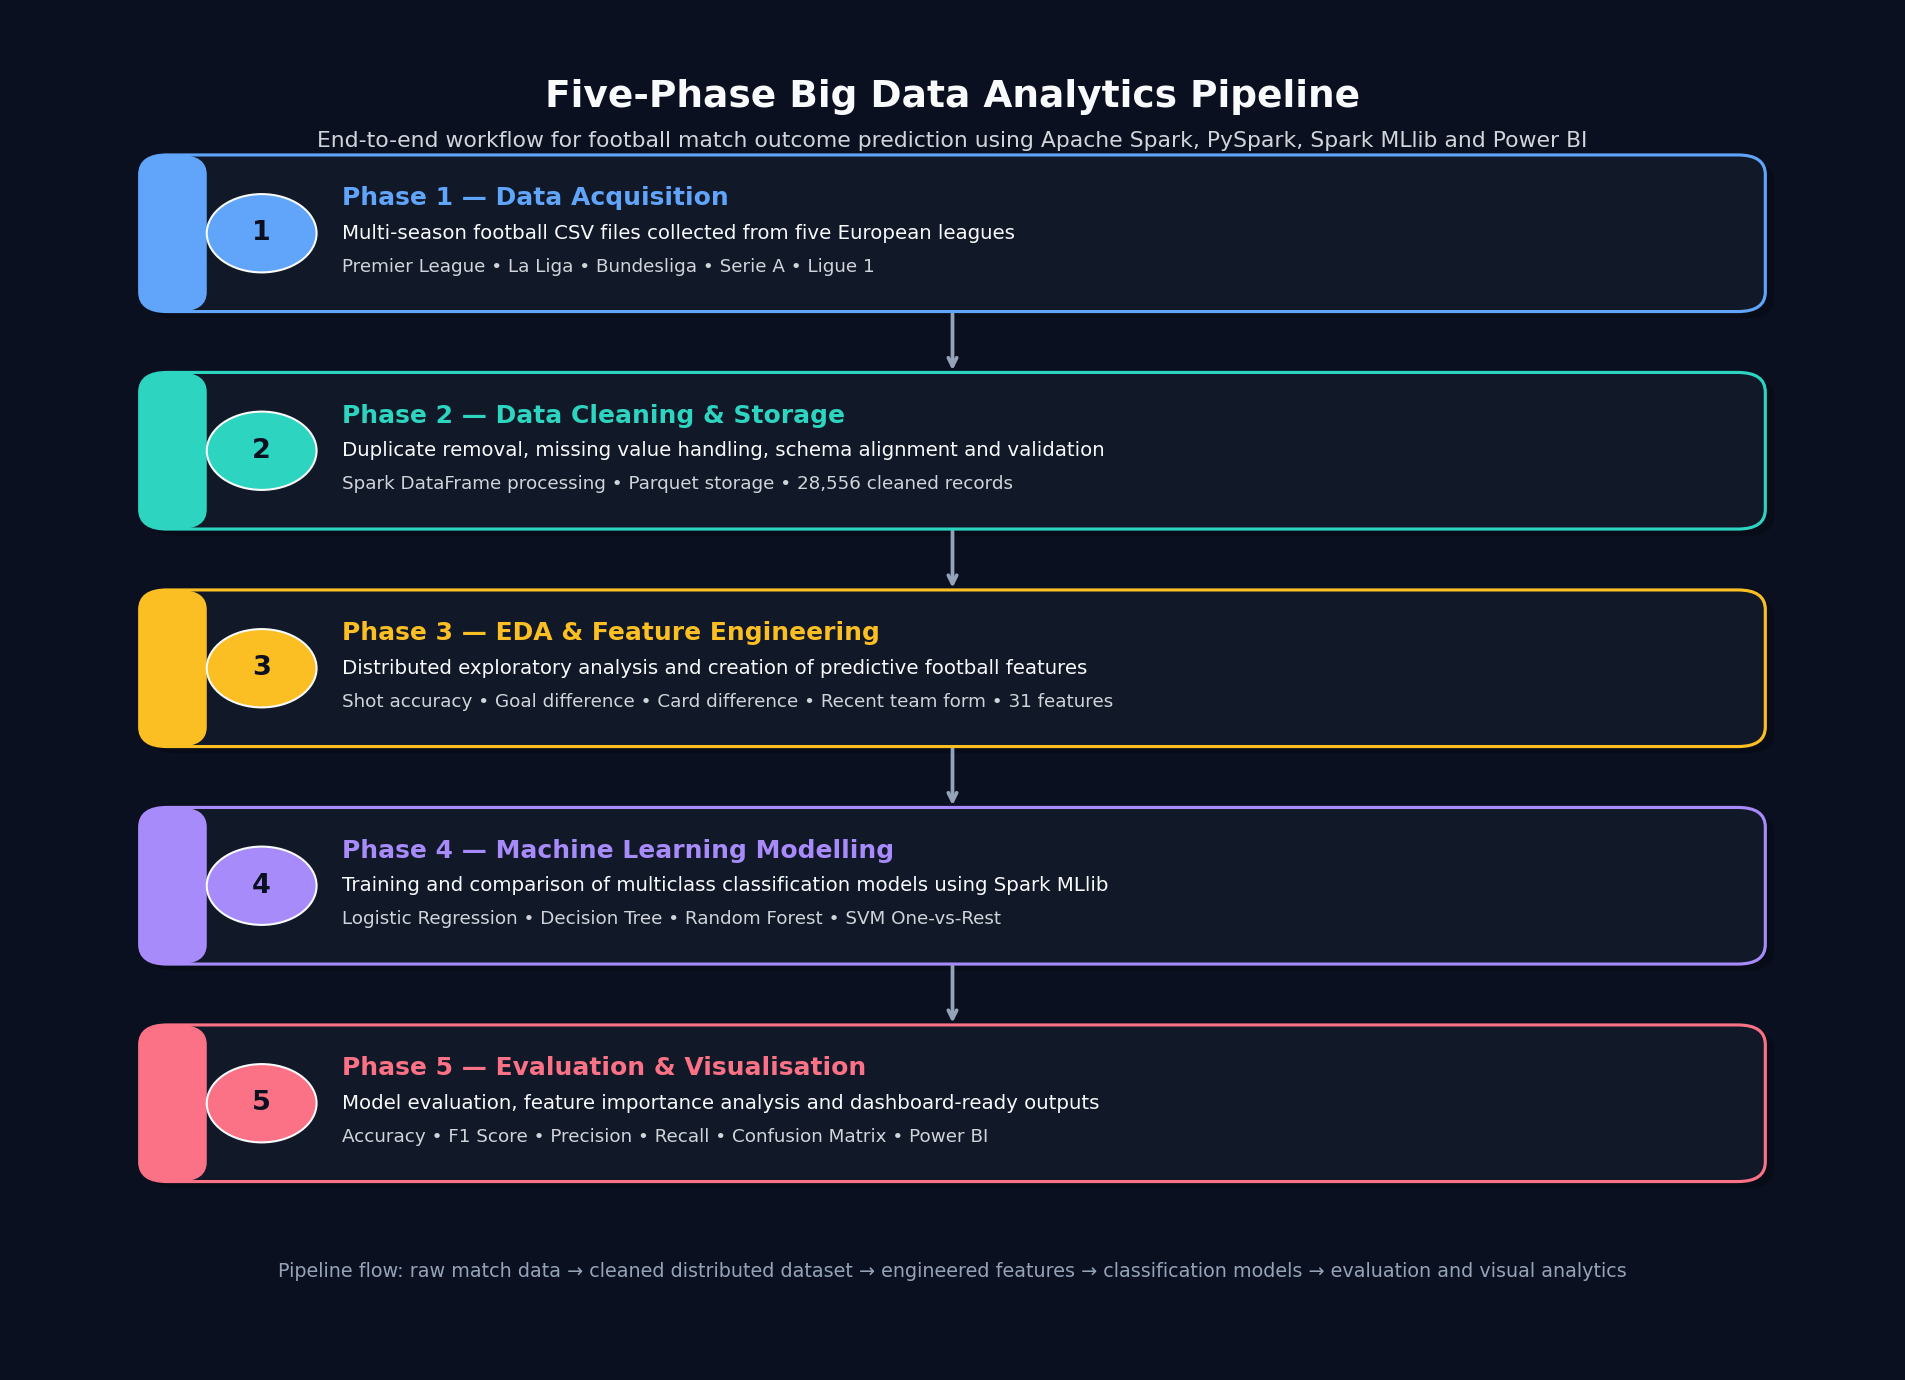

In [5]:
# ============================================================
# FIGURE 1: FIVE-PHASE BIG DATA ANALYTICS PIPELINE
# Football Match Outcome Prediction using Apache Spark MLlib
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Figure setup
fig, ax = plt.subplots(figsize=(12.5, 9))
fig.patch.set_facecolor(PALETTE["dark"])
ax.set_facecolor(PALETTE["dark"])

ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
ax.axis("off")

# Pipeline stages
stages = [
    {
        "title": "Phase 1 — Data Acquisition",
        "subtitle": "Multi-season football CSV files collected from five European leagues",
        "details": "Premier League • La Liga • Bundesliga • Serie A • Ligue 1",
        "color": PALETTE["blue"],
        "y": 10.2
    },
    {
        "title": "Phase 2 — Data Cleaning & Storage",
        "subtitle": "Duplicate removal, missing value handling, schema alignment and validation",
        "details": "Spark DataFrame processing • Parquet storage • 28,556 cleaned records",
        "color": PALETTE["teal"],
        "y": 8.2
    },
    {
        "title": "Phase 3 — EDA & Feature Engineering",
        "subtitle": "Distributed exploratory analysis and creation of predictive football features",
        "details": "Shot accuracy • Goal difference • Card difference • Recent team form • 31 features",
        "color": PALETTE["amber"],
        "y": 6.2
    },
    {
        "title": "Phase 4 — Machine Learning Modelling",
        "subtitle": "Training and comparison of multiclass classification models using Spark MLlib",
        "details": "Logistic Regression • Decision Tree • Random Forest • SVM One-vs-Rest",
        "color": PALETTE["purple"],
        "y": 4.2
    },
    {
        "title": "Phase 5 — Evaluation & Visualisation",
        "subtitle": "Model evaluation, feature importance analysis and dashboard-ready outputs",
        "details": "Accuracy • F1 Score • Precision • Recall • Confusion Matrix • Power BI",
        "color": PALETTE["coral"],
        "y": 2.2
    }
]

box_x = 0.75
box_width = 10.5
box_height = 1.28

# Title
ax.text(
    6,
    11.45,
    "Five-Phase Big Data Analytics Pipeline",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold",
    color=PALETTE["light"]
)

# Subtitle
ax.text(
    6,
    11.05,
    "End-to-end workflow for football match outcome prediction using Apache Spark, PySpark, Spark MLlib and Power BI",
    ha="center",
    va="center",
    fontsize=10.5,
    color=PALETTE["muted"]
)

# Draw stages
for index, stage in enumerate(stages):
    y = stage["y"]

    # Shadow layer
    shadow = mpatches.FancyBboxPatch(
        (box_x + 0.06, y - box_height / 2 - 0.06),
        box_width,
        box_height,
        boxstyle="round,pad=0.08,rounding_size=0.18",
        linewidth=0,
        facecolor="#000000",
        alpha=0.22,
        zorder=1
    )
    ax.add_patch(shadow)

    # Main stage box
    box = mpatches.FancyBboxPatch(
        (box_x, y - box_height / 2),
        box_width,
        box_height,
        boxstyle="round,pad=0.08,rounding_size=0.18",
        linewidth=1.5,
        edgecolor=stage["color"],
        facecolor=PALETTE["panel"],
        zorder=2
    )
    ax.add_patch(box)

    # Left colour strip
    strip = mpatches.FancyBboxPatch(
        (box_x, y - box_height / 2),
        0.28,
        box_height,
        boxstyle="round,pad=0.08,rounding_size=0.18",
        linewidth=0,
        facecolor=stage["color"],
        zorder=3
    )
    ax.add_patch(strip)

    # Phase number circle
    circle = mpatches.Circle(
        (box_x + 0.72, y),
        0.36,
        facecolor=stage["color"],
        edgecolor=PALETTE["light"],
        linewidth=1.0,
        zorder=4
    )
    ax.add_patch(circle)

    ax.text(
        box_x + 0.72,
        y,
        str(index + 1),
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color=PALETTE["dark"],
        zorder=5
    )

    # Text content
    ax.text(
        box_x + 1.25,
        y + 0.32,
        stage["title"],
        ha="left",
        va="center",
        fontsize=12,
        fontweight="bold",
        color=stage["color"],
        zorder=5
    )

    ax.text(
        box_x + 1.25,
        y,
        stage["subtitle"],
        ha="left",
        va="center",
        fontsize=9.5,
        color=PALETTE["light"],
        zorder=5
    )

    ax.text(
        box_x + 1.25,
        y - 0.31,
        stage["details"],
        ha="left",
        va="center",
        fontsize=8.8,
        color=PALETTE["muted"],
        zorder=5
    )

    # Arrow to next stage
    if index < len(stages) - 1:
        next_y = stages[index + 1]["y"]
        ax.annotate(
            "",
            xy=(6, next_y + box_height / 2 + 0.10),
            xytext=(6, y - box_height / 2 - 0.10),
            arrowprops=dict(
                arrowstyle="->",
                color=PALETTE["gray"],
                lw=1.8,
                shrinkA=0,
                shrinkB=0
            ),
            zorder=1
        )

# Footer note
ax.text(
    6,
    0.65,
    "Pipeline flow: raw match data → cleaned distributed dataset → engineered features → classification models → evaluation and visual analytics",
    ha="center",
    va="center",
    fontsize=9.2,
    color=PALETTE["gray"]
)

plt.tight_layout()

# Save figure
save_figure("figure_01_big_data_pipeline.png")

plt.show()

## Figure 2: Match Result Distribution (Donut Chart)

Figure saved: ../results/visualizations/figure_02_match_result_distribution.png


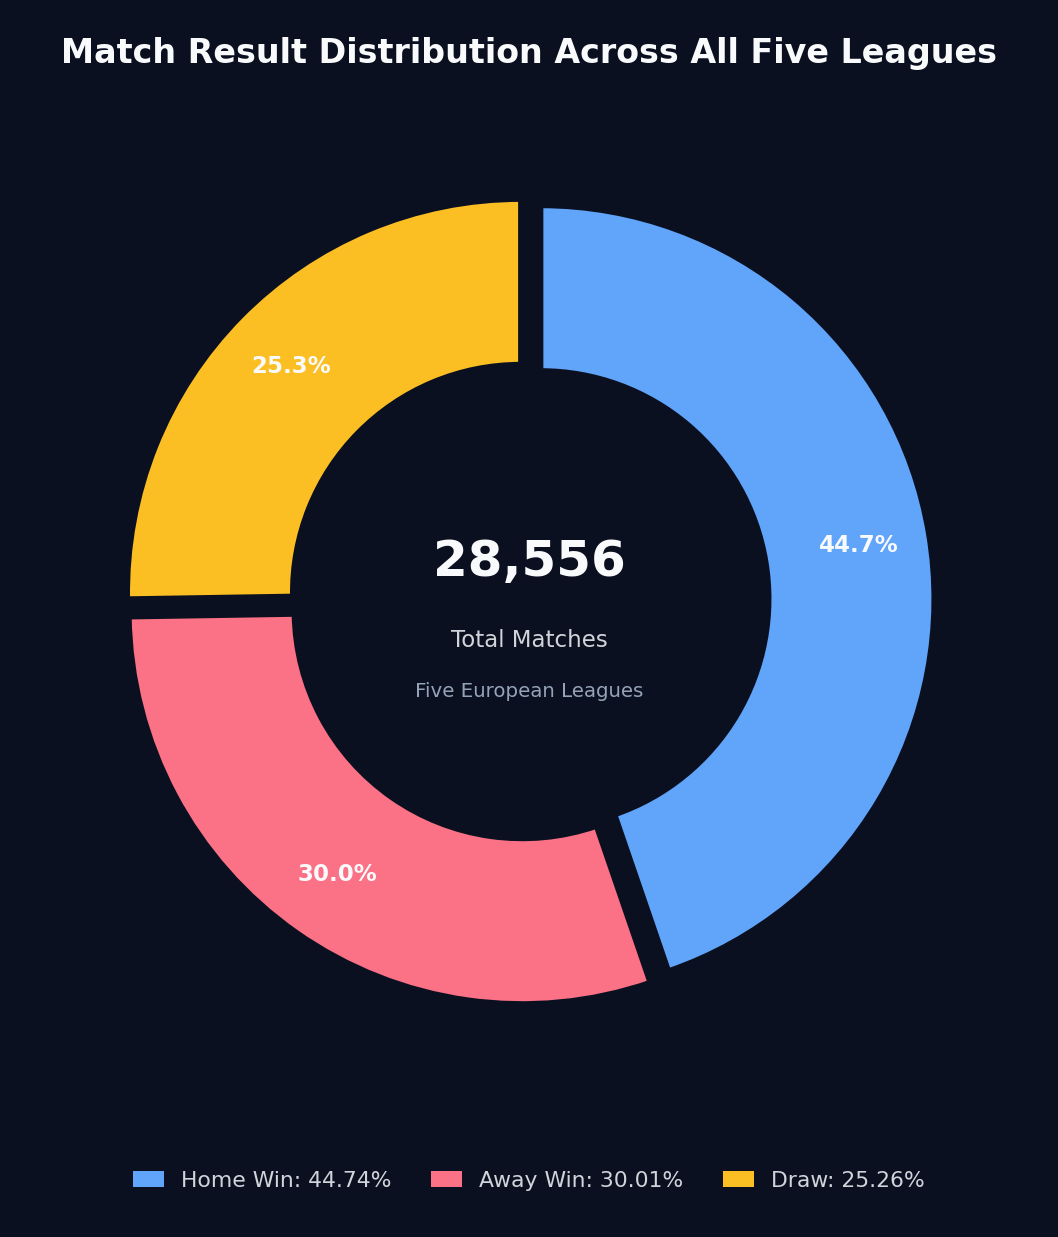

In [3]:
# ============================================================
# FIGURE 2: MATCH RESULT DISTRIBUTION (DONUT CHART)
# ============================================================

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(aspect="equal"))
fig.patch.set_facecolor(PALETTE["dark"])
ax.set_facecolor(PALETTE["dark"])

# Data
labels = ["Home Win", "Away Win", "Draw"]
sizes = [44.74, 30.01, 25.26]
colors = [
    OUTCOME_COLORS["Home Win"],
    OUTCOME_COLORS["Away Win"],
    OUTCOME_COLORS["Draw"]
]
explode = (0.03, 0.03, 0.03)

# Donut chart
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,
    colors=colors,
    explode=explode,
    startangle=90,
    counterclock=False,
    autopct="%1.1f%%",
    pctdistance=0.82,
    wedgeprops=dict(width=0.42, edgecolor=PALETTE["dark"], linewidth=2.5),
    textprops=dict(color=PALETTE["light"], fontsize=11, fontweight="bold")
)

# Style percentage labels
for autotext in autotexts:
    autotext.set_color(PALETTE["light"])
    autotext.set_fontsize(11)
    autotext.set_fontweight("bold")

# Centre text
ax.text(
    0, 0.10, "28,556",
    ha="center", va="center",
    fontsize=24, fontweight="bold", color=PALETTE["light"]
)
ax.text(
    0, -0.10, "Total Matches",
    ha="center", va="center",
    fontsize=11, color=PALETTE["muted"]
)
ax.text(
    0, -0.23, "Five European Leagues",
    ha="center", va="center",
    fontsize=9.5, color=PALETTE["gray"]
)

# Title
ax.set_title(
    "Match Result Distribution Across All Five Leagues",
    fontsize=16,
    fontweight="bold",
    color=PALETTE["light"],
    pad=22
)

# Custom legend
legend_labels = [
    f"{label}: {size:.2f}%"
    for label, size in zip(labels, sizes)
]

legend_handles = [
    mpatches.Patch(facecolor=color, edgecolor="none", label=legend_label)
    for color, legend_label in zip(colors, legend_labels)
]

legend = ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False,
    fontsize=10.5,
    handlelength=1.4,
    columnspacing=1.8
)

for text in legend.get_texts():
    text.set_color(PALETTE["muted"])

# Remove axes
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()

# Save figure
save_figure("figure_02_match_result_distribution.png")

plt.show()

## Figure 3: Number of Matches per League

Figure saved: ../results/visualizations/figure_03_matches_per_league.png


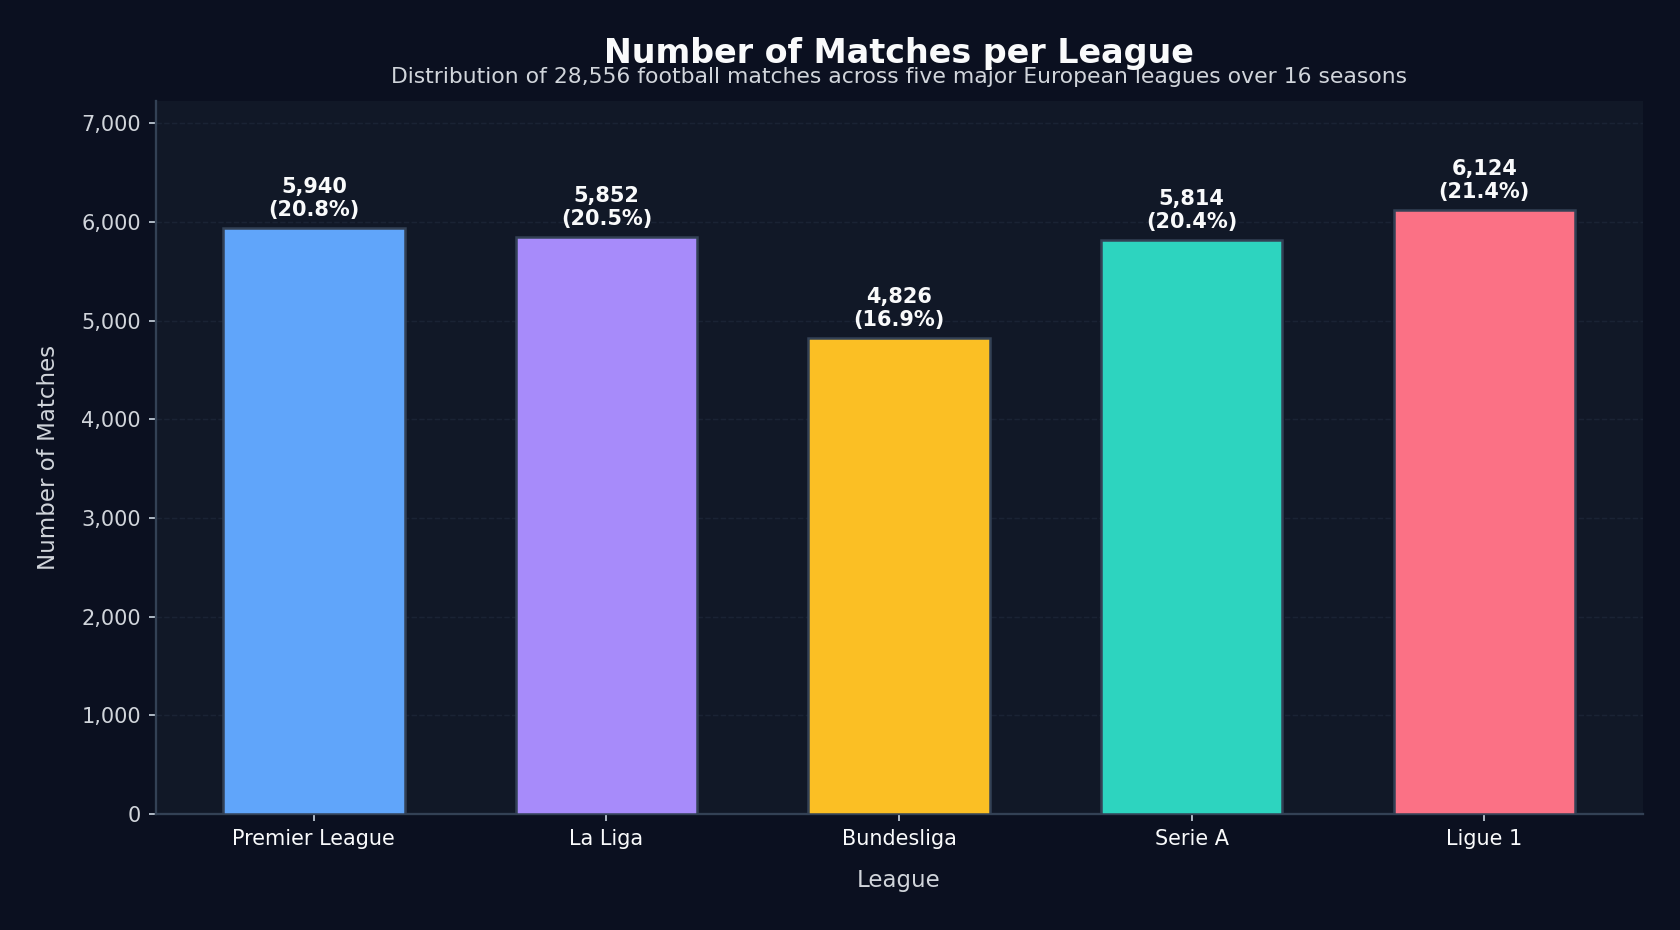

In [4]:
# ============================================================
# FIGURE 3: NUMBER OF MATCHES PER LEAGUE
# ============================================================

# Data
leagues = ["Premier League", "La Liga", "Bundesliga", "Serie A", "Ligue 1"]
matches = [5940, 5852, 4826, 5814, 6124]
total_matches = sum(matches)

colors = [
    PALETTE["blue"],
    PALETTE["purple"],
    PALETTE["amber"],
    PALETTE["teal"],
    PALETTE["coral"]
]

# Figure
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(PALETTE["dark"])
ax.set_facecolor(PALETTE["panel"])

# Bars
bars = ax.bar(
    leagues,
    matches,
    color=colors,
    width=0.62,
    edgecolor=PALETTE["border"],
    linewidth=1.2,
    zorder=3
)

# Value labels above bars
for bar, value in zip(bars, matches):
    percentage = (value / total_matches) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f"{value:,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=PALETTE["light"]
    )

# Titles
ax.set_title(
    "Number of Matches per League",
    fontsize=16,
    fontweight="bold",
    color=PALETTE["light"],
    pad=18
)

ax.text(
    0.5, 1.02,
    "Distribution of 28,556 football matches across five major European leagues over 16 seasons",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10.5,
    color=PALETTE["muted"]
)

# Axis labels
ax.set_xlabel("League", fontsize=11, color=PALETTE["muted"], labelpad=10)
ax.set_ylabel("Number of Matches", fontsize=11, color=PALETTE["muted"], labelpad=10)

# Y-axis formatting
ax.set_ylim(0, max(matches) * 1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_axisbelow(True)

# Grid styling
ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.45)
ax.grid(axis="x", visible=False)

# Spine styling
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color(PALETTE["border"])
ax.spines["bottom"].set_color(PALETTE["border"])

# Tick styling
plt.xticks(fontsize=10, color=PALETTE["light"])
plt.yticks(fontsize=10, color=PALETTE["muted"])

plt.tight_layout()

# Save figure
save_figure("figure_03_matches_per_league.png")

plt.show()

## Figure 4: League-Wise Goal Analysis (Home vs Away)

Figure saved: ../results/visualizations/figure_04_league_goal_analysis.png


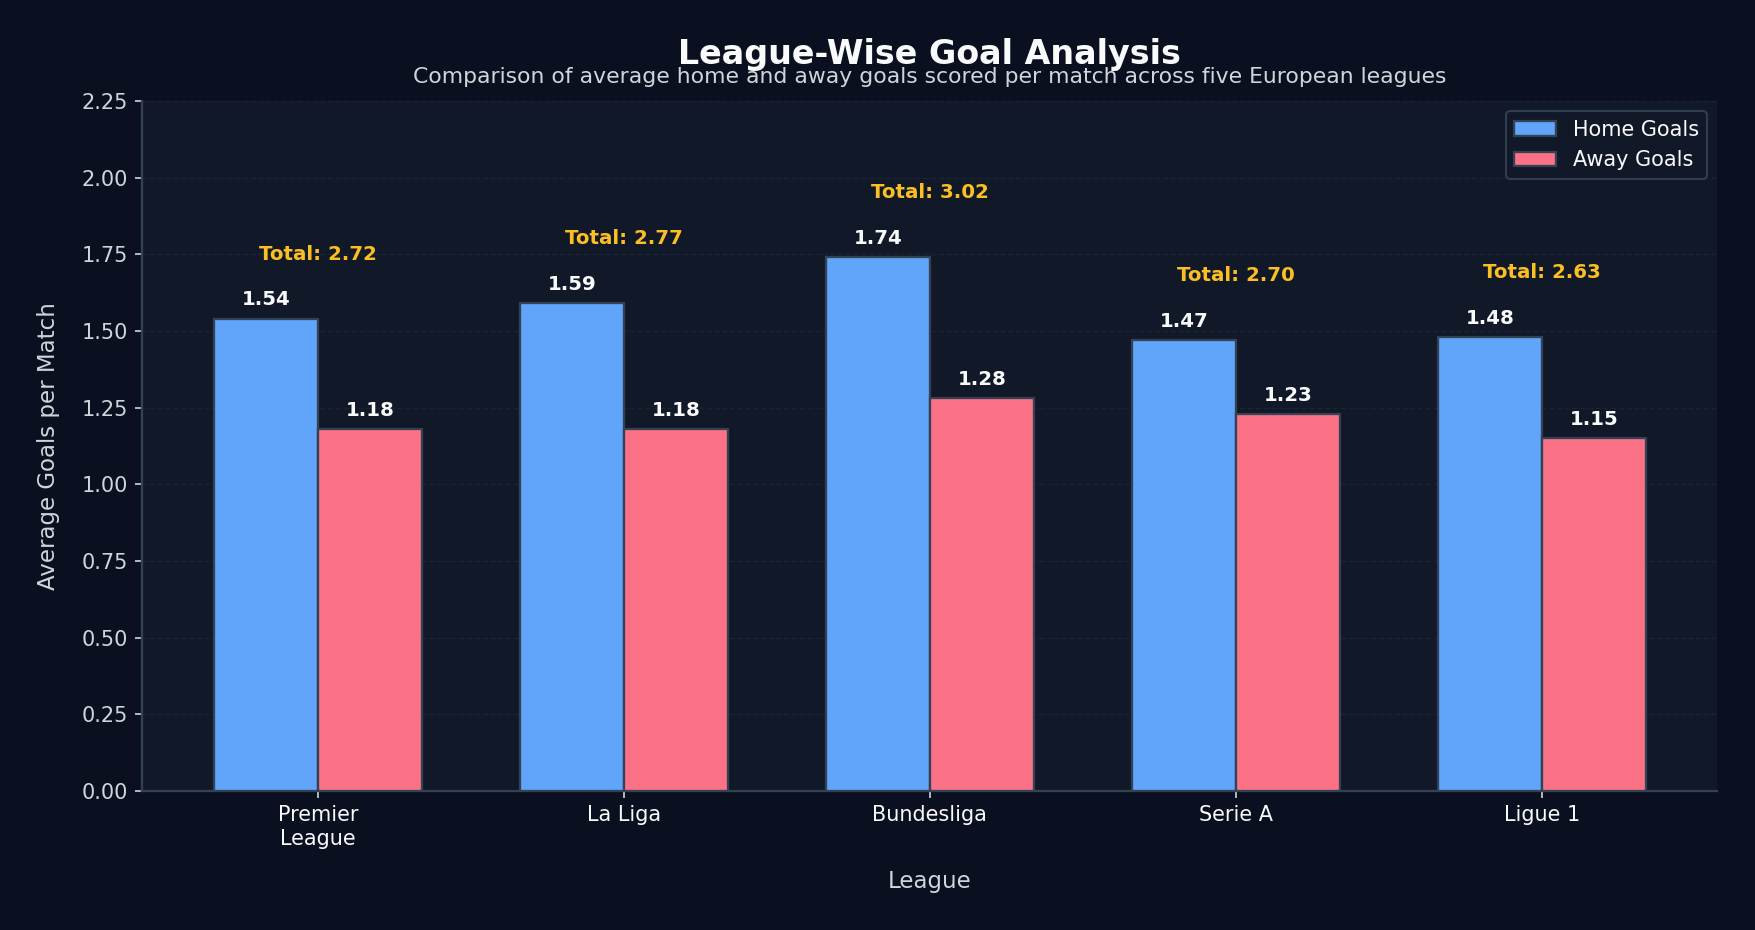

In [5]:
# ============================================================
# FIGURE 4: LEAGUE-WISE GOAL ANALYSIS
# Home Goals vs Away Goals per Match
# ============================================================

# Data
leagues = ["Premier\nLeague", "La Liga", "Bundesliga", "Serie A", "Ligue 1"]
home_goals = [1.54, 1.59, 1.74, 1.47, 1.48]
away_goals = [1.18, 1.18, 1.28, 1.23, 1.15]
total_goals = [h + a for h, a in zip(home_goals, away_goals)]

x = np.arange(len(leagues))
width = 0.34

# Figure
fig, ax = plt.subplots(figsize=(11.5, 6))
fig.patch.set_facecolor(PALETTE["dark"])
ax.set_facecolor(PALETTE["panel"])

# Bars
bars_home = ax.bar(
    x - width / 2,
    home_goals,
    width,
    label="Home Goals",
    color=PALETTE["blue"],
    edgecolor=PALETTE["border"],
    linewidth=1.1,
    zorder=3
)

bars_away = ax.bar(
    x + width / 2,
    away_goals,
    width,
    label="Away Goals",
    color=PALETTE["coral"],
    edgecolor=PALETTE["border"],
    linewidth=1.1,
    zorder=3
)

# Value labels for home goals
for bar, value in zip(bars_home, home_goals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9.5,
        fontweight="bold",
        color=PALETTE["light"]
    )

# Value labels for away goals
for bar, value in zip(bars_away, away_goals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9.5,
        fontweight="bold",
        color=PALETTE["light"]
    )

# Total goals annotation above each league
for i, total in enumerate(total_goals):
    ax.text(
        x[i],
        max(home_goals[i], away_goals[i]) + 0.18,
        f"Total: {total:.2f}",
        ha="center",
        va="bottom",
        fontsize=9.5,
        fontweight="bold",
        color=PALETTE["amber"]
    )

# Title and subtitle
ax.set_title(
    "League-Wise Goal Analysis",
    fontsize=16,
    fontweight="bold",
    color=PALETTE["light"],
    pad=18
)

ax.text(
    0.5, 1.02,
    "Comparison of average home and away goals scored per match across five European leagues",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10.5,
    color=PALETTE["muted"]
)

# Axes labels
ax.set_xlabel("League", fontsize=11, color=PALETTE["muted"], labelpad=10)
ax.set_ylabel("Average Goals per Match", fontsize=11, color=PALETTE["muted"], labelpad=10)

# Ticks
ax.set_xticks(x)
ax.set_xticklabels(leagues, fontsize=10, color=PALETTE["light"])
ax.tick_params(axis="y", labelsize=10, colors=PALETTE["muted"])

# Limits and grid
ax.set_ylim(0, 2.25)
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.45)
ax.grid(axis="x", visible=False)

# Legend
legend = ax.legend(
    loc="upper right",
    frameon=True,
    facecolor=PALETTE["panel"],
    edgecolor=PALETTE["border"],
    fontsize=10
)

for text in legend.get_texts():
    text.set_color(PALETTE["light"])

# Spine styling
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color(PALETTE["border"])
ax.spines["bottom"].set_color(PALETTE["border"])

plt.tight_layout()

# Save figure
save_figure("figure_04_league_goal_analysis.png")

plt.show()

## Figure 5: Comparative Model Performance

Figure saved: ../results/visualizations/figure_05_model_performance_comparison.png


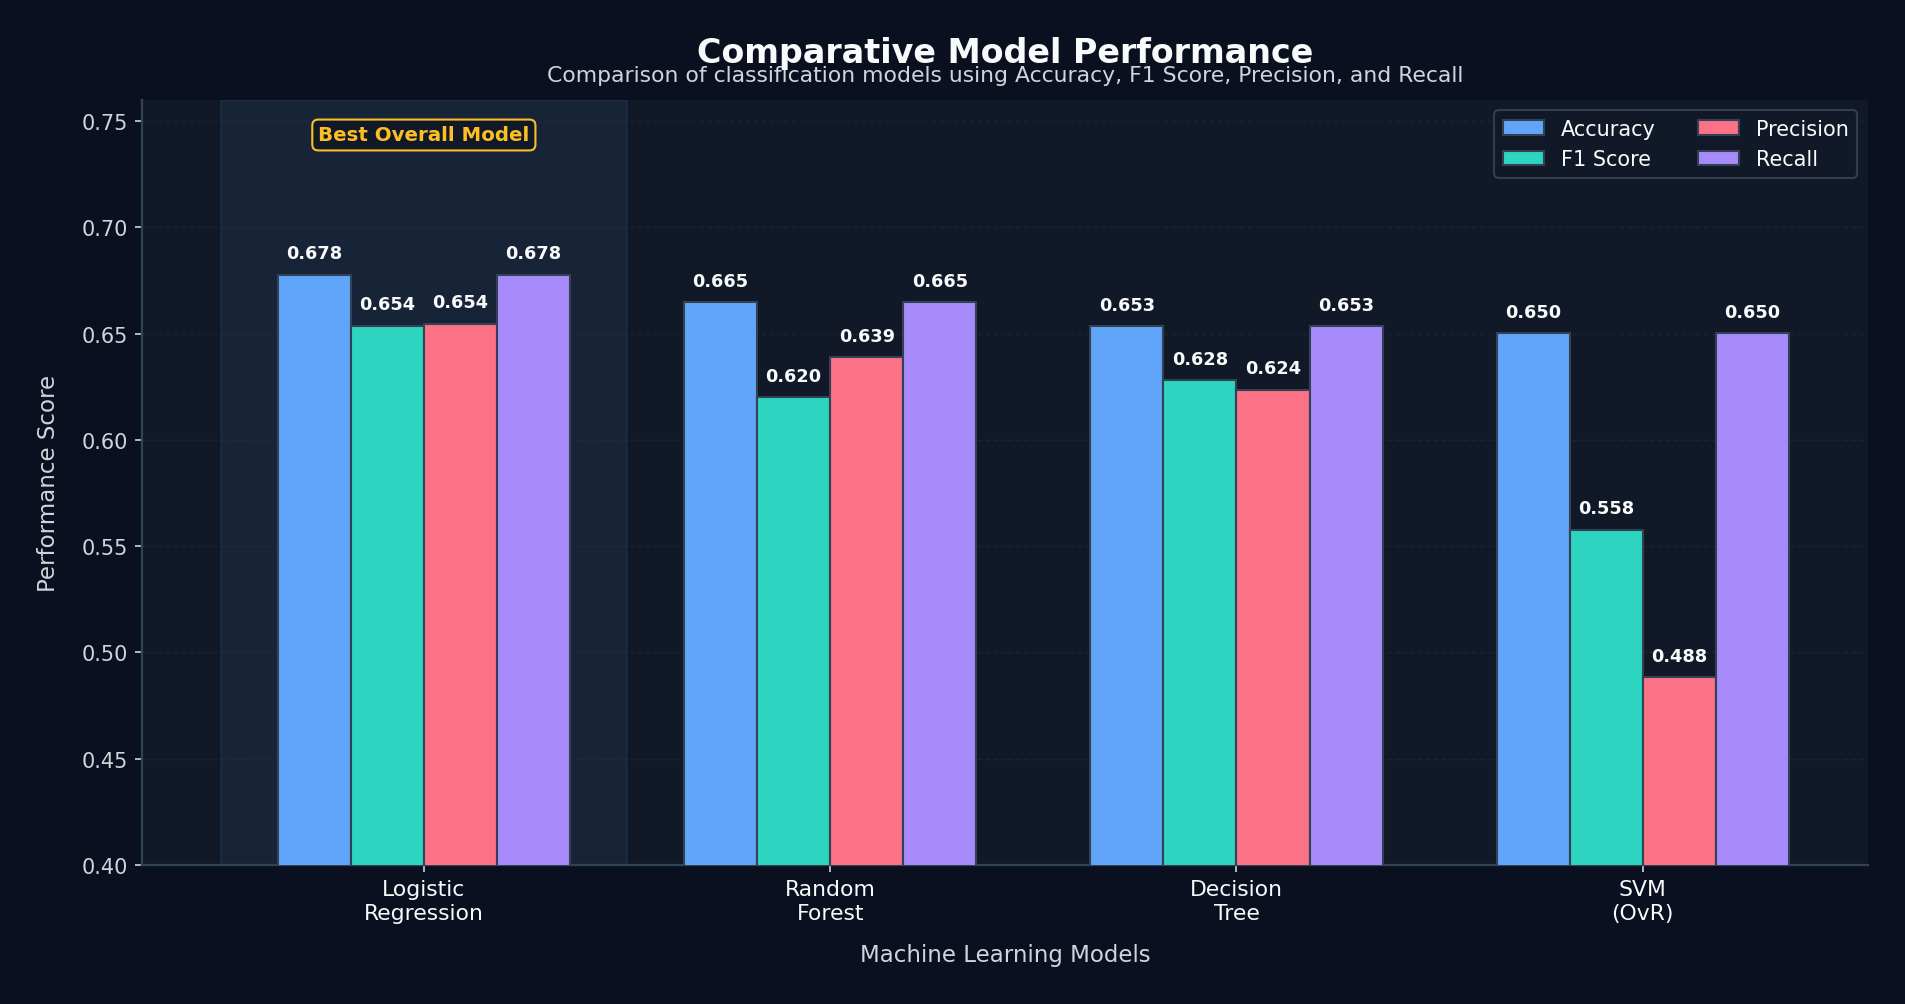

In [6]:
# ============================================================
# FIGURE 5: COMPARATIVE MODEL PERFORMANCE
# Accuracy, F1 Score, Precision, and Recall
# ============================================================

# Data
models = ["Logistic\nRegression", "Random\nForest", "Decision\nTree", "SVM\n(OvR)"]
accuracy = [0.6778, 0.6648, 0.6535, 0.6502]
f1_score = [0.6537, 0.6200, 0.6280, 0.5576]
precision = [0.6545, 0.6389, 0.6237, 0.4882]
recall = [0.6778, 0.6648, 0.6535, 0.6502]

x = np.arange(len(models))
width = 0.18

metrics = [accuracy, f1_score, precision, recall]
metric_labels = ["Accuracy", "F1 Score", "Precision", "Recall"]
metric_colors = [
    PALETTE["blue"],
    PALETTE["teal"],
    PALETTE["coral"],
    PALETTE["purple"]
]
offsets = [-1.5 * width, -0.5 * width, 0.5 * width, 1.5 * width]

# Figure
fig, ax = plt.subplots(figsize=(12.5, 6.5))
fig.patch.set_facecolor(PALETTE["dark"])
ax.set_facecolor(PALETTE["panel"])

# Highlight best model region (Logistic Regression)
ax.axvspan(-0.5, 0.5, color=PALETTE["blue"], alpha=0.08, zorder=0)

# Plot grouped bars
for values, label, color, offset in zip(metrics, metric_labels, metric_colors, offsets):
    bars = ax.bar(
        x + offset,
        values,
        width,
        label=label,
        color=color,
        edgecolor=PALETTE["border"],
        linewidth=1.0,
        zorder=3
    )

    # Value labels
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.006,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=8.5,
            fontweight="bold",
            color=PALETTE["light"]
        )

# Title and subtitle
ax.set_title(
    "Comparative Model Performance",
    fontsize=16,
    fontweight="bold",
    color=PALETTE["light"],
    pad=18
)

ax.text(
    0.5, 1.02,
    "Comparison of classification models using Accuracy, F1 Score, Precision, and Recall",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10.5,
    color=PALETTE["muted"]
)

# Axes labels
ax.set_xlabel("Machine Learning Models", fontsize=11, color=PALETTE["muted"], labelpad=10)
ax.set_ylabel("Performance Score", fontsize=11, color=PALETTE["muted"], labelpad=10)

# Ticks
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10.5, color=PALETTE["light"])
ax.tick_params(axis="y", labelsize=10, colors=PALETTE["muted"])

# Limits
ax.set_ylim(0.40, 0.76)
ax.set_axisbelow(True)

# Grid styling
ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.45)
ax.grid(axis="x", visible=False)

# Best model annotation
ax.text(
    0,
    0.748,
    "Best Overall Model",
    ha="center",
    va="top",
    fontsize=9.5,
    fontweight="bold",
    color=PALETTE["amber"],
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor=PALETTE["panel"],
        edgecolor=PALETTE["amber"],
        linewidth=1
    )
)

# Legend
legend = ax.legend(
    loc="upper right",
    ncol=2,
    frameon=True,
    facecolor=PALETTE["panel"],
    edgecolor=PALETTE["border"],
    fontsize=10
)

for text in legend.get_texts():
    text.set_color(PALETTE["light"])

# Spine styling
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color(PALETTE["border"])
ax.spines["bottom"].set_color(PALETTE["border"])

plt.tight_layout()

# Save figure
save_figure("figure_05_model_performance_comparison.png")

plt.show()

## Figure 6: Top 10 Feature Importance (Random Forest)

Figure saved: ../results/visualizations/figure_06_random_forest_feature_importance.png


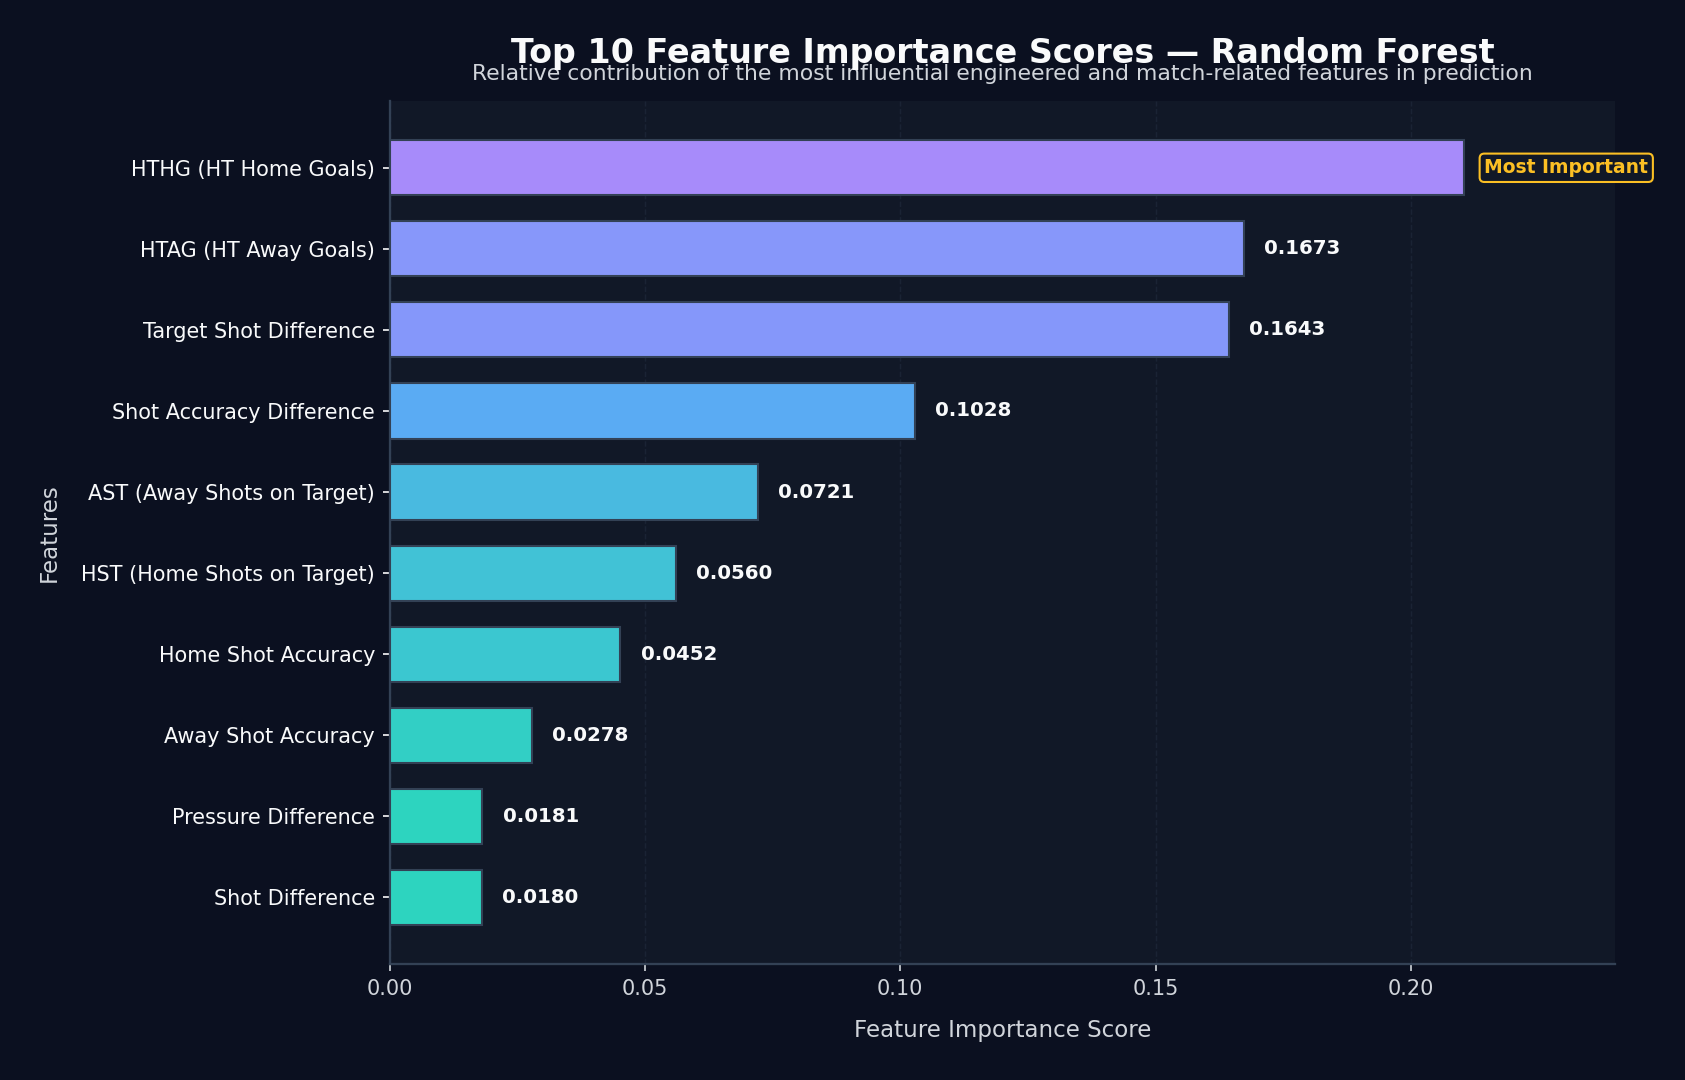

In [7]:
# ============================================================
# FIGURE 6: TOP 10 FEATURE IMPORTANCE SCORES — RANDOM FOREST
# ============================================================

# Data
features = [
    "HTHG (HT Home Goals)",
    "HTAG (HT Away Goals)",
    "Target Shot Difference",
    "Shot Accuracy Difference",
    "AST (Away Shots on Target)",
    "HST (Home Shots on Target)",
    "Home Shot Accuracy",
    "Away Shot Accuracy",
    "Pressure Difference",
    "Shot Difference",
]

importance = [0.2104, 0.1673, 0.1643, 0.1028, 0.0721,
              0.0560, 0.0452, 0.0278, 0.0181, 0.0180]

# Keep descending order for display
feature_data = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values("Importance", ascending=True)

# Gradient colors
cmap = LinearSegmentedColormap.from_list(
    "rf_importance_gradient",
    [PALETTE["teal"], PALETTE["blue"], PALETTE["purple"]]
)

norm = plt.Normalize(feature_data["Importance"].min(), feature_data["Importance"].max())
bar_colors = [cmap(norm(v)) for v in feature_data["Importance"]]

# Figure
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(PALETTE["dark"])
ax.set_facecolor(PALETTE["panel"])

# Horizontal bars
bars = ax.barh(
    feature_data["Feature"],
    feature_data["Importance"],
    color=bar_colors,
    edgecolor=PALETTE["border"],
    linewidth=1.0,
    height=0.68,
    zorder=3
)

# Value labels
for bar, value in zip(bars, feature_data["Importance"]):
    ax.text(
        bar.get_width() + 0.004,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}",
        va="center",
        ha="left",
        fontsize=9.5,
        fontweight="bold",
        color=PALETTE["light"]
    )

# Highlight most important feature
top_value = feature_data["Importance"].max()
top_index = feature_data["Importance"].idxmax()
top_position = list(feature_data.index).index(top_index)

ax.text(
    top_value + 0.004,
    top_position,
    "Most Important",
    va="center",
    ha="left",
    fontsize=9,
    fontweight="bold",
    color=PALETTE["amber"],
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor=PALETTE["panel"],
        edgecolor=PALETTE["amber"],
        linewidth=1
    )
)

# Title and subtitle
ax.set_title(
    "Top 10 Feature Importance Scores — Random Forest",
    fontsize=16,
    fontweight="bold",
    color=PALETTE["light"],
    pad=18
)

ax.text(
    0.5, 1.02,
    "Relative contribution of the most influential engineered and match-related features in prediction",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10.5,
    color=PALETTE["muted"]
)

# Axis labels
ax.set_xlabel("Feature Importance Score", fontsize=11, color=PALETTE["muted"], labelpad=10)
ax.set_ylabel("Features", fontsize=11, color=PALETTE["muted"], labelpad=10)

# Axis formatting
ax.set_xlim(0, 0.24)
ax.tick_params(axis="x", labelsize=10, colors=PALETTE["muted"])
ax.tick_params(axis="y", labelsize=10, colors=PALETTE["light"])
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

# Grid styling
ax.set_axisbelow(True)
ax.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.45)
ax.grid(axis="y", visible=False)

# Spines
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color(PALETTE["border"])
ax.spines["bottom"].set_color(PALETTE["border"])

plt.tight_layout()

# Save figure
save_figure("figure_06_random_forest_feature_importance.png")

plt.show()

## Figure 7: Logistic Regression Confusion Matrix

Figure saved: ../results/visualizations/figure_07_logistic_regression_confusion_matrix.png


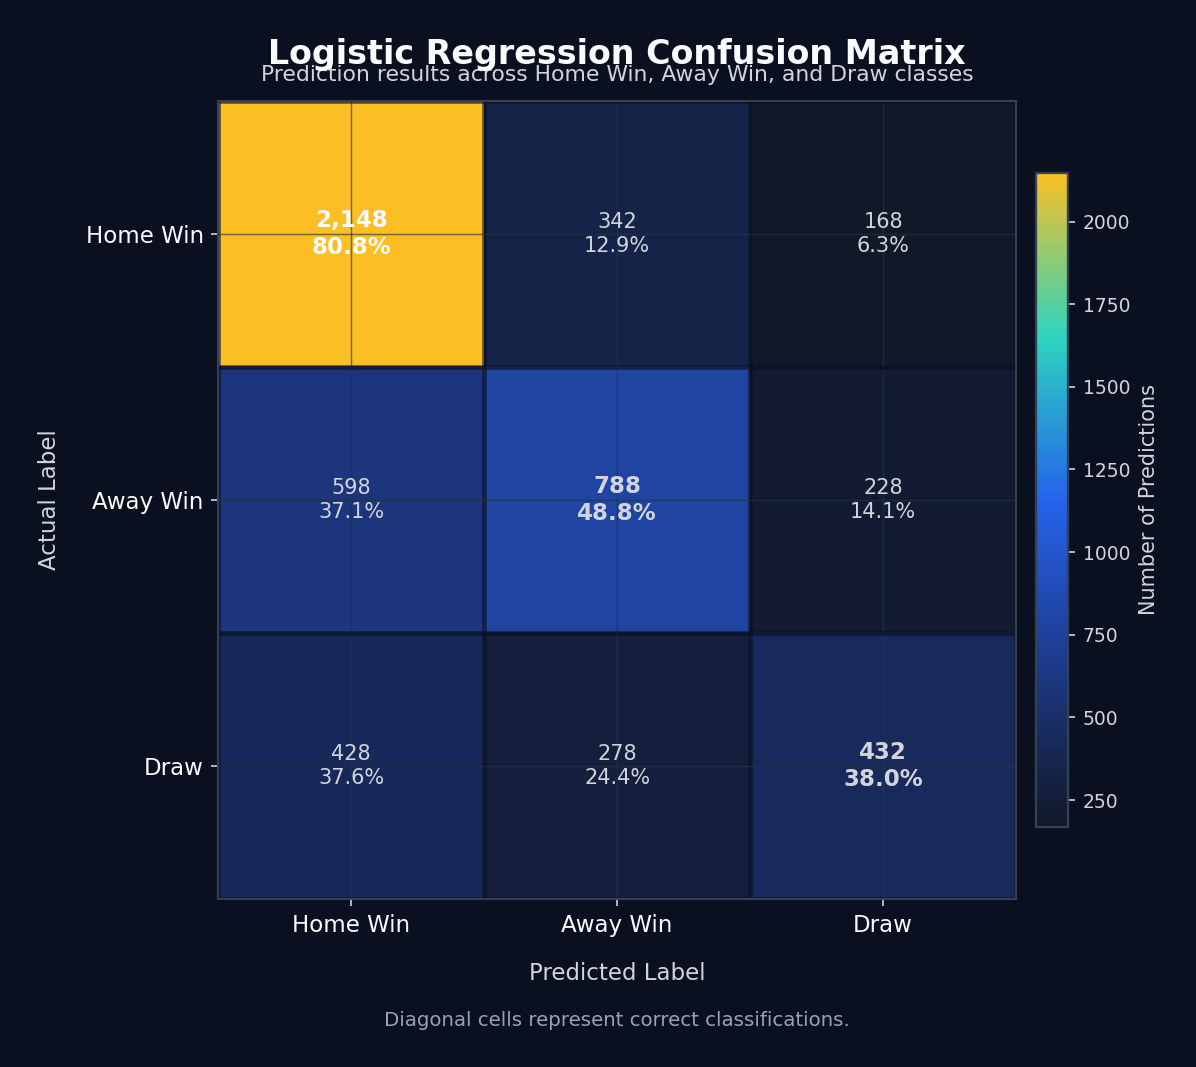

In [8]:
# ============================================================
# FIGURE 7: LOGISTIC REGRESSION CONFUSION MATRIX
# Predicted vs Actual Match Outcomes
# ============================================================

# Data
cm = np.array([
    [2148, 342, 168],
    [598,  788, 228],
    [428,  278, 432],
])

class_names = ["Home Win", "Away Win", "Draw"]

# Row-wise percentages for better interpretation
row_totals = cm.sum(axis=1, keepdims=True)
cm_percent = (cm / row_totals) * 100

# Figure
fig, ax = plt.subplots(figsize=(8, 6.8))
fig.patch.set_facecolor(PALETTE["dark"])
ax.set_facecolor(PALETTE["panel"])

# Heatmap
im = ax.imshow(cm, cmap=dark_gradient, aspect="equal")

# Major ticks
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, fontsize=11, color=PALETTE["light"])
ax.set_yticklabels(class_names, fontsize=11, color=PALETTE["light"])

# Minor grid lines between cells
ax.set_xticks(np.arange(-0.5, len(class_names), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(class_names), 1), minor=True)
ax.grid(which="minor", color=PALETTE["dark"], linestyle="-", linewidth=2.2)
ax.tick_params(which="minor", bottom=False, left=False)

# Cell annotations: count + percentage
threshold = cm.max() * 0.55
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        pct = cm_percent[i, j]

        is_diagonal = i == j
        text_color = PALETTE["light"] if count > threshold else PALETTE["muted"]

        ax.text(
            j, i,
            f"{count:,}\n{pct:.1f}%",
            ha="center",
            va="center",
            fontsize=11 if is_diagonal else 10,
            fontweight="bold" if is_diagonal else "normal",
            color=text_color
        )

# Title and subtitle
ax.set_title(
    "Logistic Regression Confusion Matrix",
    fontsize=16,
    fontweight="bold",
    color=PALETTE["light"],
    pad=18
)

ax.text(
    0.5, 1.02,
    "Prediction results across Home Win, Away Win, and Draw classes",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10.5,
    color=PALETTE["muted"]
)

# Axis labels
ax.set_xlabel("Predicted Label", fontsize=11, color=PALETTE["muted"], labelpad=12)
ax.set_ylabel("Actual Label", fontsize=11, color=PALETTE["muted"], labelpad=12)

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.82, pad=0.02)
cbar.set_label("Number of Predictions", color=PALETTE["muted"], fontsize=10)
cbar.outline.set_edgecolor(PALETTE["border"])
cbar.ax.tick_params(colors=PALETTE["muted"], labelsize=9)

# Optional note
ax.text(
    0.5, -0.14,
    "Diagonal cells represent correct classifications.",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=9.5,
    color=PALETTE["gray"]
)

# Spine styling
for spine in ax.spines.values():
    spine.set_edgecolor(PALETTE["border"])
    spine.set_linewidth(1.0)

plt.tight_layout()

# Save figure
save_figure("figure_07_logistic_regression_confusion_matrix.png")

plt.show()

## Figure 8: Top Scoring Teams Across All Leagues

Figure saved: ../results/visualizations/figure_08_top_scoring_teams.png


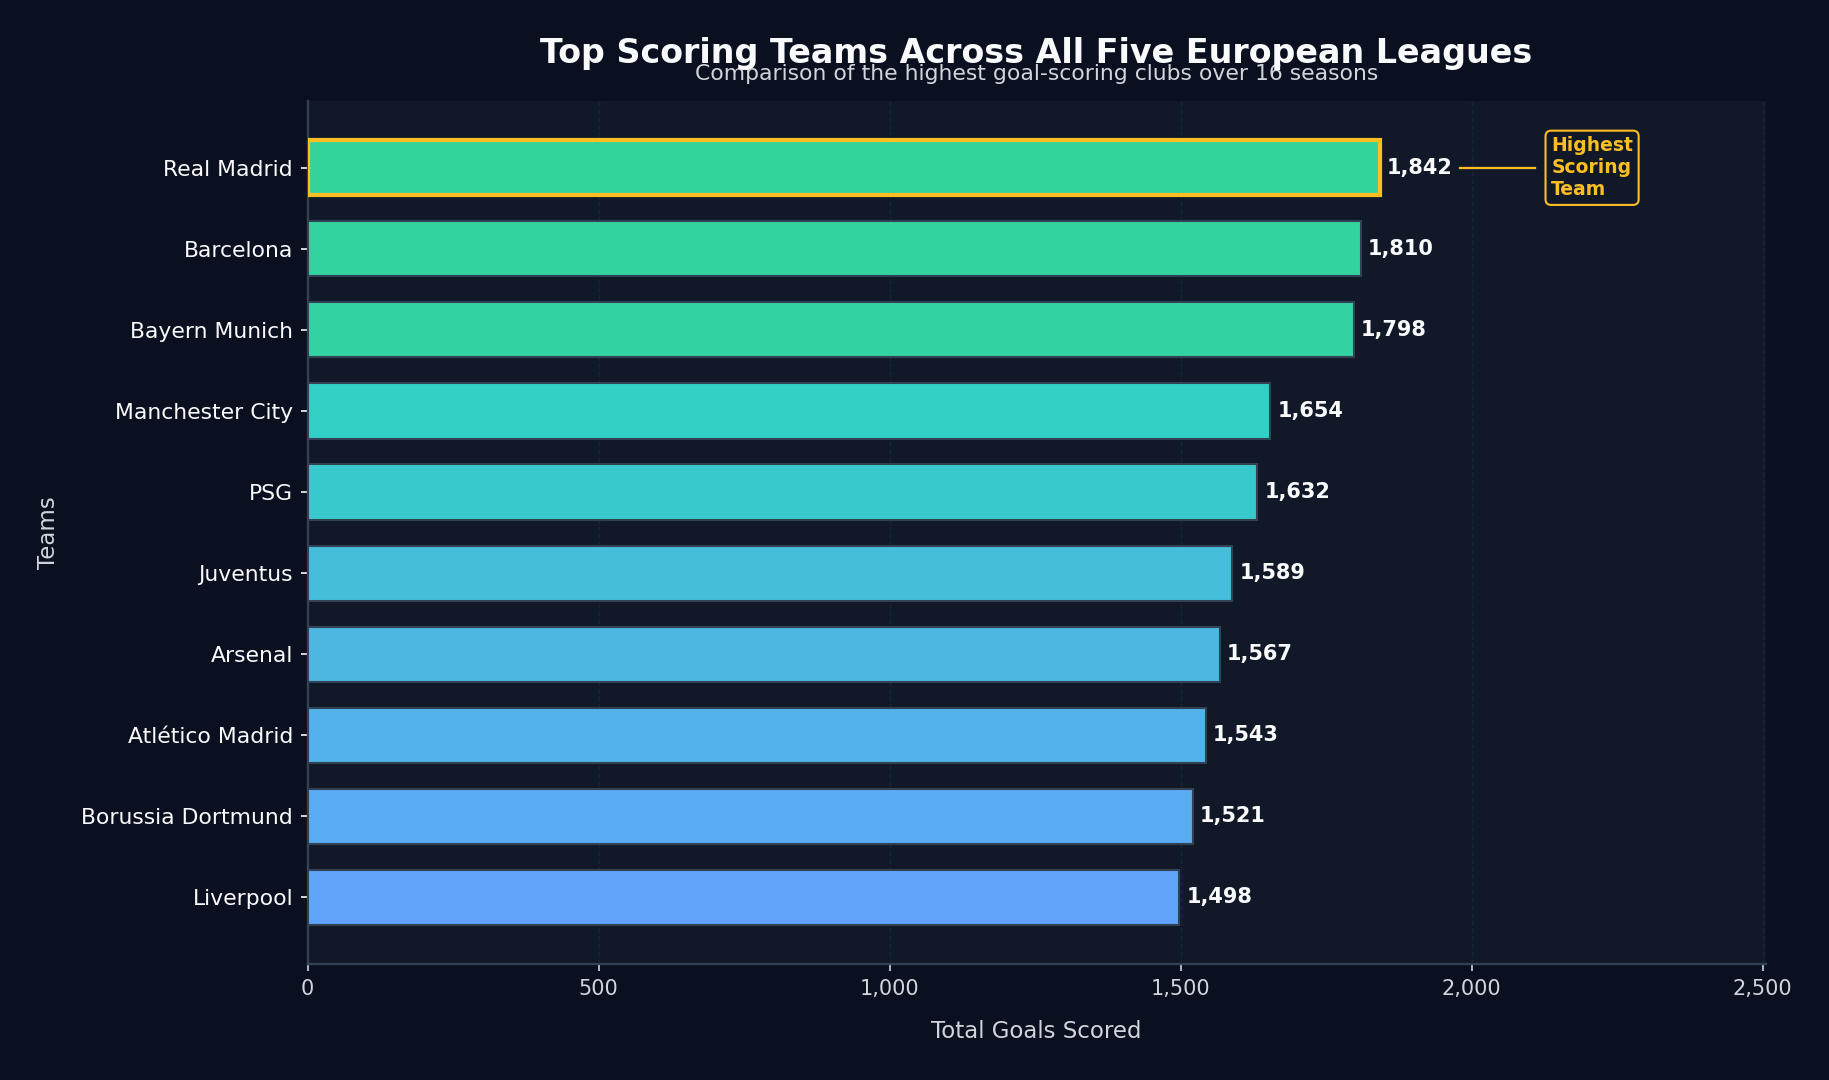

In [11]:
# ============================================================
# FIGURE 8: TOP SCORING TEAMS ACROSS ALL FIVE EUROPEAN LEAGUES
# ============================================================

# Data
teams = [
    "Real Madrid", "Barcelona", "Bayern Munich", "Manchester City",
    "PSG", "Juventus", "Arsenal", "Atlético Madrid",
    "Borussia Dortmund", "Liverpool"
]

goals = [1842, 1810, 1798, 1654, 1632, 1589, 1567, 1543, 1521, 1498]

# Create DataFrame and sort for clean horizontal display
team_goals_df = pd.DataFrame({
    "Team": teams,
    "Goals": goals
}).sort_values("Goals", ascending=True)

# Gradient colours
cmap = LinearSegmentedColormap.from_list(
    "team_goals_gradient",
    [PALETTE["blue"], PALETTE["teal"], PALETTE["green"]]
)

norm = plt.Normalize(team_goals_df["Goals"].min(), team_goals_df["Goals"].max())
bar_colors = [cmap(norm(v)) for v in team_goals_df["Goals"]]

# Figure
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(PALETTE["dark"])
ax.set_facecolor(PALETTE["panel"])

# Bars
bars = ax.barh(
    team_goals_df["Team"],
    team_goals_df["Goals"],
    color=bar_colors,
    edgecolor=PALETTE["border"],
    linewidth=1.0,
    height=0.68,
    zorder=3
)

# Identify top-scoring team
max_goal = team_goals_df["Goals"].max()
top_bar_index = team_goals_df["Goals"].idxmax()
top_bar_position = list(team_goals_df.index).index(top_bar_index)
top_bar = bars[top_bar_position]

# Highlight top-scoring team's bar
top_bar.set_edgecolor(PALETTE["amber"])
top_bar.set_linewidth(2.0)

# Value labels
for bar, value in zip(bars, team_goals_df["Goals"]):
    ax.text(
        bar.get_width() + 12,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color=PALETTE["light"]
    )

# Side label for top-scoring team without hiding goal value
label_y = top_bar.get_y() + top_bar.get_height() / 2
label_x = max_goal * 1.16

ax.text(
    label_x,
    label_y,
    "Highest\nScoring\nTeam",
    va="center",
    ha="left",
    fontsize=9,
    fontweight="bold",
    color=PALETTE["amber"],
    bbox=dict(
        boxstyle="round,pad=0.30",
        facecolor=PALETTE["panel"],
        edgecolor=PALETTE["amber"],
        linewidth=1.0
    ),
    zorder=5
)

# Connector line from top value area to side label
ax.plot(
    [max_goal * 1.075, max_goal * 1.145],
    [label_y, label_y],
    color=PALETTE["amber"],
    linewidth=1.1,
    linestyle="-",
    zorder=4
)

# Title and subtitle
ax.set_title(
    "Top Scoring Teams Across All Five European Leagues",
    fontsize=16,
    fontweight="bold",
    color=PALETTE["light"],
    pad=18
)

ax.text(
    0.5, 1.02,
    "Comparison of the highest goal-scoring clubs over 16 seasons",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10.5,
    color=PALETTE["muted"]
)

# Axis labels
ax.set_xlabel("Total Goals Scored", fontsize=11, color=PALETTE["muted"], labelpad=10)
ax.set_ylabel("Teams", fontsize=11, color=PALETTE["muted"], labelpad=10)

# Axis formatting
ax.set_xlim(0, team_goals_df["Goals"].max() * 1.36)
ax.tick_params(axis="x", labelsize=10, colors=PALETTE["muted"])
ax.tick_params(axis="y", labelsize=10.5, colors=PALETTE["light"])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Grid styling
ax.set_axisbelow(True)
ax.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.45)
ax.grid(axis="y", visible=False)

# Spine styling
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color(PALETTE["border"])
ax.spines["bottom"].set_color(PALETTE["border"])

plt.tight_layout()

# Save figure
save_figure("figure_08_top_scoring_teams.png")

plt.show()

## Figure 9: Half-Time to Full-Time Outcome Transitions

Figure saved: ../results/visualizations/figure_09_half_time_full_time_transitions.png


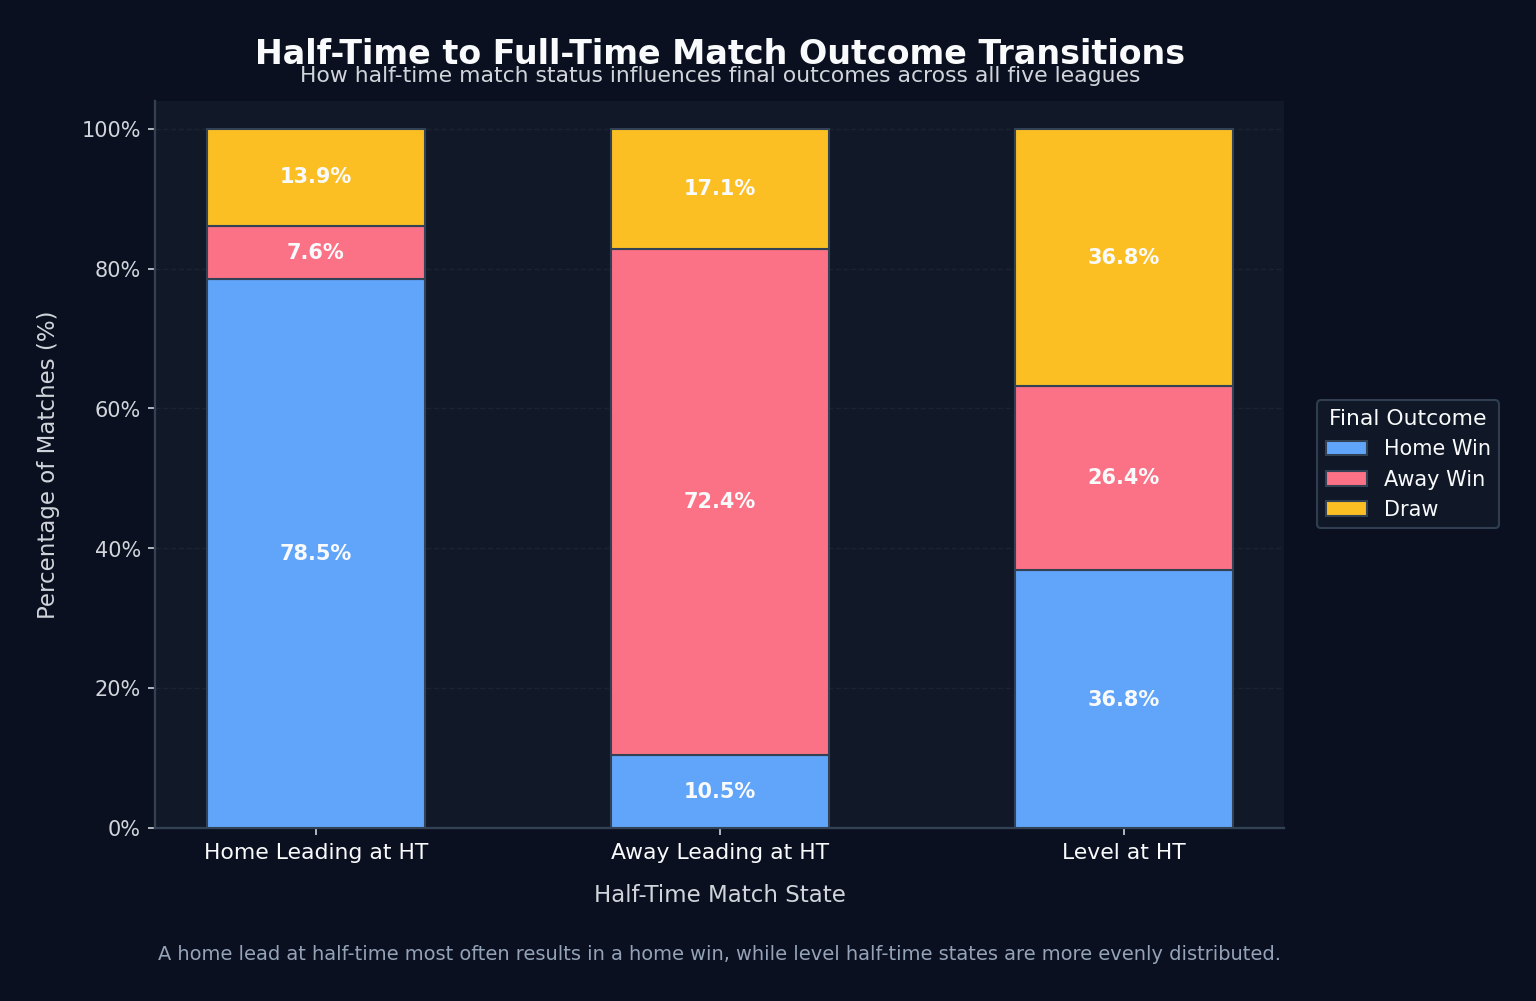

In [13]:
# ============================================================
# FIGURE 9: HALF-TIME TO FULL-TIME MATCH OUTCOME TRANSITIONS
# ============================================================

# Data
ht_states = ["Home Leading at HT", "Away Leading at HT", "Level at HT"]
home_win_pct = [78.51, 10.47, 36.84]
away_win_pct = [7.62, 72.38, 26.40]
draw_pct = [13.87, 17.15, 36.76]

x = np.arange(len(ht_states))
width = 0.54

# Figure
fig, ax = plt.subplots(figsize=(12, 6.5))
fig.patch.set_facecolor(PALETTE["dark"])
ax.set_facecolor(PALETTE["panel"])

# Colors
home_color = OUTCOME_COLORS["Home Win"]
away_color = OUTCOME_COLORS["Away Win"]
draw_color = PALETTE["amber"]

# Bottom values
bottom_away = home_win_pct
bottom_draw = [h + a for h, a in zip(home_win_pct, away_win_pct)]

# Stacked bars
bars_home = ax.bar(
    x,
    home_win_pct,
    width,
    label="Home Win",
    color=home_color,
    edgecolor=PALETTE["border"],
    linewidth=1.0,
    zorder=3
)

bars_away = ax.bar(
    x,
    away_win_pct,
    width,
    bottom=bottom_away,
    label="Away Win",
    color=away_color,
    edgecolor=PALETTE["border"],
    linewidth=1.0,
    zorder=3
)

bars_draw = ax.bar(
    x,
    draw_pct,
    width,
    bottom=bottom_draw,
    label="Draw",
    color=draw_color,
    edgecolor=PALETTE["border"],
    linewidth=1.0,
    zorder=3
)

# Label helper
def label_stacked_bars(bars, bottoms, values):
    for bar, bottom, value in zip(bars, bottoms, values):
        if value >= 7:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom + value / 2,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold",
                color=PALETTE["light"]
            )

label_stacked_bars(bars_home, [0] * len(home_win_pct), home_win_pct)
label_stacked_bars(bars_away, bottom_away, away_win_pct)
label_stacked_bars(bars_draw, bottom_draw, draw_pct)

# Title and subtitle
ax.set_title(
    "Half-Time to Full-Time Match Outcome Transitions",
    fontsize=16,
    fontweight="bold",
    color=PALETTE["light"],
    pad=18
)

ax.text(
    0.5,
    1.02,
    "How half-time match status influences final outcomes across all five leagues",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10.5,
    color=PALETTE["muted"]
)

# Axis labels
ax.set_xlabel(
    "Half-Time Match State",
    fontsize=11,
    color=PALETTE["muted"],
    labelpad=10
)

ax.set_ylabel(
    "Percentage of Matches (%)",
    fontsize=11,
    color=PALETTE["muted"],
    labelpad=10
)

# Ticks
ax.set_xticks(x)
ax.set_xticklabels(ht_states, fontsize=10.5, color=PALETTE["light"])
ax.tick_params(axis="y", labelsize=10, colors=PALETTE["muted"])

# Y-axis formatting
ax.set_ylim(0, 104)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_axisbelow(True)

# Grid styling
ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.45)
ax.grid(axis="x", visible=False)

# Legend outside the plot on the right side
legend = ax.legend(
    title="Final Outcome",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    facecolor=PALETTE["panel"],
    edgecolor=PALETTE["border"],
    fontsize=10,
    title_fontsize=10.5
)

legend.get_title().set_color(PALETTE["light"])

for text in legend.get_texts():
    text.set_color(PALETTE["light"])

# Spine styling
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color(PALETTE["border"])
ax.spines["bottom"].set_color(PALETTE["border"])

# Clean interpretation note below the chart
ax.text(
    0.5,
    -0.16,
    "A home lead at half-time most often results in a home win, while level half-time states are more evenly distributed.",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=9.3,
    color=PALETTE["gray"]
)

# Leave right space for outside legend
plt.tight_layout(rect=[0, 0, 0.84, 1])

# Save figure
save_figure("figure_09_half_time_full_time_transitions.png")

plt.show()

## Figure 10: Season-Wise Performance Trends

Figure saved: ../results/visualizations/figure_10_season_wise_performance_trends.png


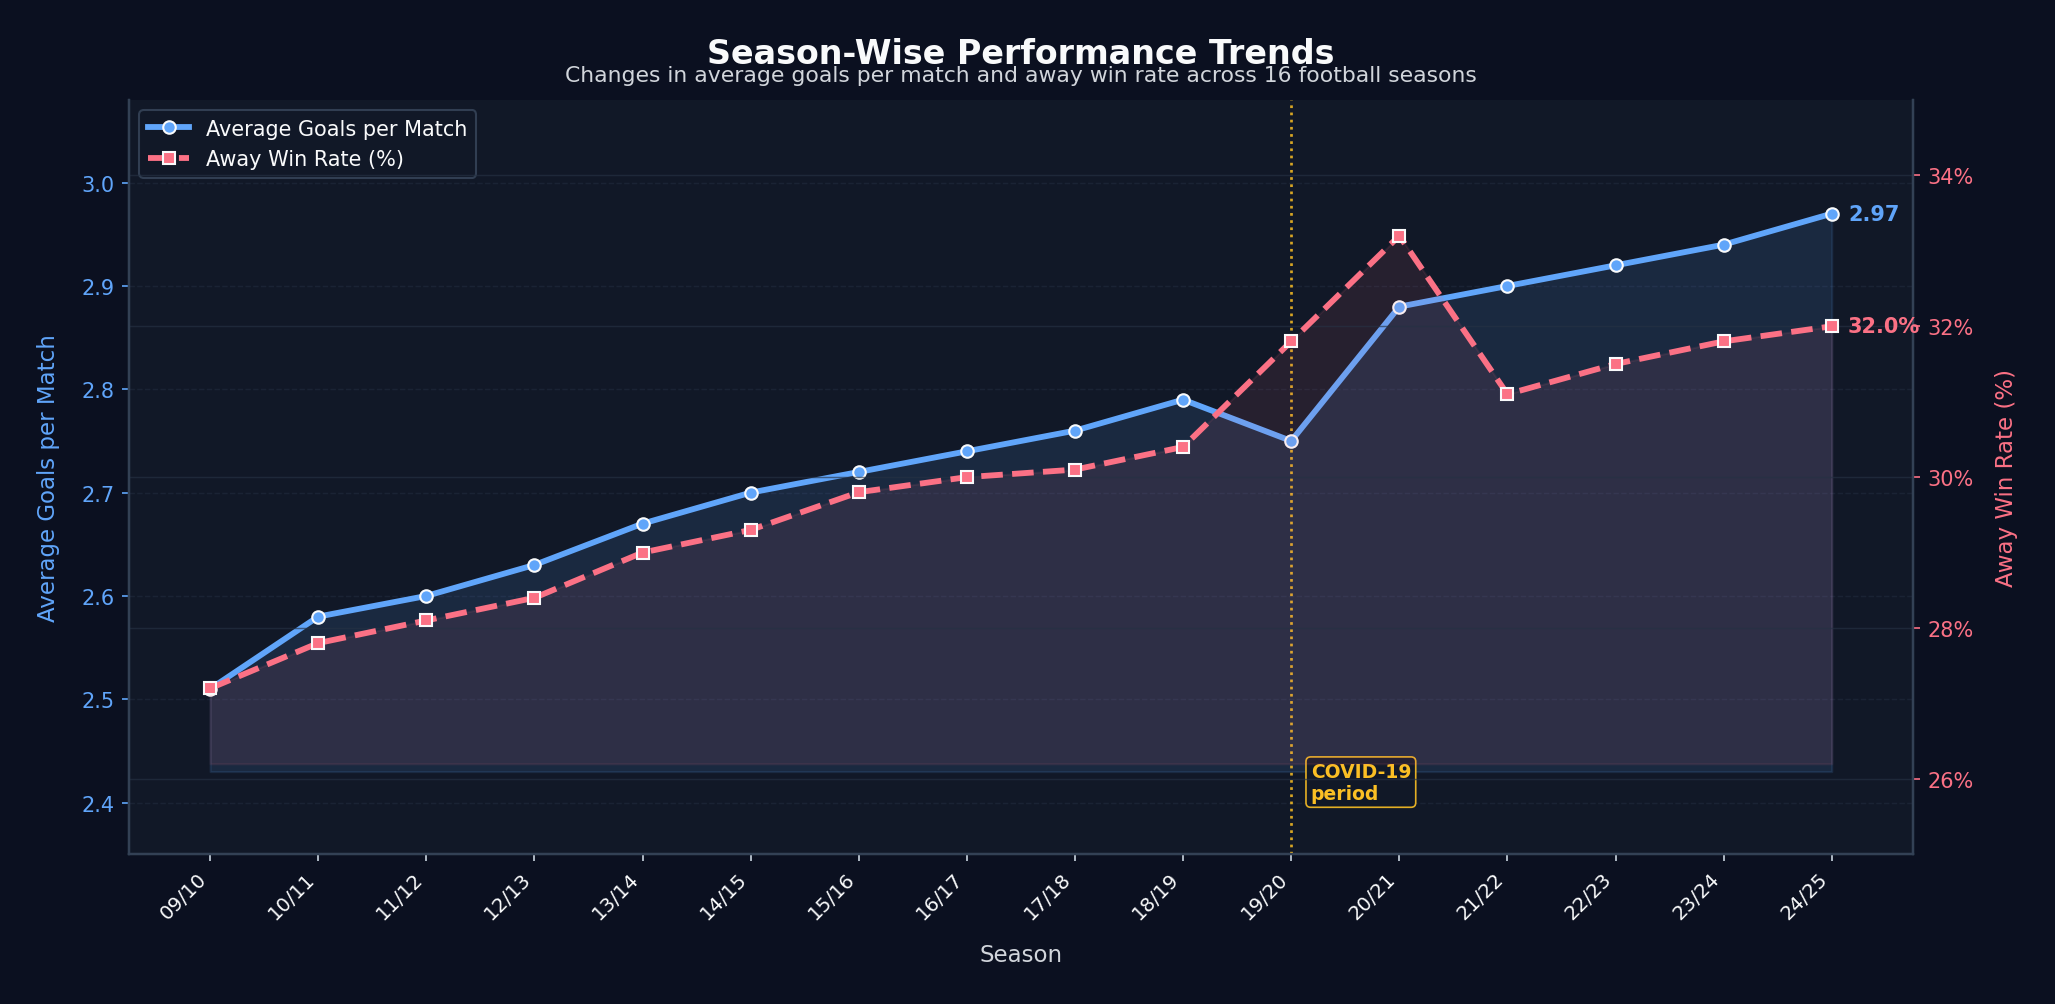

In [14]:
# ============================================================
# FIGURE 10: SEASON-WISE PERFORMANCE TRENDS
# Average Goals per Match and Away Win Rate
# ============================================================

# Data
seasons = [
    "09/10", "10/11", "11/12", "12/13", "13/14", "14/15",
    "15/16", "16/17", "17/18", "18/19", "19/20", "20/21",
    "21/22", "22/23", "23/24", "24/25"
]

avg_goals = [
    2.51, 2.58, 2.60, 2.63, 2.67, 2.70,
    2.72, 2.74, 2.76, 2.79, 2.75, 2.88,
    2.90, 2.92, 2.94, 2.97
]

away_win_rate = [
    27.2, 27.8, 28.1, 28.4, 29.0, 29.3,
    29.8, 30.0, 30.1, 30.4, 31.8, 33.2,
    31.1, 31.5, 31.8, 32.0
]

x = np.arange(len(seasons))

# Figure
fig, ax1 = plt.subplots(figsize=(13.5, 6.5))
fig.patch.set_facecolor(PALETTE["dark"])
ax1.set_facecolor(PALETTE["panel"])

# Secondary axis
ax2 = ax1.twinx()

# Line 1: Average goals per match
line_goals, = ax1.plot(
    x,
    avg_goals,
    color=PALETTE["blue"],
    linewidth=2.8,
    marker="o",
    markersize=6,
    markerfacecolor=PALETTE["blue"],
    markeredgecolor=PALETTE["light"],
    markeredgewidth=1.0,
    label="Average Goals per Match",
    zorder=4
)

ax1.fill_between(
    x,
    avg_goals,
    min(avg_goals) - 0.08,
    color=PALETTE["blue"],
    alpha=0.12,
    zorder=2
)

# Line 2: Away win rate
line_away, = ax2.plot(
    x,
    away_win_rate,
    color=PALETTE["coral"],
    linewidth=2.8,
    marker="s",
    markersize=5.5,
    markerfacecolor=PALETTE["coral"],
    markeredgecolor=PALETTE["light"],
    markeredgewidth=1.0,
    linestyle="--",
    label="Away Win Rate (%)",
    zorder=4
)

ax2.fill_between(
    x,
    away_win_rate,
    min(away_win_rate) - 1,
    color=PALETTE["coral"],
    alpha=0.09,
    zorder=1
)

# Title and subtitle
ax1.set_title(
    "Season-Wise Performance Trends",
    fontsize=16,
    fontweight="bold",
    color=PALETTE["light"],
    pad=18
)

ax1.text(
    0.5, 1.02,
    "Changes in average goals per match and away win rate across 16 football seasons",
    transform=ax1.transAxes,
    ha="center",
    va="bottom",
    fontsize=10.5,
    color=PALETTE["muted"]
)

# X-axis
ax1.set_xticks(x)
ax1.set_xticklabels(seasons, rotation=45, ha="right", fontsize=9.5, color=PALETTE["light"])
ax1.set_xlabel("Season", fontsize=11, color=PALETTE["muted"], labelpad=10)

# Left Y-axis
ax1.set_ylabel(
    "Average Goals per Match",
    color=PALETTE["blue"],
    fontsize=11,
    labelpad=10
)

ax1.tick_params(axis="y", colors=PALETTE["blue"], labelsize=10)
ax1.set_ylim(2.35, 3.08)

# Right Y-axis
ax2.set_ylabel(
    "Away Win Rate (%)",
    color=PALETTE["coral"],
    fontsize=11,
    labelpad=10
)

ax2.tick_params(axis="y", colors=PALETTE["coral"], labelsize=10)
ax2.set_ylim(25, 35)

# Y-axis formatting
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))

# Grid styling
ax1.set_axisbelow(True)
ax1.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.45)
ax1.grid(axis="x", visible=False)

# Combined legend
lines = [line_goals, line_away]
labels = [line.get_label() for line in lines]

legend = ax1.legend(
    lines,
    labels,
    loc="upper left",
    frameon=True,
    facecolor=PALETTE["panel"],
    edgecolor=PALETTE["border"],
    fontsize=10
)

for text in legend.get_texts():
    text.set_color(PALETTE["light"])

# COVID-19 annotation
covid_index = seasons.index("19/20")

ax1.axvline(
    x=covid_index,
    color=PALETTE["amber"],
    linewidth=1.3,
    linestyle=":",
    alpha=0.85,
    zorder=3
)

ax1.text(
    covid_index + 0.18,
    2.40,
    "COVID-19\nperiod",
    color=PALETTE["amber"],
    fontsize=9,
    fontweight="bold",
    va="bottom",
    ha="left",
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor=PALETTE["panel"],
        edgecolor=PALETTE["amber"],
        linewidth=0.8,
        alpha=0.9
    )
)

# End-point labels
ax1.text(
    x[-1] + 0.15,
    avg_goals[-1],
    f"{avg_goals[-1]:.2f}",
    color=PALETTE["blue"],
    fontsize=10,
    fontweight="bold",
    va="center"
)

ax2.text(
    x[-1] + 0.15,
    away_win_rate[-1],
    f"{away_win_rate[-1]:.1f}%",
    color=PALETTE["coral"],
    fontsize=10,
    fontweight="bold",
    va="center"
)

# Spine styling
for spine in ["top"]:
    ax1.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)

ax1.spines["left"].set_color(PALETTE["border"])
ax1.spines["bottom"].set_color(PALETTE["border"])
ax2.spines["right"].set_color(PALETTE["border"])

plt.tight_layout()

# Save figure
save_figure("figure_10_season_wise_performance_trends.png")

plt.show()